# Artificial Intelligence Course 2024 - Computer Assignment 4: Machine Learning - Optimization - SVM - ROC Curve

**Instructor:** Dr. Fadaei and Dr. Yaghoobzaadeh

**Student:** Mohammad Taha Majlesi (810101504)

# Project Overview

This notebook implements a comprehensive machine learning pipeline for predicting Boston housing prices. The project encompasses data exploration, preprocessing, and advanced modeling techniques including linear regression, polynomial regression, gradient descent, decision trees, K-Nearest Neighbors (KNN), and Support Vector Machines (SVM). The objective is to apply various AI/ML techniques to understand housing price determinants and evaluate model performance.

## Table of Contents

1. [Introduction](#Introduction)
2. [Data Acquisition](#Data-Acquisition)
3. [Data Exploration](#Data-Exploration)
4. [Data Preprocessing](#Data-Preprocessing)
5. [Feature Engineering](#Feature-Engineering)
6. [Model Development](#Model-Development)
   - 6.1 [Linear Regression](#Linear-Regression)
   - 6.2 [Polynomial Regression](#Polynomial-Regression)
   - 6.3 [Gradient Descent](#Gradient-Descent)
   - 6.4 [Decision Trees](#Decision-Trees)
   - 6.5 [K-Nearest Neighbors](#K-Nearest-Neighbors)
   - 6.6 [Support Vector Machines](#Support-Vector-Machines)
7. [Model Evaluation](#Model-Evaluation)
8. [Conclusion](#Conclusion)

In [ ]:
# Introduction

This project focuses on applying machine learning techniques to predict housing prices in Boston using the Boston Housing Dataset. The dataset contains various features related to housing characteristics and socioeconomic factors. The analysis covers data exploration, preprocessing, and multiple modeling techniques including linear regression, polynomial regression, gradient descent, decision trees, K-Nearest Neighbors (KNN), and Support Vector Machines (SVM). The objective is to apply various AI/ML techniques to understand housing price determinants and evaluate model performance.

## Data Acquisition

The Boston Housing Dataset is loaded from an Excel file containing 14 features and the target variable MEDV (median value of owner-occupied homes in $1000s).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree

# Data Exploration

This section performs exploratory data analysis (EDA) on the Boston Housing Dataset to understand the data structure, identify patterns, correlations, and potential issues before modeling.

## Dataset Description

The Boston Housing Dataset contains information about housing in Boston, Massachusetts. The target variable is MEDV (Median value of owner-occupied homes in $1000's). The features include:

- CRIM: Per capita crime rate by town
- ZN: Proportion of residential land zoned for lots over 25,000 sq.ft.
- INDUS: Proportion of non-retail business acres per town
- CHAS: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
- NOX: Nitric oxides concentration (parts per 10 million)
- RM: Average number of rooms per dwelling
- AGE: Proportion of owner-occupied units built prior to 1940
- DIS: Weighted distances to five Boston employment centers
- RAD: Index of accessibility to radial highways
- TAX: Full-value property-tax rate per $10,000
- PTRATIO: Pupil-teacher ratio by town
- B: 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
- LSTAT: % lower status of the population
- MEDV: Median value of owner-occupied homes in $1000's (target)

## Data Loading and Initial Inspection

This code cell loads the Boston Housing Dataset from an Excel file and displays the first few rows to verify the data structure and content. This step ensures the data is correctly loaded and provides an initial view of the features and target variable.

## Dataset Information and Summary Statistics

This code cell provides an overview of the dataset structure, including the number of entries, data types for each column, and memory usage. It helps identify the data types and check for any immediate issues like missing values.

## Dataset Shape

This code cell outputs the dimensions of the dataset (number of rows and columns), providing insight into the dataset size.

In [ ]:
data = pd.read_excel('DataSet.xlsx')
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222.0,18.7,NaN,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [5]:

data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     480 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      479 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        486 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     452 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 55.5 KB


## Dataset Shape

This code cell outputs the dimensions of the dataset (number of rows and columns), providing insight into the dataset size.

In [6]:
data.shape

(506, 14)

## Summary Statistics

This code cell generates descriptive statistics for numerical columns, including count, mean, standard deviation, minimum, quartiles, and maximum values. This helps understand the distribution and central tendencies of the features.

In [7]:
data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,480.000000,506.000000,506.000000,506.000000,479.000000,506.000000,506.000000,506.000000,486.000000,506.000000,452.000000
mean,1.269195,13.295257,9.205158,0.175000,1.101175,15.679800,58.744660,6.211663,78.063241,339.317787,42.614980,336.820947,11.537806,23.750442
std,2.399207,23.048697,7.169630,0.380364,1.646991,27.220206,33.104049,6.527286,203.542157,180.670077,87.585243,121.174519,6.064932,8.808602
min,0.000000,0.000000,0.000000,0.000000,0.385000,3.561000,1.137000,1.129600,1.000000,20.200000,2.600000,0.320000,1.730000,6.300000
25%,0.049443,0.000000,3.440000,0.000000,0.449000,5.961500,32.000000,2.425900,4.000000,254.000000,17.000000,370.415000,6.877500,18.500000
50%,0.144655,0.000000,6.960000,0.000000,0.538000,6.322500,65.250000,3.917500,5.000000,307.000000,18.900000,390.885000,10.380000,21.950000
75%,0.819623,18.100000,18.100000,0.000000,0.647000,6.949000,89.975000,6.341400,24.000000,403.000000,20.200000,395.630000,15.015000,26.600000
max,9.966540,100.000000,27.740000,1.000000,7.313000,100.000000,100.000000,24.000000,666.000000,711.000000,396.900000,396.900000,34.410000,50.000000


## Missing Values Analysis

This code cell calculates the number and percentage of missing values for each feature. Identifying missing data is crucial for deciding on imputation or removal strategies in preprocessing.

In [8]:

missing_data = data.isnull().sum()

missing_percentage = (missing_data / len(data)) * 100

missing_df = pd.DataFrame({'Number of Missing Values': missing_data, 'Percentage': missing_percentage})

print(missing_df)



         Number of Missing Values  Percentage
CRIM                            0    0.000000
ZN                              0    0.000000
INDUS                           0    0.000000
CHAS                           26    5.138340
NOX                             0    0.000000
RM                              0    0.000000
AGE                             0    0.000000
DIS                            27    5.335968
RAD                             0    0.000000
TAX                             0    0.000000
PTRATIO                         0    0.000000
B                              20    3.952569
LSTAT                           0    0.000000
MEDV                           54   10.671937


## Missing Values Visualization

This code cell creates a bar plot to visualize the number of missing values per feature. The plot helps identify which features have missing data and the extent of the problem.

## Unique Values Analysis

This code cell plots the number of unique values for each feature to understand the diversity within the dataset, helping identify categorical vs. continuous variables.

## Show the number of missing values in the data 

/var/folders/cg/l2rdx46d6lv3b5xc17b420yc0000gn/T/ipykernel_2881/3164335452.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data.values, y=missing_data.index, palette='viridis')


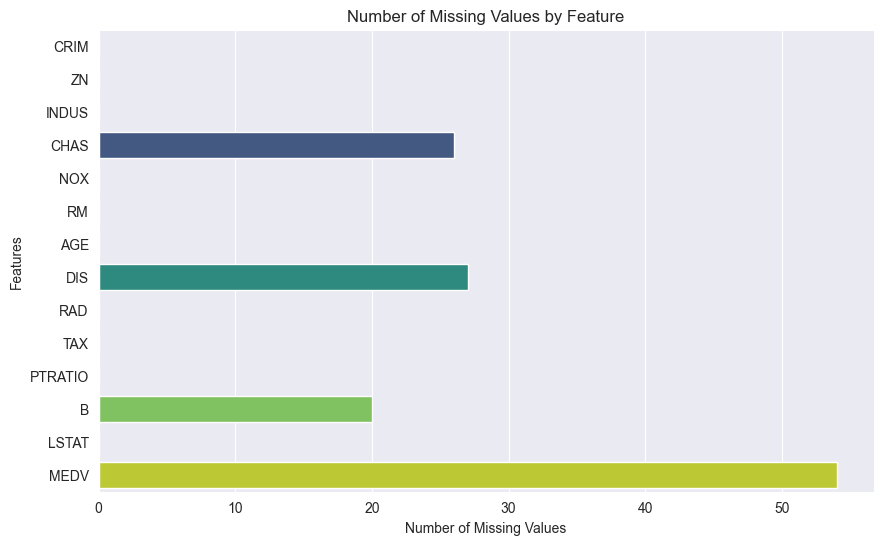

In [ ]:
missing_data = data.isnull().sum()
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_data.values, y=missing_data.index, palette='viridis')
plt.title('Number of Missing Values by Feature')
plt.xlabel('Number of Missing Values')
plt.ylabel('Features')
plt.show()

Question 3 :

## Explanation of the Plot

Plot Description: This bar plot displays the number of missing values for each feature in your dataset. Features are listed on the y-axis, and the number of missing values they contain is shown on the x-axis.

/var/folders/cg/l2rdx46d6lv3b5xc17b420yc0000gn/T/ipykernel_2881/1884439525.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_values.values, y=unique_values.index, palette='viridis')


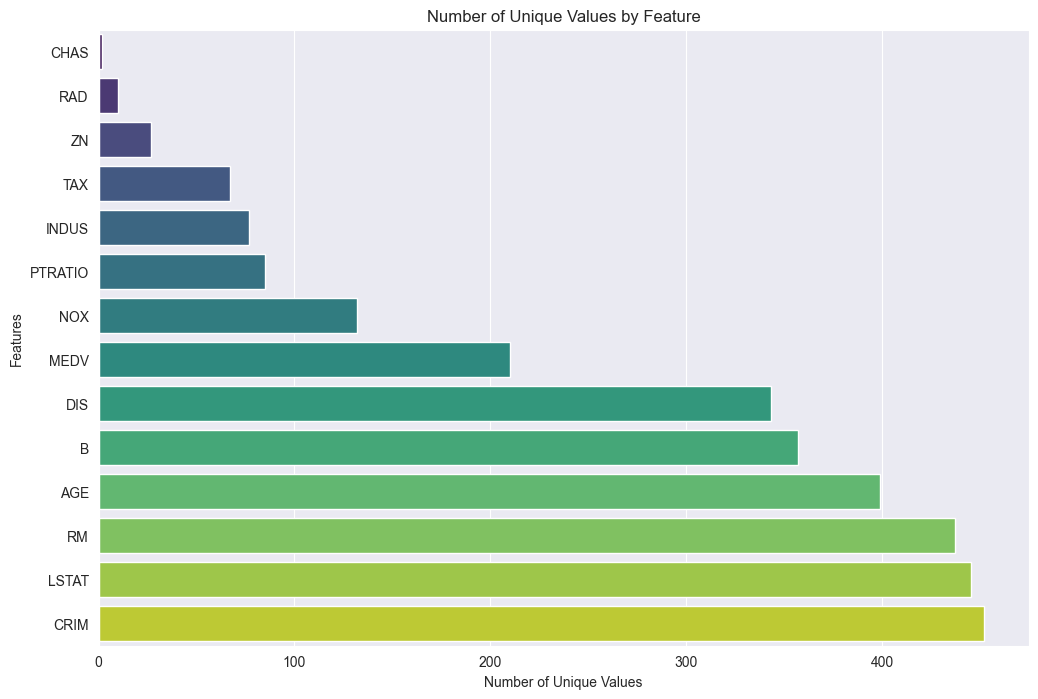

In [ ]:
unique_values = data.nunique()
unique_values = unique_values.sort_values(ascending=True)
plt.figure(figsize=(12, 8))
sns.barplot(x=unique_values.values, y=unique_values.index, palette='viridis')
plt.title('Number of Unique Values by Feature')
plt.xlabel('Number of Unique Values')
plt.ylabel('Features')
plt.show()

## Explanation of the Plot
Plot Description: This bar plot displays the number of unique values for each feature in your dataset. Features are listed on the y-axis, and the number of unique values they contain is shown on the x-axis.
Interpreting Results:
Categorical Features: Features with a relatively low number of unique values (often below 10-20) can be considered categorical. These features represent groups or categories.
Numerical Features: Features with a higher count of unique values are likely to be numerical. These can represent measurements or counts that can vary widely across the dataset.
Identification of Key Features: Features with a high diversity (many unique values) might be critical for predictive modeling, especially if they correlate well with the target variable. Conversely, features with very few unique values might have less predictive power or could even be identifiers that are irrelevant for modeling.

we can see that CRIM has the highest number of unique values and CHAS has the lowest number of unique values.
because CHAS has only 2 unique values we can consider it as a binary value and we can drop it.

## Feature Correlation Analysis

This code cell computes and visualizes the correlation matrix of all features using a heatmap. Correlation analysis helps identify relationships between variables, particularly which features are most correlated with the target variable MEDV.

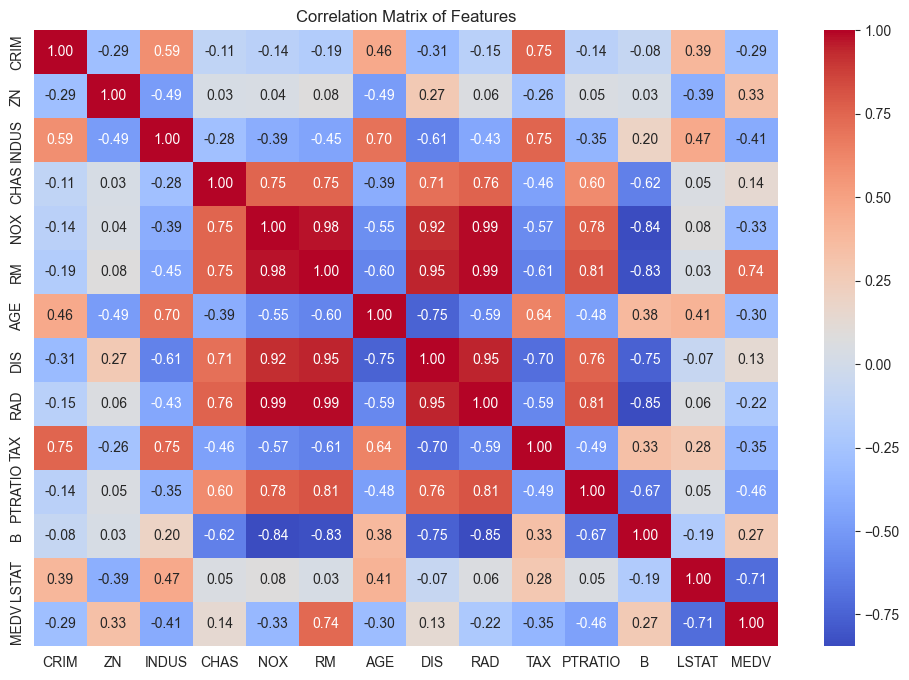

In [ ]:
corr_matrix = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of Features')
plt.show()

we can see that terms RM and LSTAT have the highest correlation with the target variable MEDV
and after that LSTAT and MEDV have the highest correlation with each other.


### Explanation of the Correlation Heatmap

- **Plot Description**: The heatmap displays the correlation coefficients between each pair of features, including the target variable. Each cell in the heatmap shows the correlation coefficient, ranging from -1 to 1. A coefficient close to 1 implies a strong positive correlation, meaning that as one feature increases, the other feature also tends to increase. A coefficient close to -1 implies a strong negative correlation, meaning that as one feature increases, the other decreases. A coefficient around 0 implies no correlation.

- **Interpreting Results**:
  - **High Positive Correlation**: Look for cells that are colored closer to the warm end of the spectrum (red) with values close to 1. These indicate features that increase together.
  - **High Negative Correlation**: Cells colored closer to the cool end of the spectrum (blue) with values close to -1 indicate features that move in opposite directions.
  - **Target Variable Correlations**: Focus particularly on the row or column corresponding to the target variable (often "MEDV" in the Boston housing dataset). This will show you which features have the strongest relationships with the target. For example:
    - Features with high positive correlations with "MEDV" might include variables like "RM" (average number of rooms per dwelling) which often indicates that larger homes have higher prices.
    - Features with negative correlations might include "LSTAT" (% lower status of the population) suggesting that areas with higher poverty levels have lower home prices.

Using this analysis, you can decide which features might be most predictive of the target variable and therefore important to include in your machine learning model. It also helps in understanding potential multicollinearity between features, which can be important when deciding to drop or transform certain variables before modeling.

## Feature vs. Target Analysis

This section creates scatter plots and hexbin plots to visualize relationships between individual features and the target variable MEDV. These visualizations help identify linear or non-linear relationships and potential outliers.

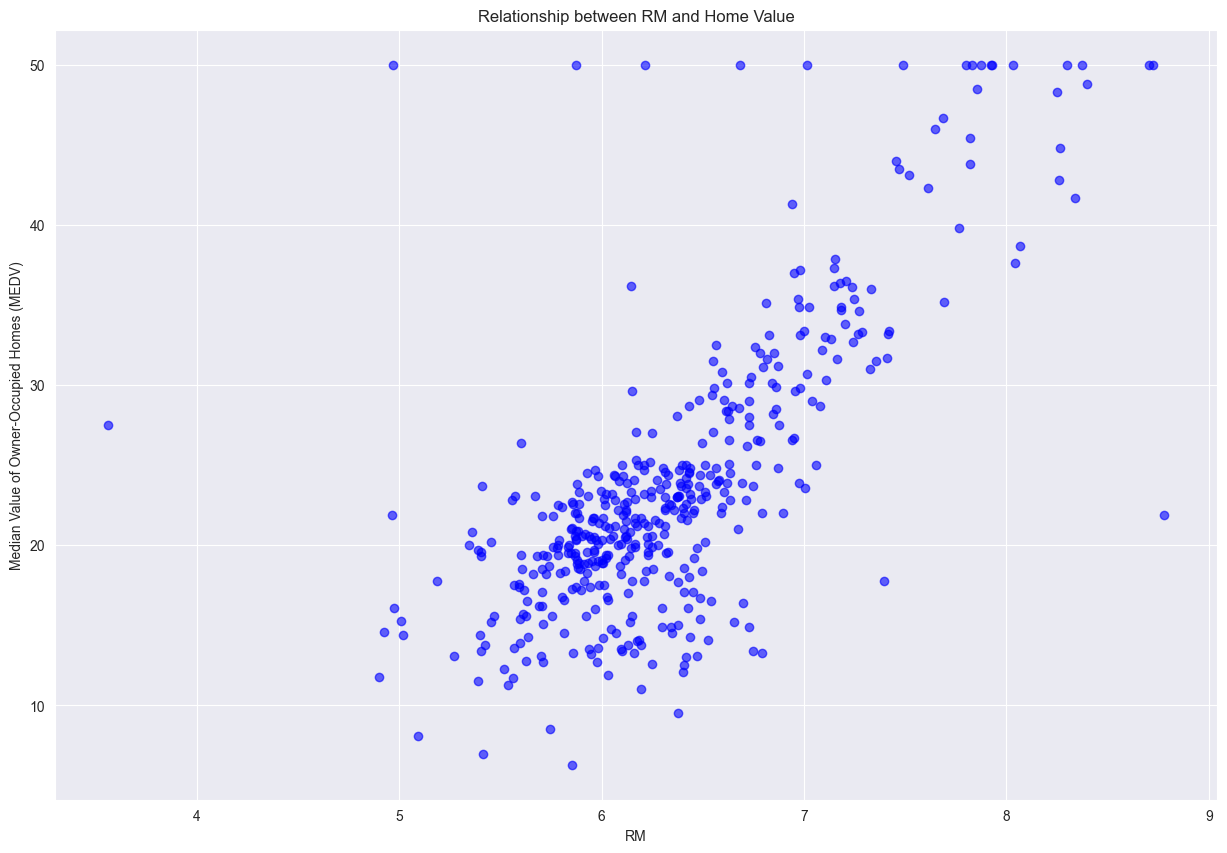

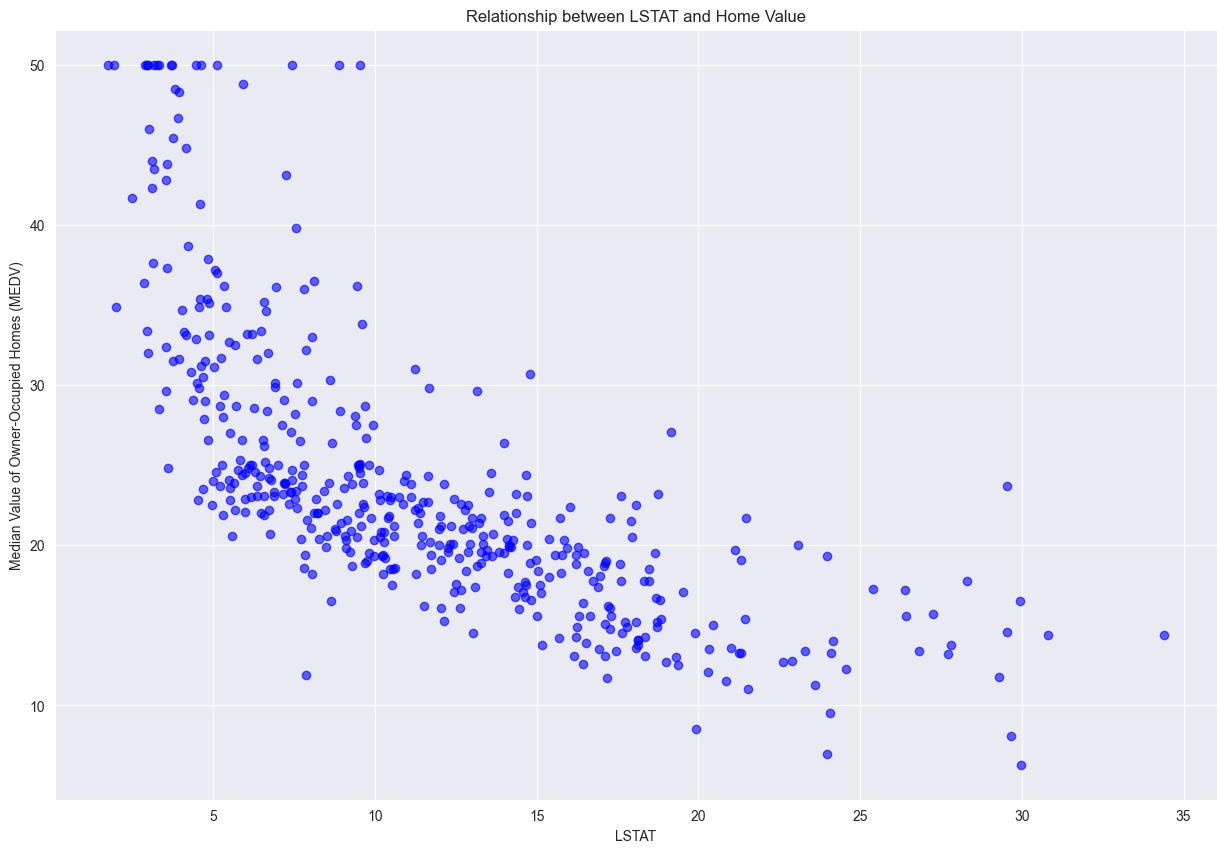

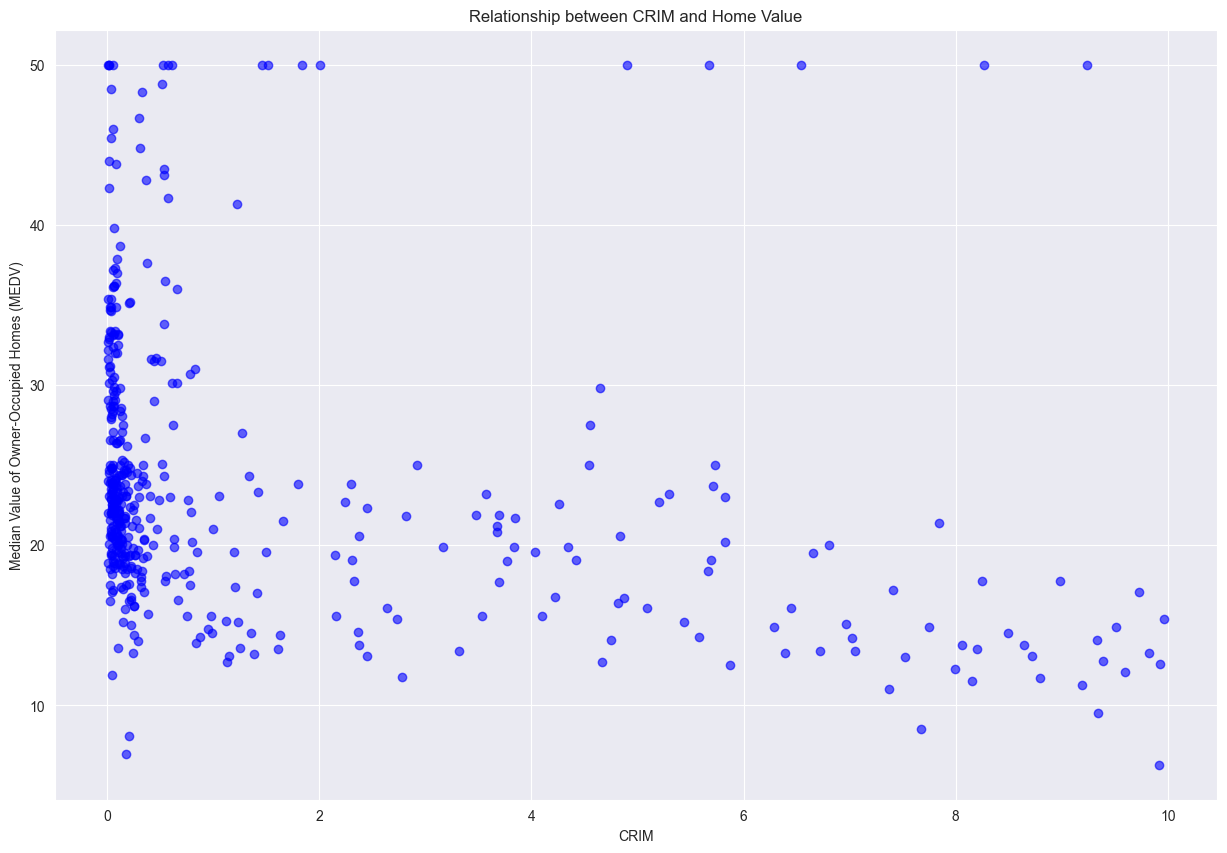

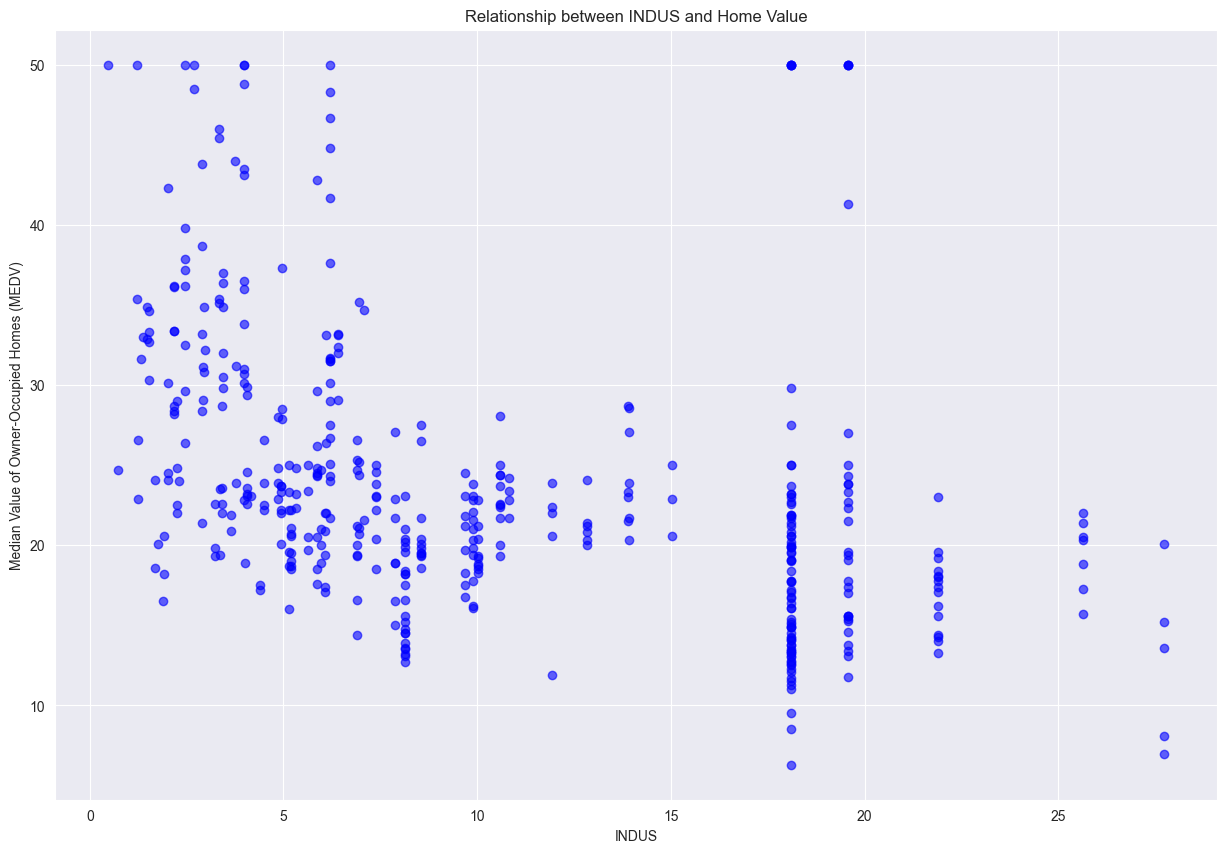

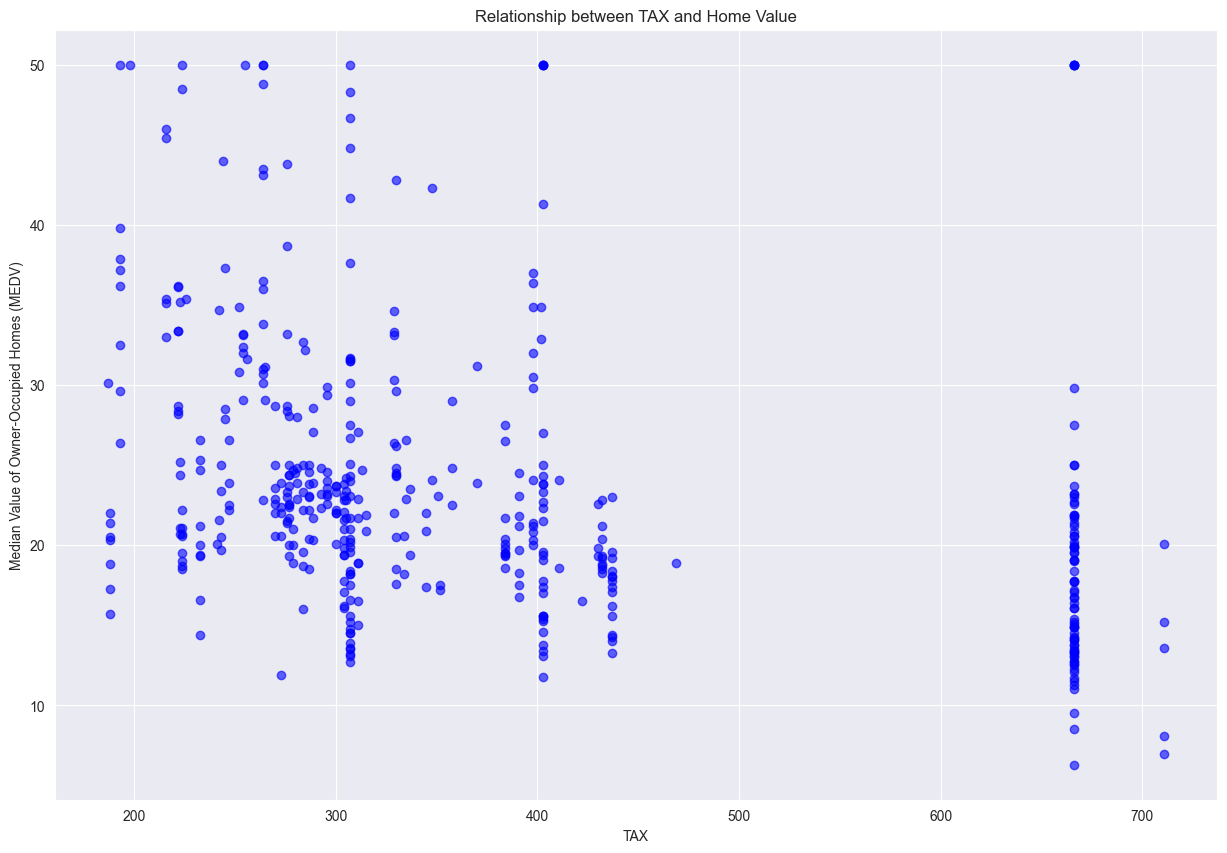

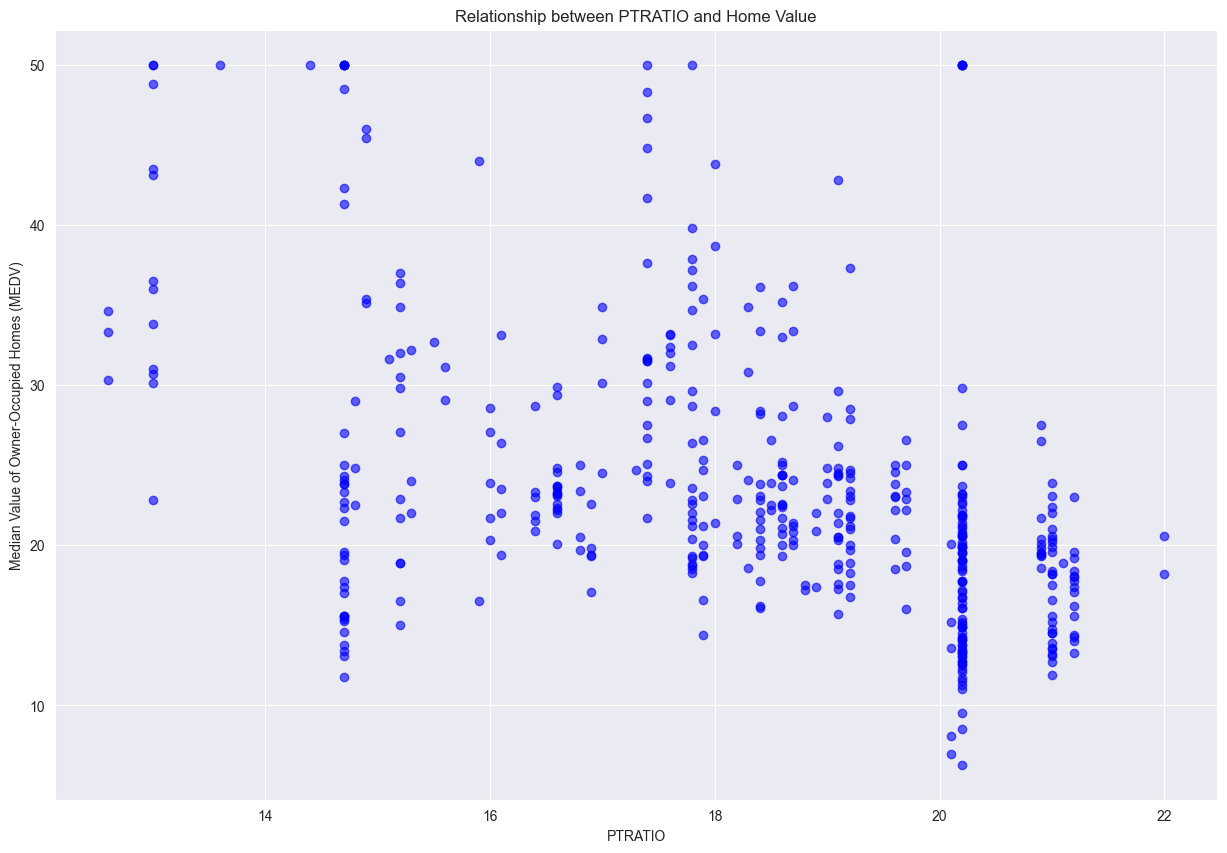

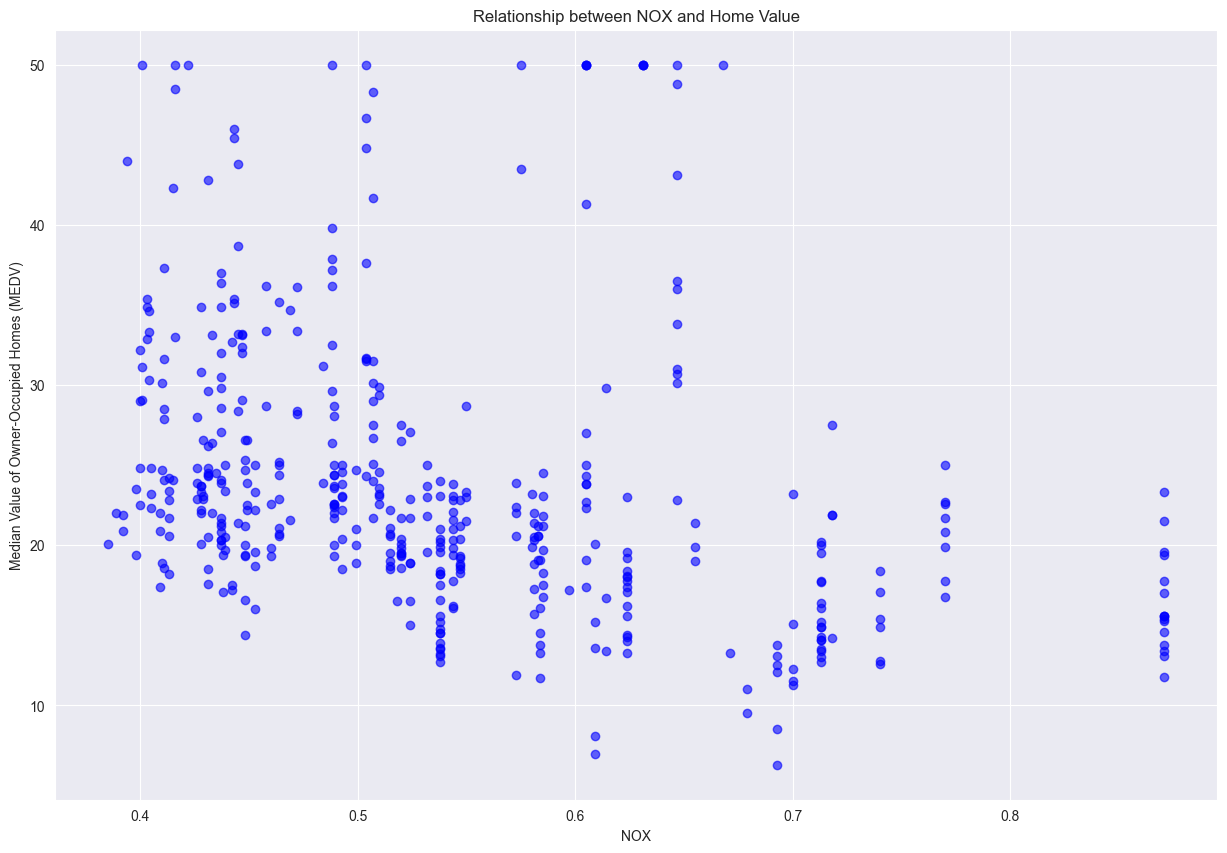

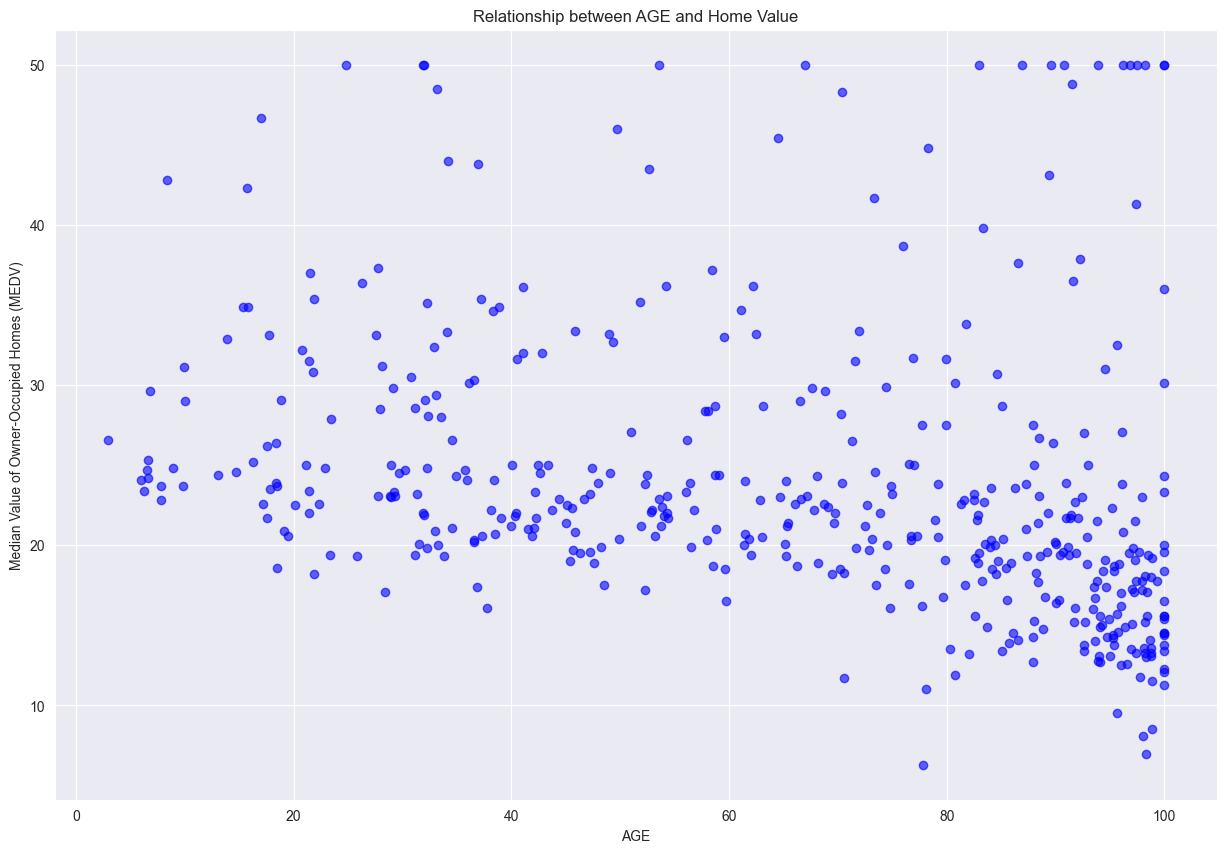

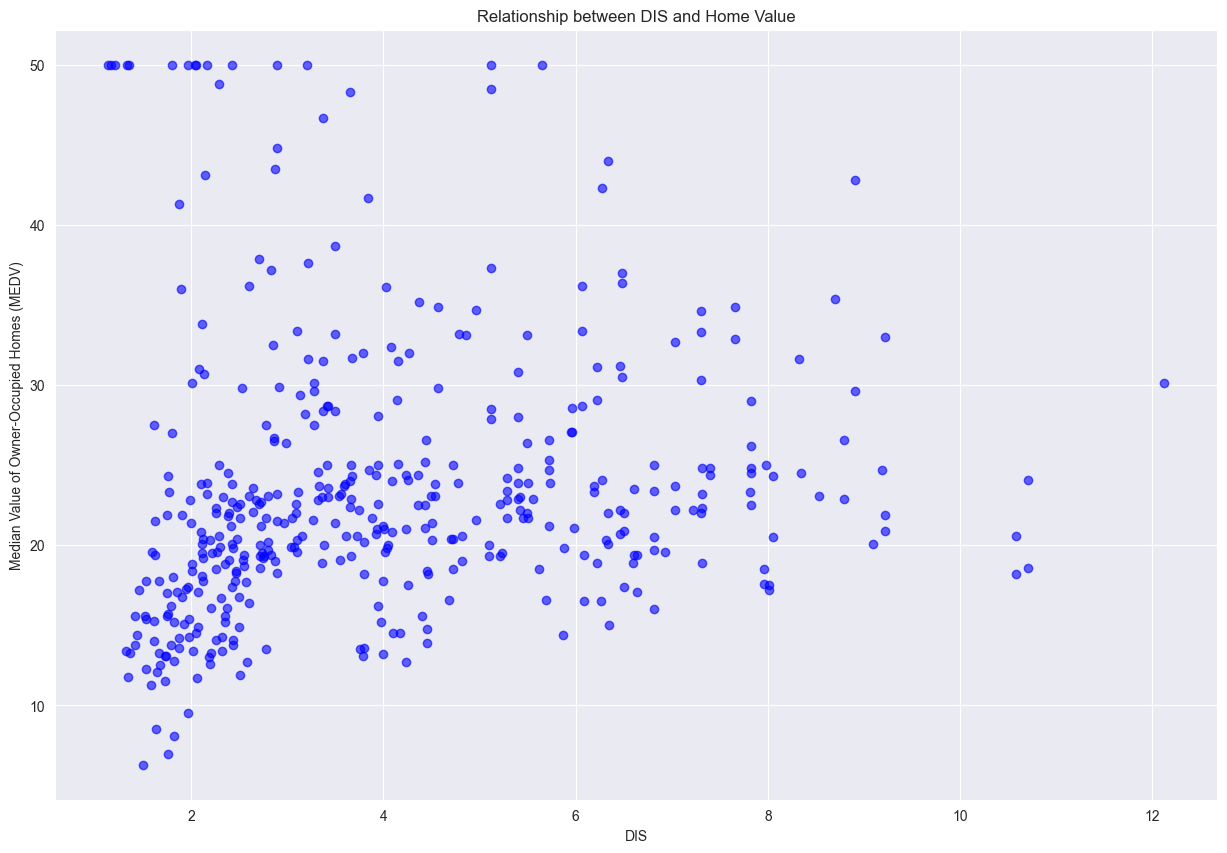

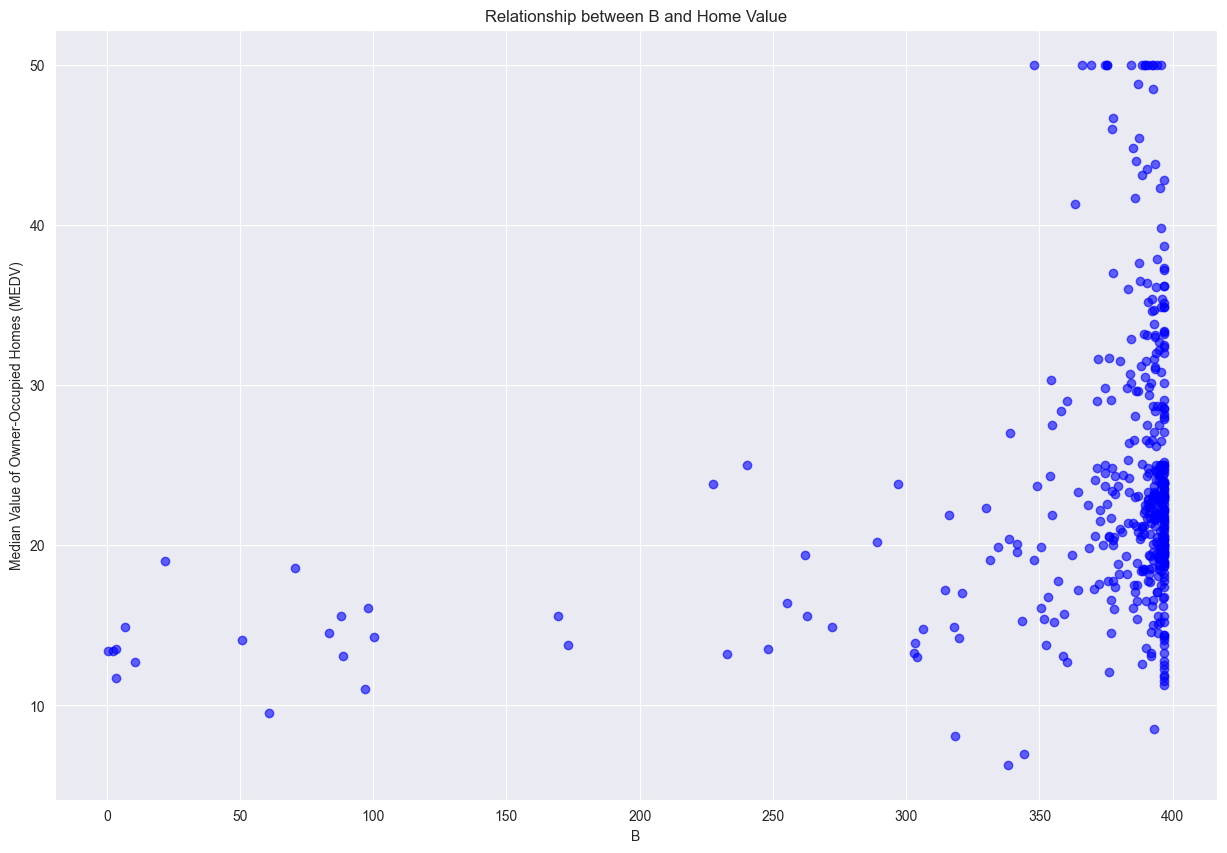

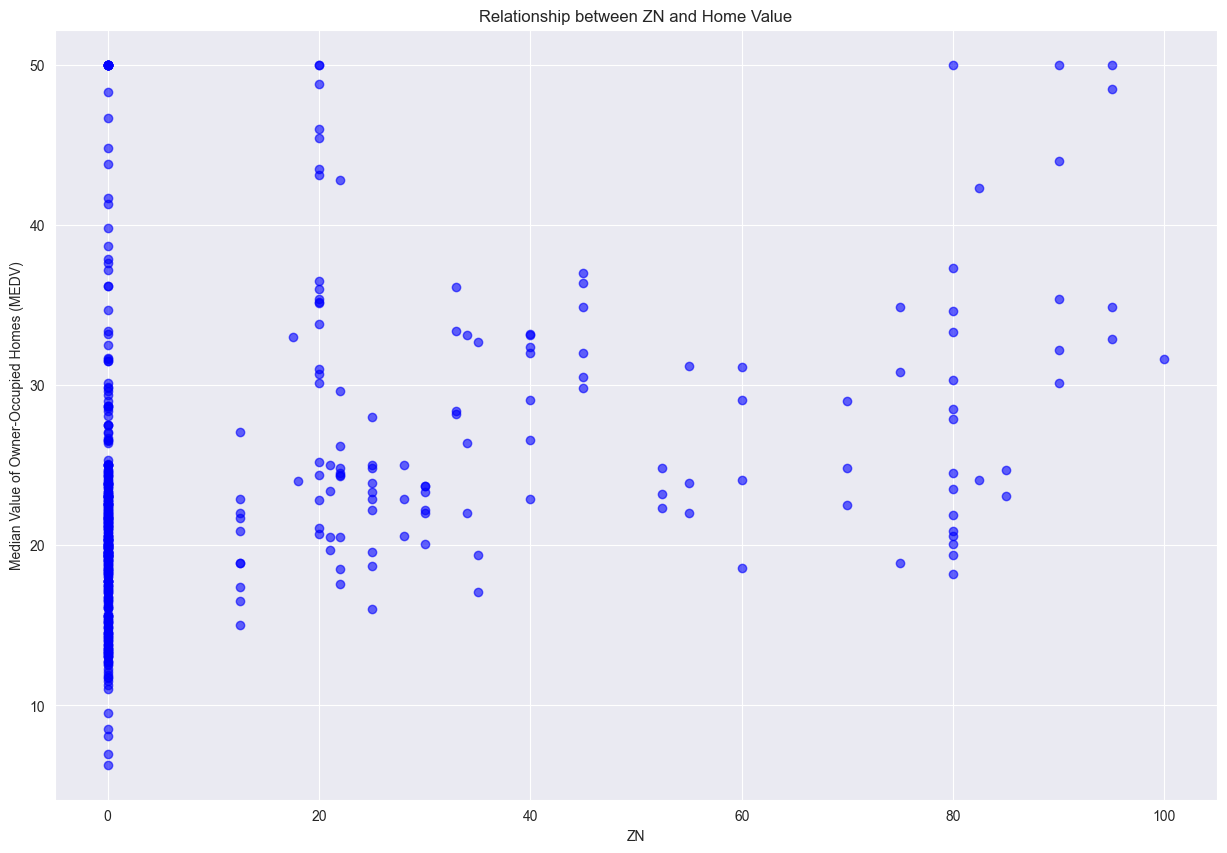

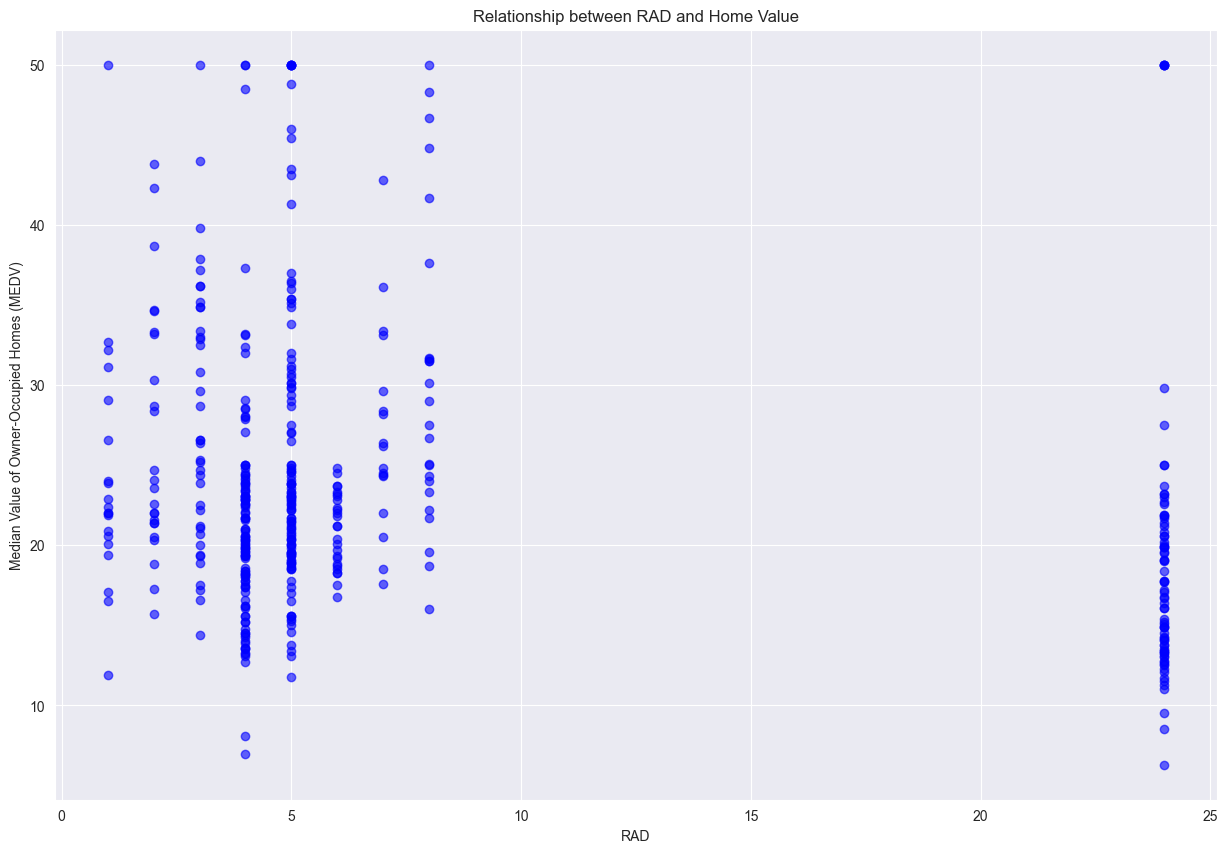

In [ ]:
for feature in ['RM', 'LSTAT', 'CRIM', 'INDUS', 'TAX', 'PTRATIO', 'NOX', 'AGE', 'DIS', 'B', 'ZN', 'RAD']:
    plt.figure(figsize=(15, 10))
    plt.scatter(data[feature], data['MEDV'], color='blue', alpha=0.6)
    plt.title(f'Relationship between {feature} and Home Value')
    plt.xlabel(feature)
    plt.ylabel('Median Value of Owner-Occupied Homes (MEDV)')
    plt.show()


### Hexbin Plots

**Description:**
Hexbin plots are a type of histogram that partitions the data into hexagons for data density estimation. This plot is useful for bivariate data, combining the benefits of a scatter plot and a two-dimensional histogram.

**Usage:**
Hexbin plots are particularly effective when dealing with many data points that would lead to overplotting in scatter plots. They provide a good way of visualizing the density of data points and are useful in identifying concentrations in data.

**Python Code Example:**
To analyze the same relationship as above but using a hexbin plot, which is useful when your data includes many overlapping points:





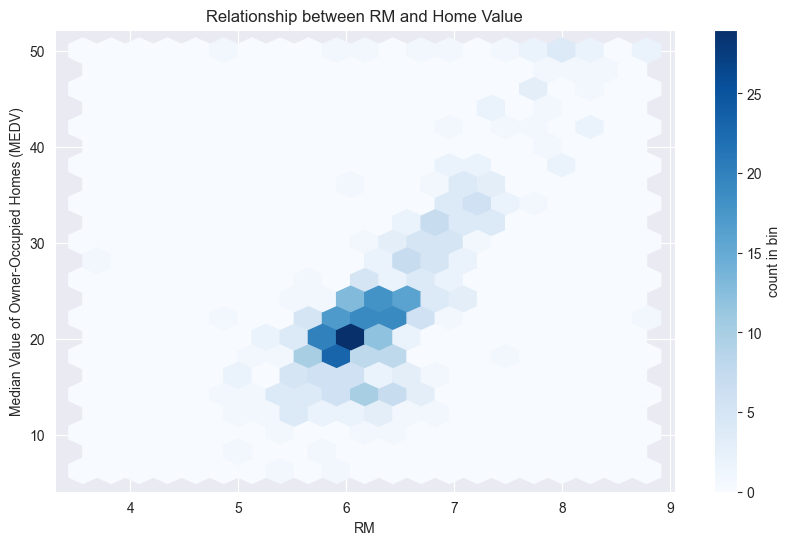

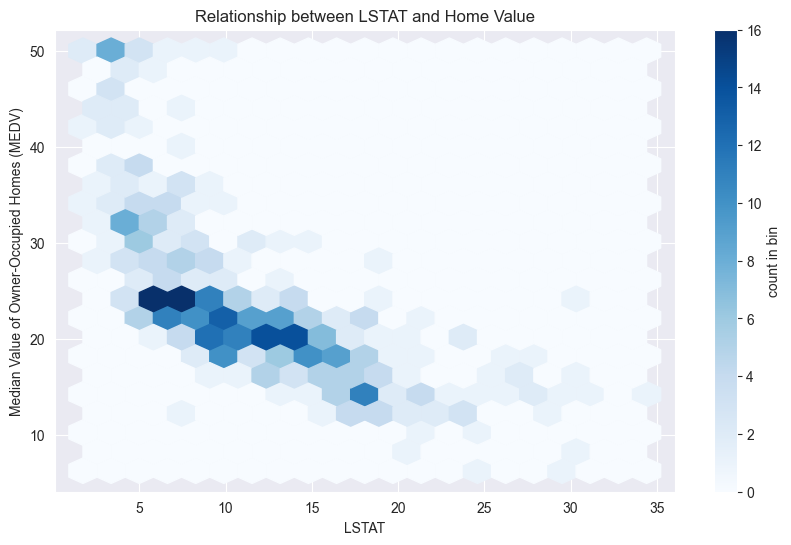

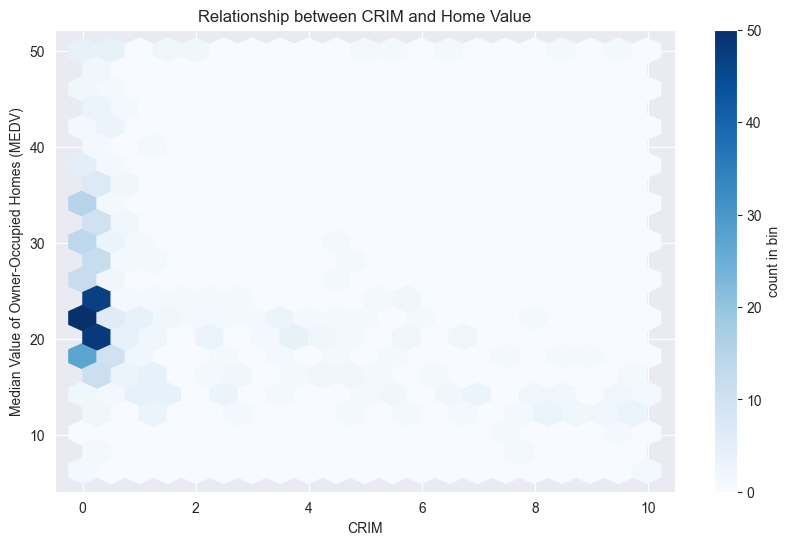

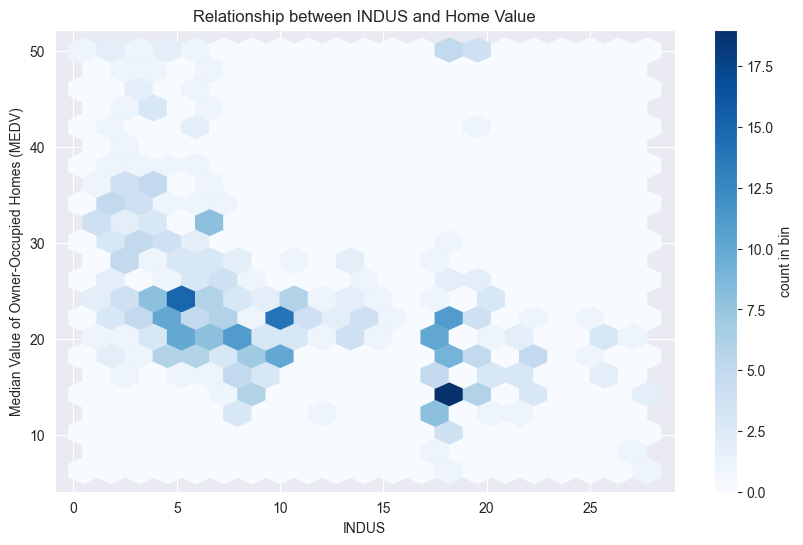

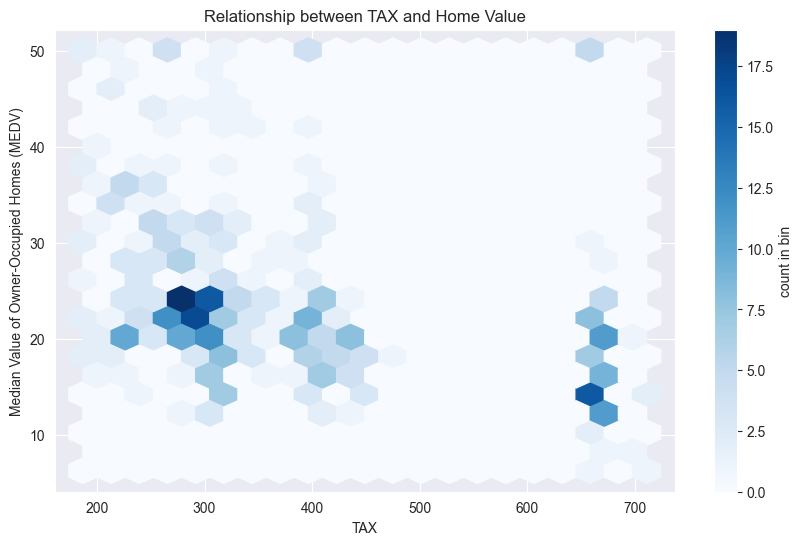

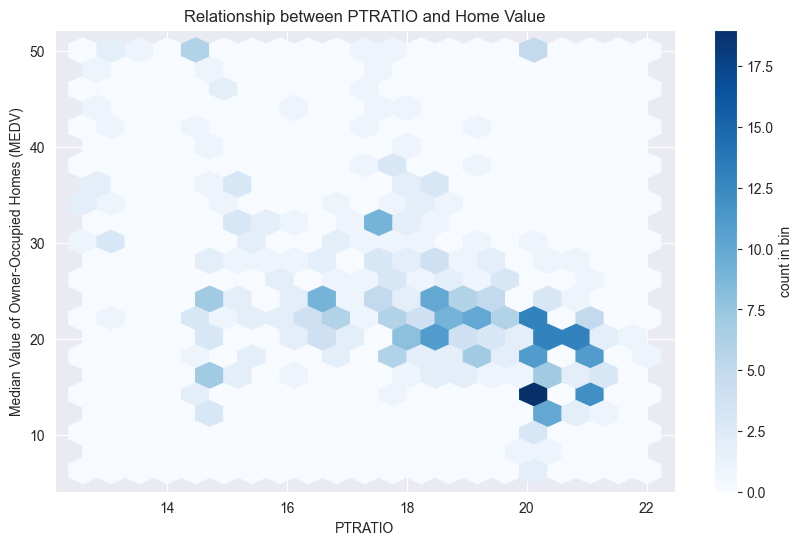

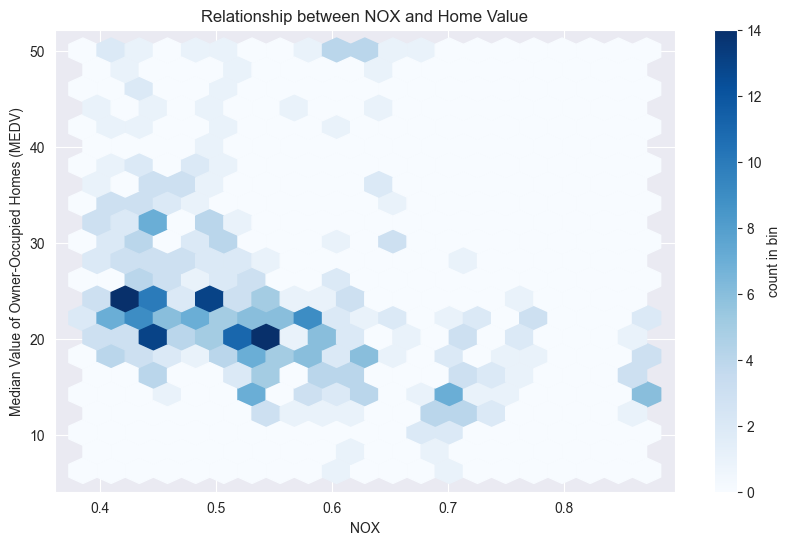

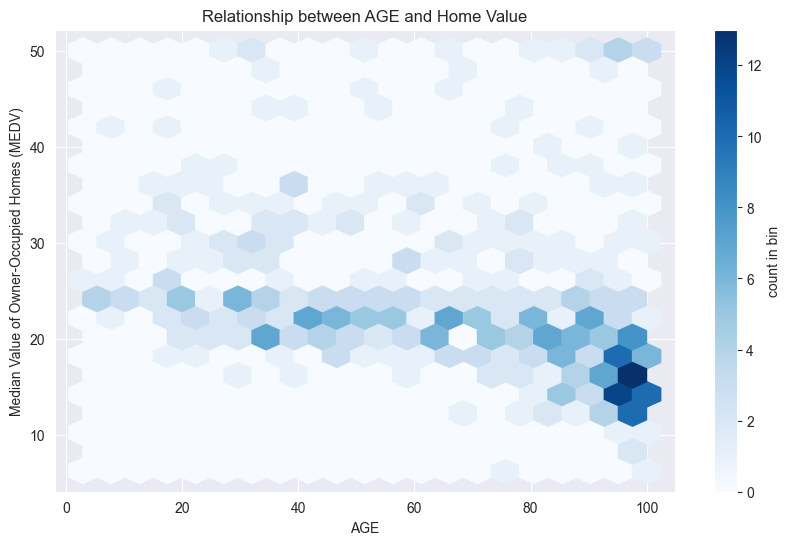

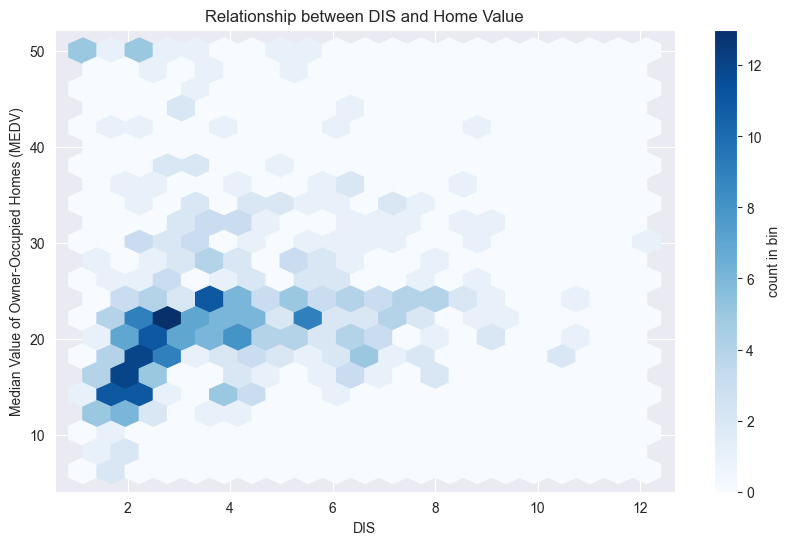

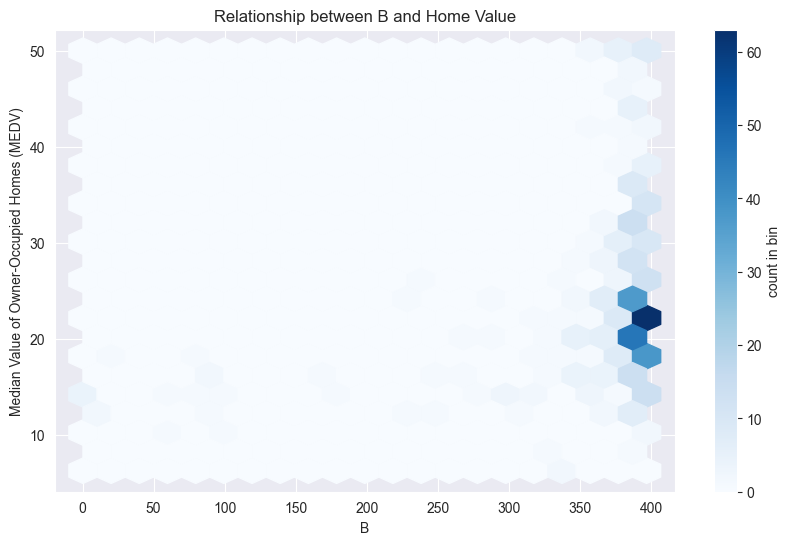

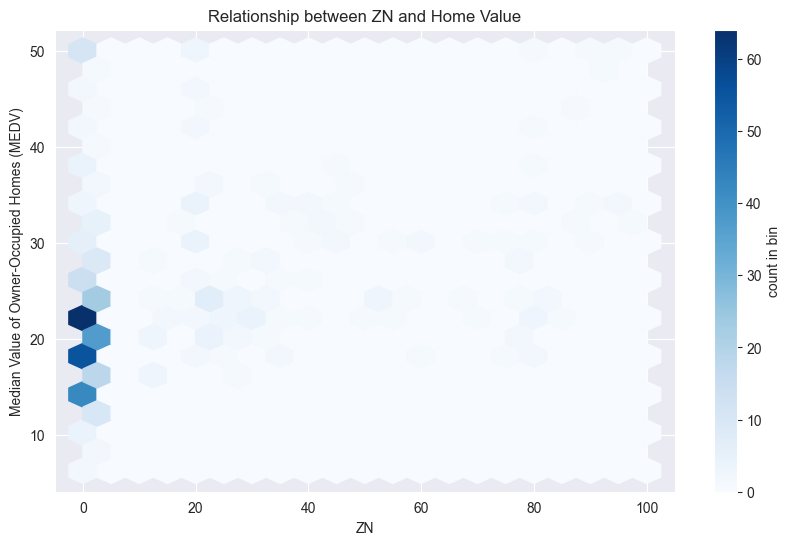

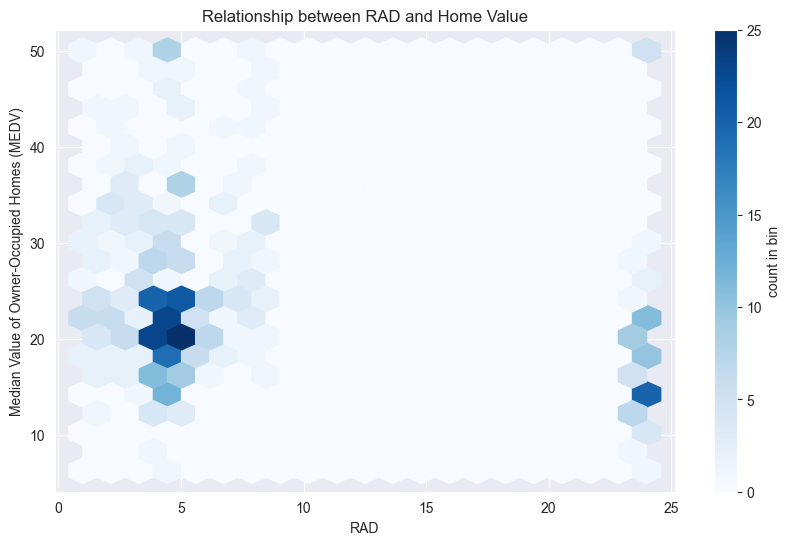

In [13]:
for feature in ['RM', 'LSTAT', 'CRIM', 'INDUS', 'TAX', 'PTRATIO', 'NOX', 'AGE', 'DIS', 'B', 'ZN', 'RAD']:
    plt.figure(figsize=(10, 6))
    plt.hexbin(data[feature], data['MEDV'], gridsize=20, cmap='Blues')
    plt.colorbar(label='count in bin')
    plt.title(f'Relationship between {feature} and Home Value')
    plt.xlabel(feature)
    plt.ylabel('Median Value of Owner-Occupied Homes (MEDV)')
    plt.show()


**Analyzing Dependencies:**
Both scatter and hexbin plots can be used to investigate how features relate to the target variable. In the examples provided:
- The scatter plot may show a clear trend or outlier points between `RM` and `MEDV`.
- The hexbin plot highlights the density of these relationships, showing where data points are concentrated.

By utilizing these plots, you can derive insights into which variables have a stronger or more predictable relationship with the target variable, guiding feature selection and preprocessing steps in machine learning projects.

For a comprehensive understanding of a dataset, there are several advanced analyses you might consider beyond the basic exploratory data analysis (EDA). Each analysis technique can provide deeper insights into the data, helping to uncover patterns, anomalies, or relationships that are not immediately apparent. Below are a few such analyses, and I'll provide an example implementation for one of them using Python.

Question 6 - Advanced Analysis Techniques


### Advanced Analysis Techniques:

1. **Principal Component Analysis (PCA):**
   - **Purpose**: To reduce the dimensionality of the data set while preserving as much variance as possible. Useful for simplifying the data and improving visualizations or the efficiency of machine learning algorithms.
   
2. **Cluster Analysis:**
   - **Purpose**: To group a set of objects in such a way that objects in the same group (called a cluster) are more similar to each other than to those in other groups. It’s often used in exploratory data analysis to identify intrinsic groupings within data.
   
3. **Time Series Analysis (if temporal data is available):**
   - **Purpose**: To analyze time-series data to extract meaningful statistics and other characteristics. It’s useful for forecasting and understanding temporal patterns.
   
4. **Association Rule Mining:**
   - **Purpose**: To find interesting relationships (associations) between variables in large databases. A common tool for market basket analysis.

5. **Anomaly Detection:**
   - **Purpose**: To identify rare items, events, or observations which raise suspicions by differing significantly from the majority of the data. This is particularly useful in fraud detection, network security, etc.




## Principal Component Analysis (PCA)

PCA is a dimensionality reduction technique that transforms the data into a new coordinate system where the greatest variances lie on the first coordinates. This code cell applies PCA to reduce the features to 2 dimensions for visualization, helping to understand the data structure and relationships.

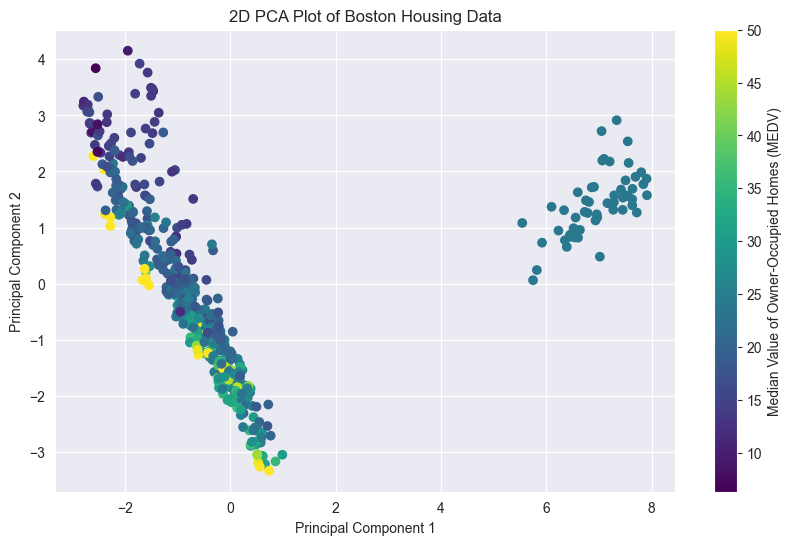

In [ ]:
numerical_features = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
target_feature = 'MEDV'
data.fillna(data.mean(), inplace=True)
for feature in numerical_features:
    data[feature] = StandardScaler().fit_transform(data[[feature]])
X = data[numerical_features]
y = data[target_feature]
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
final_df = pd.concat([principal_df, y], axis=1)
plt.figure(figsize=(10, 6))
plt.scatter(final_df['PC1'], final_df['PC2'], c=final_df['MEDV'], cmap='viridis')
plt.title('2D PCA Plot of Boston Housing Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Median Value of Owner-Occupied Homes (MEDV)')
plt.show()



### Section 2: Data Preprocessing for the Boston Housing Dataset

**Objective:**
The main objective of this phase is to transform raw data into a clean and organized format suitable for training machine learning models. This includes handling missing values, removing unnecessary columns, encoding categorical variables, and normalizing or standardizing numerical features. 

**Key Tasks and Implementations:**

1. **Handling Missing Values:**
   - **Objective:** To deal with incomplete data which can affect model accuracy.
   - **Methods:**
     - **Deletion:** Remove rows with missing values if the dataset is large enough and missing data is minimal.
     - **Imputation:** Replace missing values with mean, median, or mode, which is useful for continuous numerical data.
     - **Prediction:** Use a machine learning model to predict and fill missing values, ideal for critical features with a significant amount of missing data.
   - **Implementation:** Python code for each method using `pandas` and `sklearn`.

2. **Feature Selection:**
   - **Objective:** To eliminate redundant or irrelevant features to improve model performance.
   - **Method:** Remove features with low correlation to the target variable, or those with a high percentage of missing values.
   - **Justification:** Simplifies the model, reduces overfitting, and improves training time.

3. **Categorizing Features:**
   - **Objective:** To differentiate between numerical and categorical features as they require different types of processing.
   - **Method:** Identify and list features as numerical or categorical based on the dataset's dictionary or exploratory analysis.
   - **Explanation:** Numerical features are inherently quantitative and often require scaling. Categorical features are qualitative and typically require encoding before modeling.

4. **Normalization and Standardization:**
   - **Objective:** To scale numerical features so that they contribute equally to model performance.
   - **Difference:**
     - **Normalization:** Scales data to a fixed range, usually 0 to 1.
     - **Standardization:** Scales data to have a mean of 0 and a standard deviation of 1.
   - **Implementation:** Decide based on the distribution of data; use `MinMaxScaler` for normalization and `StandardScaler` for standardization.

5. **Encoding Categorical Features:**
   - **Objective:** To convert categorical data into numerical formats that can be processed by machine learning algorithms.
   - **Methods:** One-hot encoding for nominal categories and ordinal encoding for ordinal categories.
   - **Implementation:** Use `pandas.get_dummies` for one-hot encoding and `OrdinalEncoder` from `sklearn` for ordinal encoding.

6. **Splitting the Dataset:**
   - **Objective:** To divide the data into training, validation, and test sets to ensure model validity and prevent overfitting.
   - **Common Methods:** Use a simple train-test split or K-fold cross-validation for more robustness.
   - **Implementation:** Use `train_test_split` from `sklearn.model_selection` and configure the splits according to the size and nature of the dataset.

7. **Additional Preprocessing Techniques:**
   - **Objective:** To apply advanced preprocessing techniques as needed based on specific data characteristics.
   - **Examples:** Feature engineering to create new informative features, dealing with skewness in data distribution, or applying transformations like logarithmic or exponential transformations to stabilize variance.


Question 7 - Handling Missing Values

### Handling Missing Values 
af first we use deletion method to remove the rows with missing values. then we will use imputation method to replace the missing values with mean of the column.

# method 1 - Removing Rows with Missing Values

this is the data before and after removing the missing values.
in this iart we use dropna method to remove the missing values.
we can see that we lost some data after removing the missing values.
and this is bad for our model because we lost some data.

Data Shape:  (506, 14)
Missing Values: 
CRIM        0
ZN          0
INDUS       0
CHAS       26
NOX         0
RM          0
AGE         0
DIS        27
RAD         0
TAX         0
PTRATIO     0
B          20
LSTAT       0
MEDV       54
dtype: int64
(506, 14)


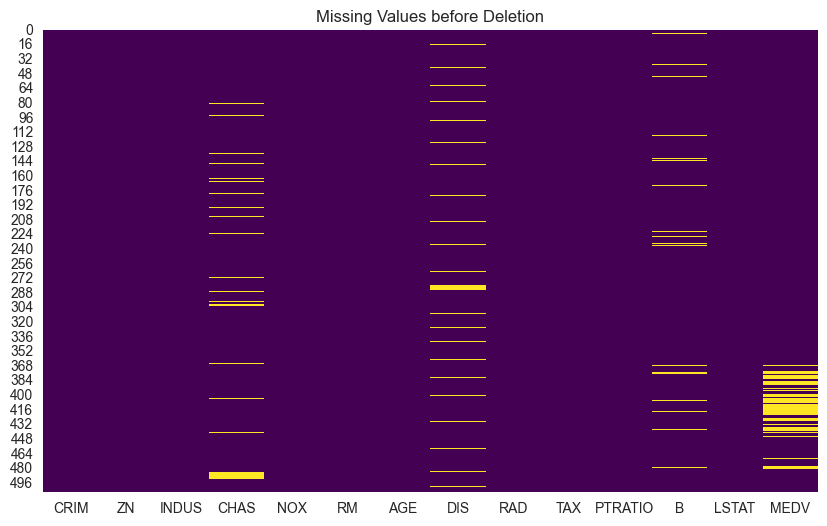

(391, 14)
Missing Values after Deletion: 


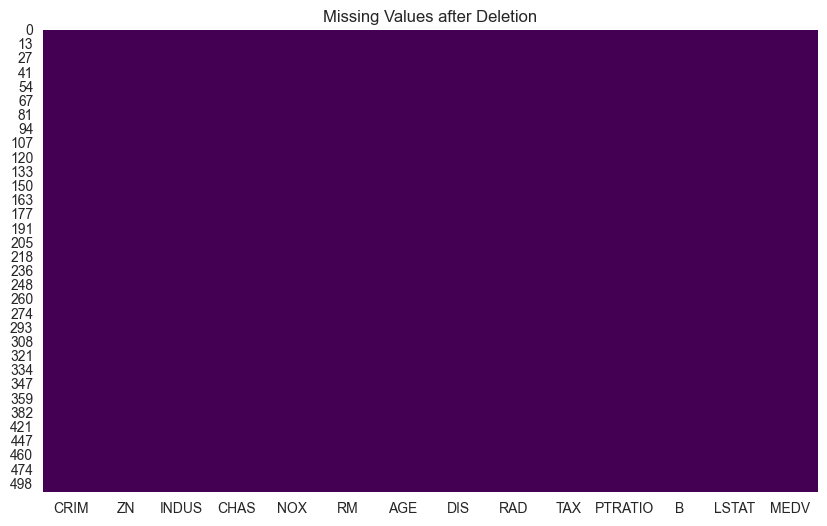

In [15]:
data = pd.read_excel('DataSet.xlsx')

print ("Data Shape: ", data.shape)
print("Missing Values: ")
print(data.isnull().sum())
print(data.shape)
plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values before Deletion')
plt.show()

cleaned_data = data.copy()


cleaned_data = data.drop(data[data.isnull().any(axis=1)].index)
print(cleaned_data.shape)

print("Missing Values after Deletion: ")
plt.figure(figsize=(10, 6))
sns.heatmap(cleaned_data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values after Deletion')
plt.show()



we can see that after removing the missing values we lost some data and we have 394 rows and 14 columns in the data.
that we lost 112 rows after removing the missing values.
this is bad for model because we lost some data.

# Method 2 - Mean Imputation

Description: This method replaces missing values with the mean, median, or mode of the column.

When to Use:
Mean: Suitable for continuous data without outliers.
Median: Best for continuous data with outliers.
Mode: Ideal for categorical data.

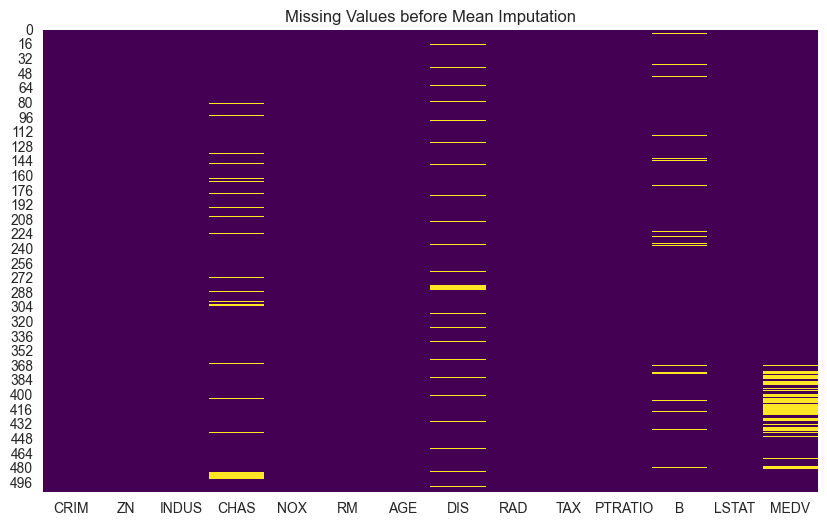

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 55.5 KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN    

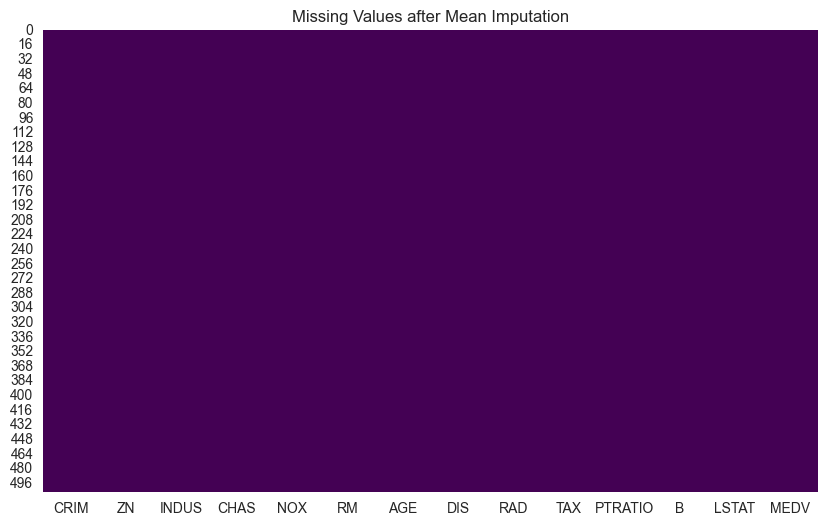

In [16]:
# plot the data before imputation
plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values before Mean Imputation')
plt.show()


data_mean = data.copy() 
data_mean = data_mean.fillna(data_mean.mean())
data_max = data.copy()
data_max = data_max.fillna(data_max.max())
data_mode = data.copy()
data_mode = data_mode.fillna(data_mode.mode().iloc[0])



print(data_max.info())
print(data_mean.info())
print(data_mode.info())


# plt the data after imputation

plt.figure(figsize=(10, 6))
sns.heatmap(data_mean.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values after Mean Imputation')
plt.show()





because we have some missing values in the data we can use imputation method to replace the missing values with the mean of the column.
in this method we dont lose any data and we can replace the missing values with the mean of the column.

Question 8 - Feature Selection

Yes, the possibility of dropping some columns from a dataset exists, and it is often a necessary step in data preprocessing for several reasons:

for feature CHAS we can see that it has only 2 unique values and it is a binary value so we can drop it.


# Method 3 - Using Predictive Models (e.g., K-Nearest Neighbors)

Reason: This method leverages the relationships between features to predict and fill in missing values. It is more sophisticated and often more accurate than simpler methods like mean or median imputation.

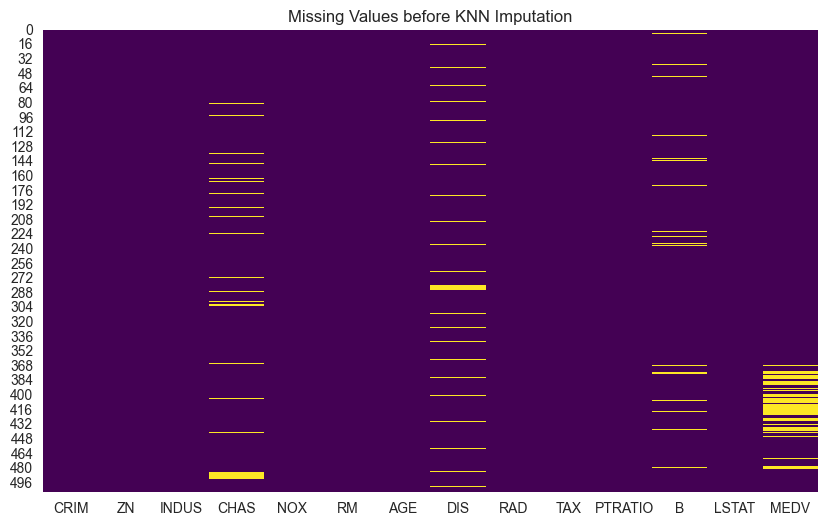

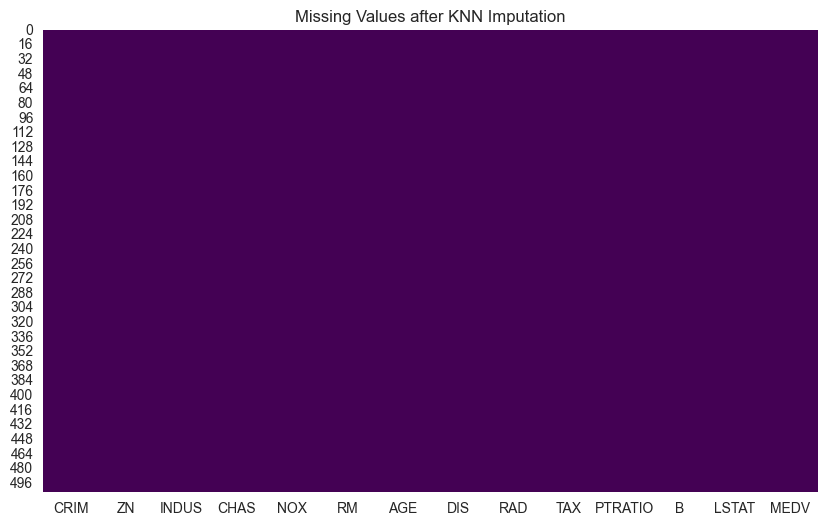

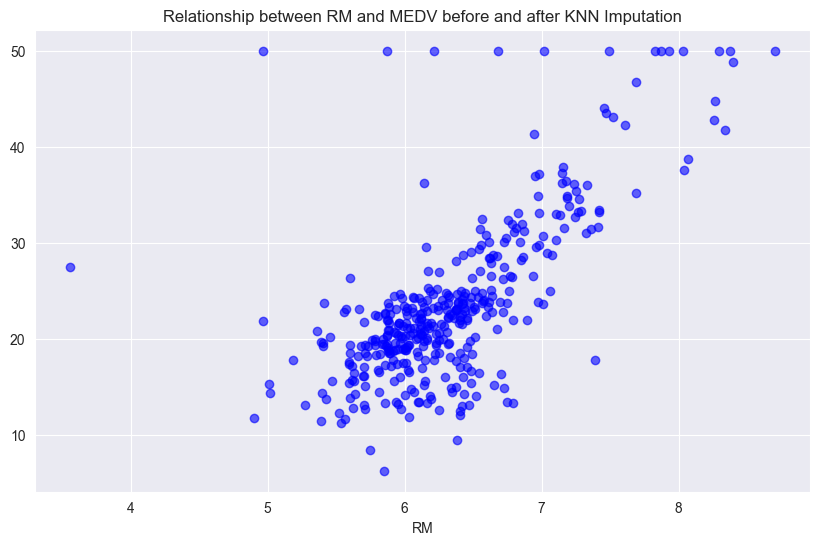

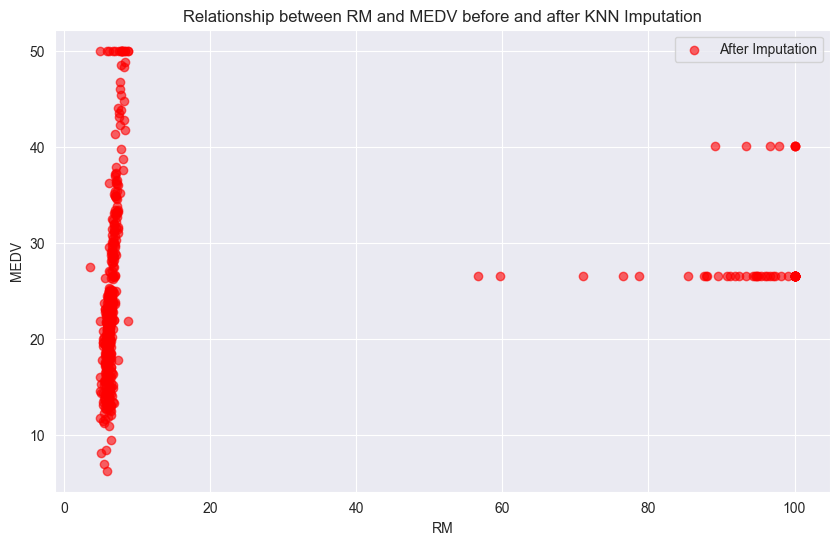

In [17]:
import pandas as pd
from sklearn.impute import KNNImputer

data = pd.read_excel('DataSet.xlsx')
# plt the data before imputation
plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values before KNN Imputation')
plt.show()


imputer = KNNImputer(n_neighbors=2)
data_imputed = imputer.fit_transform(data)

data_imputed = pd.DataFrame(data_imputed, columns=data.columns)

# plt the data after imputation

plt.figure(figsize=(10, 6))
sns.heatmap(data_imputed.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values after KNN Imputation')
plt.show()



# we can show that scatter for MEDV and RM before and after imputation

# befor with dropona
data = pd.read_excel('DataSet.xlsx')
data = data.drop(data[data.isnull().any(axis=1)].index)

plt.figure(figsize=(10, 6))
plt.scatter(data['RM'], data['MEDV'], color='blue', alpha=0.6, label='Before Imputation')
plt.title('Relationship between RM and MEDV before and after KNN Imputation')
plt.xlabel('RM')

# we can show that scatter for MEDV and RM with KNN imputation

 



plt.figure(figsize=(10, 6))
plt.scatter(data_imputed['RM'], data_imputed['MEDV'], color='red', alpha=0.6, label='After Imputation')
plt.title('Relationship between RM and MEDV before and after KNN Imputation')
    
        
plt.xlabel('RM')
plt.ylabel('MEDV')
plt.legend()
plt.show()

    


we can see that with KNN imputation we dont lose any data and we can replace the missing values with the mean of the column.
we just have to be careful about the number of neighbors that we use in the KNN imputation.



Question 8 - Drop Columns


In [18]:

data.drop(columns=['CHAS'], inplace=True)
print(data.head())


      CRIM    ZN  INDUS    NOX     RM   AGE     DIS  RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31  0.538  6.575  65.2  4.0900    1  296.0     15.3   
1  0.02731   0.0   7.07  0.469  6.421  78.9  4.9671    2  242.0     17.8   
2  0.02729   0.0   7.07  0.469  7.185  61.1  4.9671    2  242.0     17.8   
4  0.06905   0.0   2.18  0.458  7.147  54.2  6.0622    3  222.0     18.7   
5  0.02985   0.0   2.18  0.458  6.430  58.7  6.0622    3  222.0     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
4  396.90   5.33  36.2  
5  394.12   5.21  28.7  


Question 9 - Categorizing Features

In the context of data analysis and machine learning, features in a dataset can be broadly categorized into two types: **numerical features** and **categorical features**. Understanding the distinction between these two types is crucial for choosing the right preprocessing techniques and machine learning models.

### Numerical Features
Numerical features (or quantitative features) represent measurable quantities and are expressed as numbers. They can be further divided into two sub-categories:
- **Continuous features**: These represent measurements and can take any value within a range. Examples include height, weight, temperature, and price.
- **Discrete features**: These represent countable values, often integers, and are typically counts of occurrences or items. Examples include the number of rooms in a house or the number of children in a family.

### Categorical Features
Categorical features (or qualitative features) represent qualitative data that can be separated into categories but are not inherently numerical. They are often text or labels and are not usually used in mathematical calculations directly. Categorical features can be:
- **Nominal**: No natural order or ranking exists among the categories. Examples include colors, zip codes, or types of cuisine.
- **Ordinal**: There is a clear ordering or ranking of the categories, but the differences between the categories are not necessarily consistent. Examples include education level (e.g., high school, undergraduate, graduate), income level, or product ratings.

### Identifying Features in a Dataset


- **Numerical Columns**: These columns contain continuous or discrete numerical values.
  - CRIM: Per capita crime rate by town
  - ZN: Proportion of residential land zoned for lots over 25,000 sq. ft.
  - INDUS: Proportion of non-retail business acres per town
  - NOX: Nitric oxides concentration (parts per 10 million)
  - RM: Average number of rooms per dwelling
  - AGE: Proportion of owner-occupied units built prior to 1940
  - DIS: Weighted distances to five Boston employment centers
  - RAD: Index of accessibility to radial highways
  - TAX: Full-value property tax rate per $10,000
  - PTRATIO: Pupil-teacher ratio by town
  - B: 1000(Bk - 0.63)^2 where Bk is the proportion of black people by town
  - LSTAT: Percentage of lower status of the population
  - MEDV: Median value of owner-occupied homes in $1000s

- **Categorical Columns**: These columns contain categorical values or binary indicators.
  - CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)

- **Numerical Columns**: CRIM, ZN, INDUS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT, MEDV
- **Categorical Column**: CHAS

Now let's proceed to handle missing values using the methods mentioned earlier.

### Handling Missing Values

1. **Removing Rows with Missing Values**
2. **Imputation with Mean**
3. **Using Predictive Models (e.g., K-Nearest Neighbors)**




Question 10 - Normalization and Standardization

In numerical features within a dataset, **normalizing** and **standardizing** are two common preprocessing techniques used to ensure that the data within these features contributes equally to analysis and model performance. Both techniques help in handling features that operate on different scales and ranges, but they do so in slightly different ways.

### Purpose of Normalizing and Standardizing
- **Normalizing** (also known as Min-Max Scaling): This method rescales the data to a fixed range, usually 0 to 1, or -1 to 1, making sure that the proportion between the original data values is maintained. The primary purpose is to avoid any feature dominating the model due to its scale. Normalization is beneficial for algorithms that calculate distances between data points (like k-nearest neighbors (KNN) and gradient descent-based algorithms), as it ensures that the distance measure is not skewed by the scale of the data.
  
- **Standardizing** (also known as Z-score normalization): This technique transforms the data to have zero mean and unit variance. This scaling does not bound values to a specific range, which might be a drawback for some algorithms (like neural networks that expect an input range of 0 to 1), but it’s very useful for algorithms that assume data is normally distributed, such as logistic regression and support vector machines.

### Differences Between Normalizing and Standardizing
- **Range**: Normalization changes values to a specific range (0 to 1 or -1 to 1). Standardization transforms data into a range based on the standard deviation, with a mean of 0.
- **Impact on Distribution**: Normalization maintains the original distribution of the data without handling the outlier values effectively. Standardization rescales the data distribution based on the mean and standard deviation, which makes it less sensitive to outliers.
- **Use Case**: Normalization is often used when the data needs to be normalized to a bounded interval and is particularly important for neural networks. Standardization is preferred when the daa needs to conform to a normal distribution assumption.


in this project we dont need to normalize the data because we are using linear regression and it is not necessary to normalize the data for linear regression.
and for other features we dont need to normalize the data .


Question 11 - Encoding Categorical Features
### Normalizing and Standardizing Numerical Features

#### Purpose
Normalizing and standardizing numerical features are preprocessing techniques used to adjust the scale of the data, which can significantly impact the performance of machine learning algorithms.

- **Normalizing**: This process rescales the data to a fixed range, typically between 0 and 1. The formula for normalization is:
  $$
  X_{norm} = \frac{X - X_{\min}}{X_{\max} - X_{\min}}
  $$
  Normalizing is useful when you want the features to be on the same scale, especially when the range of values varies greatly between features.

- **Standardizing**: This process rescales the data to have a mean of 0 and a standard deviation of 1. The formula for standardization is:

  $$
  X_{std} = \frac{X - \mu}{\sigma}
  $$
  where \( \mu \) is the mean of the feature and \( \sigma \) is the standard deviation. Standardizing is useful when you want the features to have a normal distribution (bell curve), which can improve the performance of algorithms that assume normally distributed data (e.g., linear regression, logistic regression).

#### Differences
- **Scale**:
  - **Normalization** scales data to a fixed range (0 to 1).
  - **Standardization** scales data to have a mean of 0 and a standard deviation of 1.

- **Usage**:
  - **Normalization** is preferred when you need to bound the values within a specific range, often for algorithms that do not assume a normal distribution (e.g., K-Nearest Neighbors, neural networks).
  - **Standardization** is preferred when the data needs to have properties of a standard normal distribution, often for algorithms that assume normally distributed inputs (e.g., linear regression, logistic regression).



Question 12 - Splitting the Dataset

### Train, Validation, and Test Data

In machine learning, datasets are typically divided into three subsets: train, validation, and test. This division helps in evaluating the performance of models and prevents overfitting.

1. **Train Set**:
   - Used to train the model.
   - The model learns patterns from this data.
   - Usually constitutes 60-80% of the total dataset.

2. **Validation Set**:
   - Used to tune hyperparameters and make decisions about the model architecture.
   - Helps in evaluating the model during training to prevent overfitting.
   - Typically constitutes 10-20% of the total dataset.

3. **Test Set**:
   - Used to evaluate the final model.
   - The model does not see this data during training or validation.
   - Typically constitutes 10-20% of the total dataset.

#### Common Splitting Methods

1. **Random Split**:
   - Data is randomly divided into train, validation, and test sets.
   - Ensures that each subset is representative of the whole dataset.
    - Simple and commonly used.
    - Useful for general purposes.

2. **Stratified Split**:
   - Ensures that each subset has the same proportion of classes as the original dataset.
   - Useful for classification problems where class imbalance is an issue.
    - Helps in maintaining the distribution of classes across subsets.
    - Ensures that the model is trained on a representative sample of the data.

3. **Time-based Split**:
   - Used for time series data.
   - Data is split based on a time criterion, ensuring that the train set precedes the validation and test sets in time.
   - Useful for forecasting and predictive modeling on sequential data.
    - Helps in capturing temporal patterns in the data.
    - Ensures that the model is evaluated on future data.

4. **Cross-validation**:
   - The dataset is split into k subsets (folds).
   - The model is trained k times, each time using a different fold as the validation set and the remaining folds as the train set.
   - Helps in ensuring that the model performs well across different subsets of the data.
   - Useful for small datasets and hyperparameter tuning.
   - Provides a more robust estimate of model performance.
   - Common types include k-fold cross-validation and stratified k-fold cross-validation.






Question 13 - Additional Preprocessing Techniques

### Other Preprocessing Methods

Preprocessing is a crucial step in the machine learning pipeline. Beyond handling missing values, normalizing/standardizing data, and splitting datasets, several other preprocessing techniques can improve model performance and accuracy. Here are some common methods:

1. **Encoding Categorical Variables**:
   - **Label Encoding**: Converts categorical values into numerical values. Suitable for ordinal data where order matters.
   - **One-Hot Encoding**: Converts categorical values into a binary vector. Suitable for nominal data where order doesn't matter.

2. **Feature Scaling**:
   - **Normalization**: Scaling features to a range of [0, 1].
   - **Standardization**: Scaling features to have a mean of 0 and a standard deviation of 1.

3. **Handling Outliers**:
   - **Z-score Method**: Removing data points that are more than a certain number of standard deviations away from the mean.
   - **IQR Method**: Removing data points outside 1.5 times the interquartile range (IQR).

4. **Feature Engineering**:
   - **Polynomial Features**: Creating polynomial features to capture non-linear relationships.
   - **Interaction Features**: Creating features that are the product of two or more features.

5. **Dimensionality Reduction**:
   - **Principal Component Analysis (PCA)**: Reducing the number of features while retaining most of the variance.
   - **t-Distributed Stochastic Neighbor Embedding (t-SNE)**: Reducing the dimensions for visualization purposes.

6. **Data Augmentation**:
   - Generating new data points from existing ones, often used in image processing.
   - Techniques include flipping, rotating, and cropping images.

7. **Text Preprocessing**:
   - **Tokenization**: Splitting text into words or sentences.
   - **Stop Word Removal**: Removing common words that don't add much meaning.
   - **Stemming/Lemmatization**: Reducing words to their base or root form.


in project we can use Handle Outliers and Feature Engineering to improve the model performance.

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV     TAX_RM  
0     15.3  396.90   4.98  24.0  45.019011  
1     17.8  396.90   9.14  21.6  37.688834  
2     17.8  392.83   4.03  34.7  33.681280  
3     18.7     NaN   2.94  33.4  31.723350  
4     18.7  396.90   5.33  36.2  31.061984  


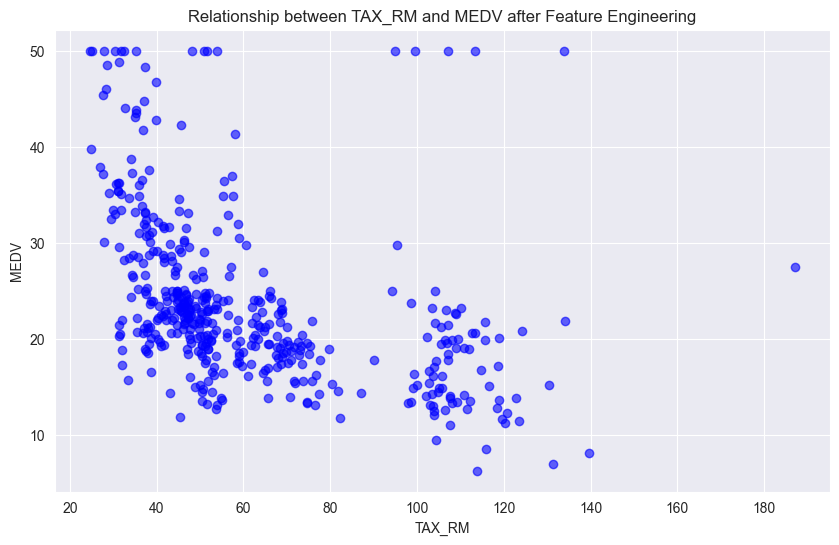

In [19]:
import pandas as pd
import numpy as np
# use feature engineering to create new feature and use it in the model



data = pd.read_excel('DataSet.xlsx')

# Feature Engineering: Creating a new feature 'TAX_RM' by dividing 'TAX' by 'RM'
data['TAX_RM'] = data['TAX'] / data['RM']
    
print(data.head())

# plot the data after feature engineering
plt.figure(figsize=(10, 6))
plt.scatter(data['TAX_RM'], data['MEDV'], color='blue', alpha=0.6)
plt.title('Relationship between TAX_RM and MEDV after Feature Engineering')
plt.xlabel('TAX_RM')
plt.ylabel('MEDV')
plt.show()



# Model Development

This section implements various machine learning algorithms for regression and classification tasks on the Boston Housing Dataset. Each subsection includes theoretical background, implementation, and evaluation.

## Linear Regression

Linear regression is a supervised learning algorithm that models the relationship between a dependent variable and one or more independent variables using a linear equation. The goal is to find the best-fitting line that minimizes the sum of squared errors.

### Manual Implementation

This code implements linear regression from scratch using the normal equation, without relying on scikit-learn libraries. It demonstrates the mathematical foundations of the algorithm.

[[1.    6.575]
 [1.    6.421]
 [1.    7.185]
 [1.    7.147]
 [1.    6.43 ]
 [1.    6.012]
 [1.    6.172]
 [1.    5.631]
 [1.    6.004]
 [1.    6.377]
 [1.    6.009]
 [1.    5.889]
 [1.    5.949]
 [1.    6.096]
 [1.    5.935]
 [1.    5.99 ]
 [1.    5.456]
 [1.    5.727]
 [1.    5.965]
 [1.    6.142]
 [1.    5.813]
 [1.    5.924]
 [1.    5.599]
 [1.    5.813]
 [1.    6.047]
 [1.    6.495]
 [1.    6.674]
 [1.    5.713]
 [1.    6.072]
 [1.    5.95 ]
 [1.    5.701]
 [1.    6.096]
 [1.    5.933]
 [1.    5.841]
 [1.    5.966]
 [1.    6.595]
 [1.    6.77 ]
 [1.    6.169]
 [1.    6.211]
 [1.    6.069]
 [1.    5.682]
 [1.    5.786]
 [1.    6.03 ]
 [1.    5.399]
 [1.    5.602]
 [1.    6.115]
 [1.    6.511]
 [1.    5.998]
 [1.    5.888]
 [1.    7.249]
 [1.    6.383]
 [1.    6.816]
 [1.    6.145]
 [1.    5.927]
 [1.    5.966]
 [1.    6.456]
 [1.    6.762]
 [1.    7.104]
 [1.    6.29 ]
 [1.    5.787]
 [1.    5.878]
 [1.    5.594]
 [1.    5.885]
 [1.    6.417]
 [1.    5.961]
 [1.    6.065]
 [1.    6.

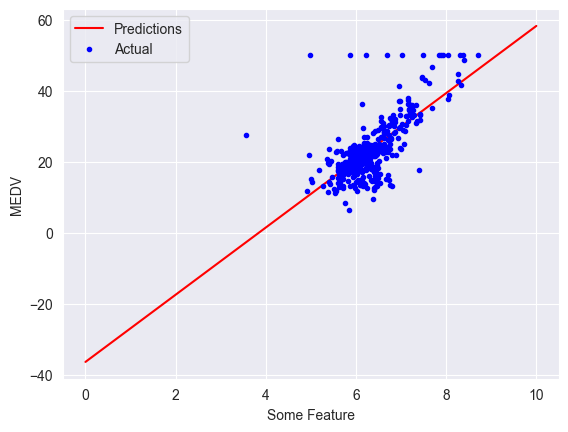

RMSE: 5.928865014773271
R² score: 0.4971617394900478


In [ ]:
data = pd.read_excel('DataSet.xlsx')
data = data.dropna()
X = data[['RM']]
y = data['MEDV']
X = X.values
y = y.values
X_b = np.c_[np.ones((X.shape[0], 1)), X]
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
X_new = np.array([[0], [10]])
X_new_b = np.c_[np.ones((2, 1)), X_new]
y_predict = X_new_b.dot(theta_best)
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.", label="Actual")
plt.xlabel("RM")
plt.ylabel("MEDV")
plt.legend()
plt.show()
y_train_predict = X_b.dot(theta_best)
rmse = np.sqrt(mean_squared_error(y, y_train_predict))
r2 = r2_score(y, y_train_predict)
print("RMSE:", rmse)
print("R² score:", r2)

## Linear Regression

Linear regression is a supervised learning algorithm that models the relationship between a dependent variable and one or more independent variables using a linear equation. The goal is to find the best-fitting line that minimizes the sum of squared errors.

### Manual Implementation

This code implements linear regression from scratch using the normal equation, without relying on scikit-learn libraries. It demonstrates the mathematical foundations of the algorithm.

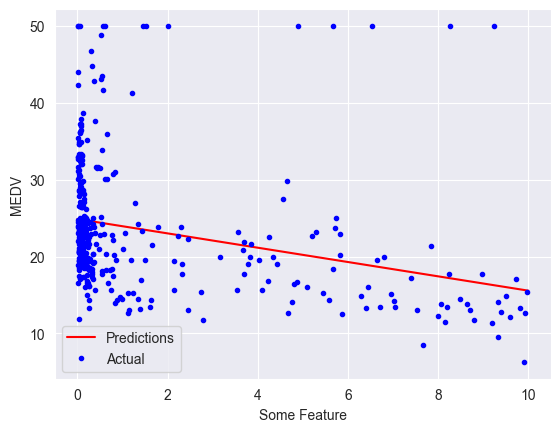

RMSE: 8.008301483122535
R² score: 0.08258461543872986


In [21]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_excel('DataSet.xlsx')
data = data.dropna() 

X = data[['CRIM']]  
y = data['MEDV']

X = X.values
y = y.values

X_b = np.c_[np.ones((X.shape[0], 1)), X] 
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)


X_new = np.array([[0], [10]])  
X_new_b = np.c_[np.ones((2, 1)), X_new] 
y_predict = X_new_b.dot(theta_best)
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.", label="Actual")
plt.xlabel("Some Feature")
plt.ylabel("MEDV")
plt.legend()
plt.show()



from sklearn.metrics import mean_squared_error, r2_score

y_train_predict = X_b.dot(theta_best)

rmse = np.sqrt(mean_squared_error(y, y_train_predict))
r2 = r2_score(y, y_train_predict)

print("RMSE:", rmse)
print("R² score:", r2)


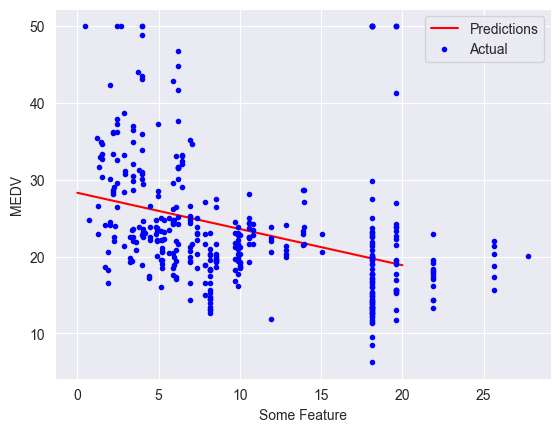

RMSE: 7.768485018088714
R² score: 0.13670772440007373


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_excel('DataSet.xlsx')
data = data.dropna() 

X = data[['INDUS']]  
y = data['MEDV']

X = X.values
y = y.values

X_b = np.c_[np.ones((X.shape[0], 1)), X]  
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

X_new = np.array([[0], [20]]) 
X_new_b = np.c_[np.ones((2, 1)), X_new]
y_predict = X_new_b.dot(theta_best)
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.", label="Actual")
plt.xlabel("Some Feature")
plt.ylabel("MEDV")
plt.legend()
plt.show()

from sklearn.metrics import mean_squared_error, r2_score
y_train_predict = X_b.dot(theta_best)
rmse = np.sqrt(mean_squared_error(y, y_train_predict))
r2 = r2_score(y, y_train_predict)

print("RMSE:", rmse)
print("R² score:", r2)


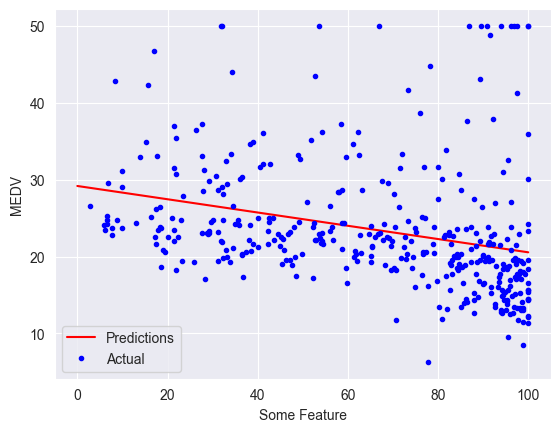

RMSE: 7.995714644728247
R² score: 0.0854661964032668


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_excel('DataSet.xlsx')
data = data.dropna() 

X = data[['AGE']] 
y = data['MEDV']

X = X.values
y = y.values

X_b = np.c_[np.ones((X.shape[0], 1)), X]
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)


X_new = np.array([[0], [100]]) 
X_new_b = np.c_[np.ones((2, 1)), X_new] 
y_predict = X_new_b.dot(theta_best)
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.", label="Actual")
plt.xlabel("Some Feature")
plt.ylabel("MEDV")
plt.legend()
plt.show()



from sklearn.metrics import mean_squared_error, r2_score
y_train_predict = X_b.dot(theta_best)
rmse = np.sqrt(mean_squared_error(y, y_train_predict))
r2 = r2_score(y, y_train_predict)

print("RMSE:", rmse)
print("R² score:", r2)


We can plt the data for each feature and the target variable to see the relationship between the feature and the target variable.

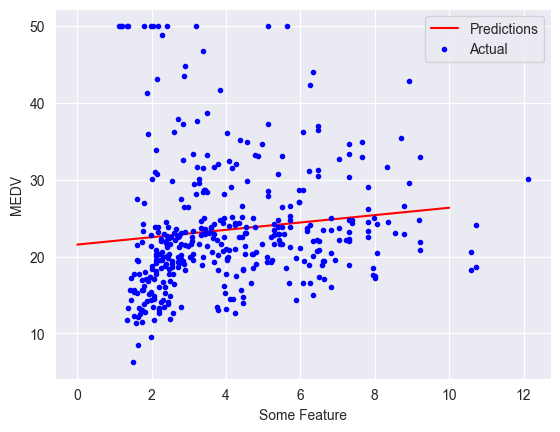

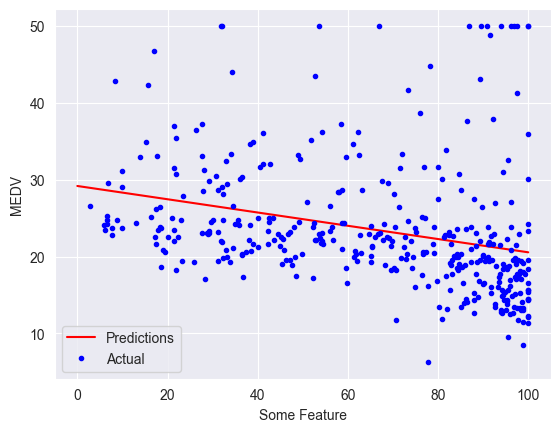

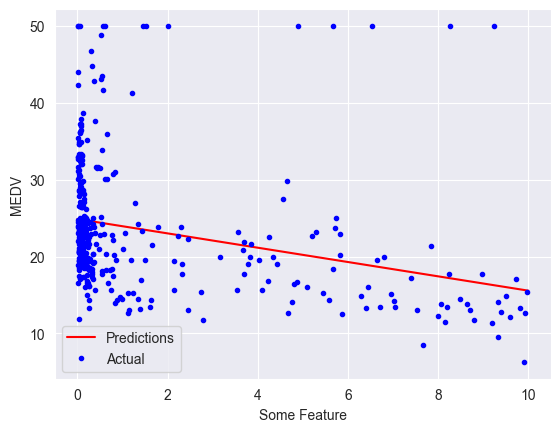

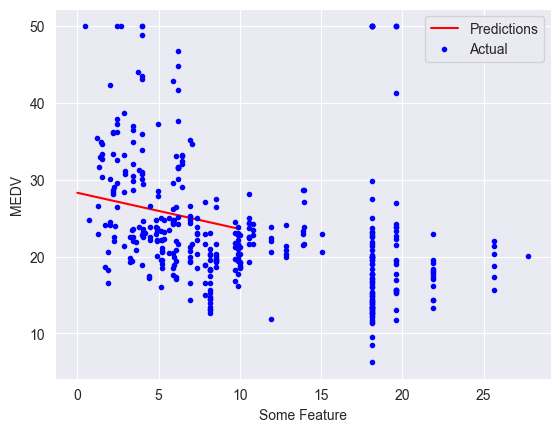

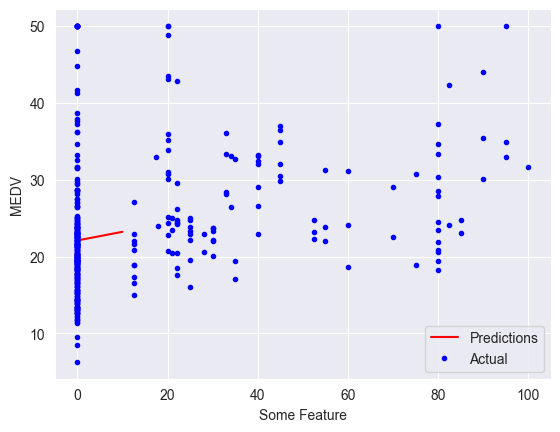

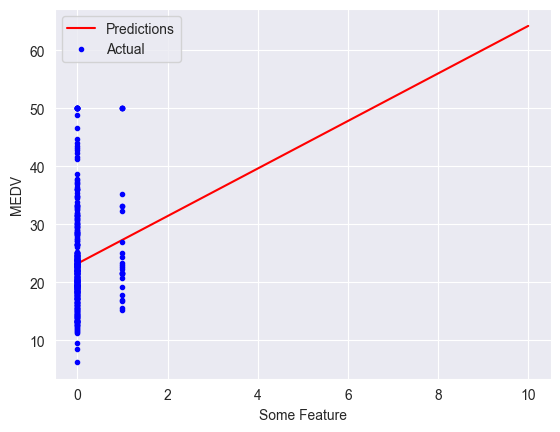

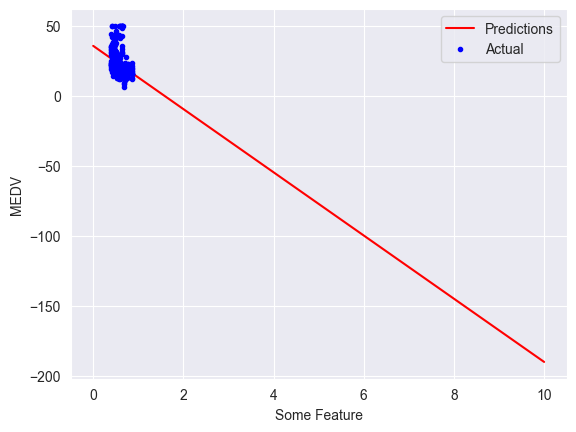

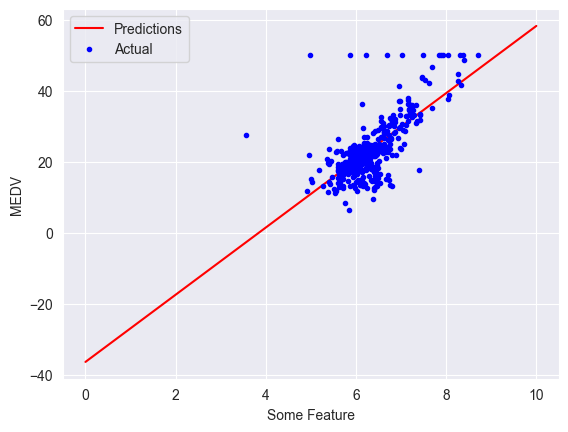

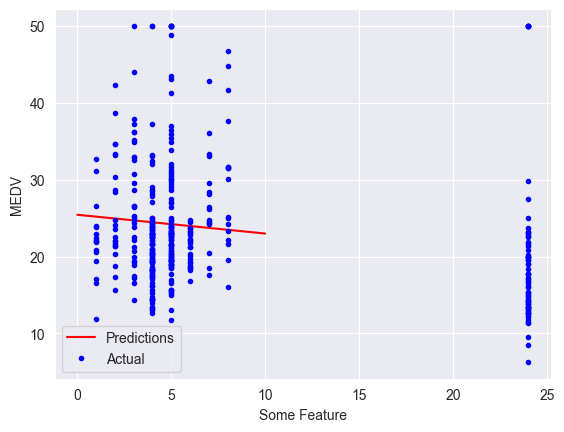

RMSE1: 8.298542585121476
R² score1: 0.014880663016412221
RMSE2: 7.995714644728247
R² score2: 0.0854661964032668
RMSE3: 8.008301483122535
R² score3: 0.08258461543872986
RMSE4: 7.768485018088714
R² score4: 0.13670772440007373
RMSE5: 7.913004807918764
R² score5: 0.10428870816292024
RMSE6: 8.298386869310225
R² score6: 0.014917632692945215
RMSE7: 7.957927590180171
R² score7: 0.09408978598536322
RMSE8: 5.928865014773271
R² score8: 0.4971617394900478
RMSE9: 8.152386379475741
R² score9: 0.04927547001952559
(391, 14)


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_excel('DataSet.xlsx')
data = data.dropna() 

X1 = data[['DIS']] 
X2 = data[['AGE']] 
X3 = data[['CRIM']] 
X4 = data[['INDUS']]
X5 = data[['ZN']] 
X6 = data[['CHAS']] 
X7 = data[['NOX']] 
X8 = data[['RM']] 
X9 = data[['RAD']] 

y = data['MEDV']

X1 = X1.values
X2 = X2.values
X3 = X3.values
X4 = X4.values
X5 = X5.values
X6 = X6.values
X7 = X7.values
X8 = X8.values
X9 = X9.values

y = y.values

X_b1 = np.c_[np.ones((X1.shape[0], 1)), X1]  
X_b2 = np.c_[np.ones((X2.shape[0], 1)), X2]  
X_b3 = np.c_[np.ones((X3.shape[0], 1)), X3] 
X_b4 = np.c_[np.ones((X4.shape[0], 1)), X4] 
X_b5 = np.c_[np.ones((X5.shape[0], 1)), X5] 
X_b6 = np.c_[np.ones((X6.shape[0], 1)), X6] 
X_b7 = np.c_[np.ones((X7.shape[0], 1)), X7]
X_b8 = np.c_[np.ones((X8.shape[0], 1)), X8]  
X_b9 = np.c_[np.ones((X9.shape[0], 1)), X9] 

theta_best1 = np.linalg.inv(X_b1.T.dot(X_b1)).dot(X_b1.T).dot(y)
theta_best2 = np.linalg.inv(X_b2.T.dot(X_b2)).dot(X_b2.T).dot(y)
theta_best3 = np.linalg.inv(X_b3.T.dot(X_b3)).dot(X_b3.T).dot(y)
theta_best4 = np.linalg.inv(X_b4.T.dot(X_b4)).dot(X_b4.T).dot(y)
theta_best5 = np.linalg.inv(X_b5.T.dot(X_b5)).dot(X_b5.T).dot(y)
theta_best6 = np.linalg.inv(X_b6.T.dot(X_b6)).dot(X_b6.T).dot(y)
theta_best7 = np.linalg.inv(X_b7.T.dot(X_b7)).dot(X_b7.T).dot(y)
theta_best8 = np.linalg.inv(X_b8.T.dot(X_b8)).dot(X_b8.T).dot(y)
theta_best9 = np.linalg.inv(X_b9.T.dot(X_b9)).dot(X_b9.T).dot(y)
    
X_new1 = np.array([[0], [10]])  
X_new_b1 = np.c_[np.ones((2, 1)), X_new1]
y_predict1 = X_new_b1.dot(theta_best1)
    
X_new2 = np.array([[0], [100]])
X_new_b2 = np.c_[np.ones((2, 1)), X_new2]  
y_predict2 = X_new_b2.dot(theta_best2)

X_new3 = np.array([[0], [10]]) 
X_new_b3 = np.c_[np.ones((2, 1)), X_new3]  
y_predict3 = X_new_b3.dot(theta_best3)

X_new4 = np.array([[0], [10]]) 
X_new_b4 = np.c_[np.ones((2, 1)), X_new4]
y_predict4 = X_new_b4.dot(theta_best4)

X_new5 = np.array([[0], [10]]) 
X_new_b5 = np.c_[np.ones((2, 1)), X_new5]
y_predict5 = X_new_b5.dot(theta_best5)

X_new6 = np.array([[0], [10]])
X_new_b6 = np.c_[np.ones((2, 1)), X_new6]  
y_predict6 = X_new_b6.dot(theta_best6)

X_new7 = np.array([[0], [10]])  
X_new_b7 = np.c_[np.ones((2, 1)), X_new7]  
y_predict7 = X_new_b7.dot(theta_best7)

X_new8 = np.array([[0], [10]]) 
X_new_b8 = np.c_[np.ones((2, 1)), X_new8]  
y_predict8 = X_new_b8.dot(theta_best8)

X_new9 = np.array([[0], [10]]) 
X_new_b9 = np.c_[np.ones((2, 1)), X_new9]  
y_predict9 = X_new_b9.dot(theta_best9)

plt.plot(X_new1, y_predict1, "r-", label="Predictions")
plt.plot(X1, y, "b.", label="Actual")
plt.xlabel("Some Feature")
    
plt.ylabel("MEDV")
plt.legend()
plt.show()
    
plt.plot(X_new2, y_predict2, "r-", label="Predictions")
plt.plot(X2, y, "b.", label="Actual")
plt.xlabel("Some Feature")

plt.ylabel("MEDV")
plt.legend()
plt.show()

plt.plot(X_new3, y_predict3, "r-", label="Predictions")
plt.plot(X3, y, "b.", label="Actual")
plt.xlabel("Some Feature")

plt.ylabel("MEDV")
plt.legend()
plt.show()

plt.plot(X_new4, y_predict4, "r-", label="Predictions")
plt.plot(X4, y, "b.", label="Actual")
plt.xlabel("Some Feature")

plt.ylabel("MEDV")
plt.legend()
plt.show()

plt.plot(X_new5, y_predict5, "r-", label="Predictions")
plt.plot(X5, y, "b.", label="Actual")
plt.xlabel("Some Feature")

plt.ylabel("MEDV")
plt.legend()
plt.show()

plt.plot(X_new6, y_predict6, "r-", label="Predictions")
plt.plot(X6, y, "b.", label="Actual")
plt.xlabel("Some Feature")

plt.ylabel("MEDV")
plt.legend()
plt.show()

plt.plot(X_new7, y_predict7, "r-", label="Predictions")
plt.plot(X7, y, "b.", label="Actual")
plt.xlabel("Some Feature")
    
plt.ylabel("MEDV")
plt.legend()
plt.show()

plt.plot(X_new8, y_predict8, "r-", label="Predictions")
plt.plot(X8, y, "b.", label="Actual")
plt.xlabel("Some Feature")

plt.ylabel("MEDV")
plt.legend()
plt.show()

plt.plot(X_new9, y_predict9, "r-", label="Predictions")
plt.plot(X9, y, "b.", label="Actual")
plt.xlabel("Some Feature")

plt.ylabel("MEDV")
plt.legend()
plt.show()

from sklearn.metrics import mean_squared_error, r2_score

y_train_predict1 = X_b1.dot(theta_best1)
y_train_predict2 = X_b2.dot(theta_best2)
y_train_predict3 = X_b3.dot(theta_best3)
y_train_predict4 = X_b4.dot(theta_best4)
y_train_predict5 = X_b5.dot(theta_best5)
y_train_predict6 = X_b6.dot(theta_best6)
y_train_predict7 = X_b7.dot(theta_best7)
y_train_predict8 = X_b8.dot(theta_best8)
y_train_predict9 = X_b9.dot(theta_best9)

rmse1 = np.sqrt(mean_squared_error(y, y_train_predict1))
r2_1 = r2_score(y, y_train_predict1)

rmse2 = np.sqrt(mean_squared_error(y, y_train_predict2))
r2_2 = r2_score(y, y_train_predict2)

rmse3 = np.sqrt(mean_squared_error(y, y_train_predict3))
r2_3 = r2_score(y, y_train_predict3)

rmse4 = np.sqrt(mean_squared_error(y, y_train_predict4))
r2_4 = r2_score(y, y_train_predict4)

rmse5 = np.sqrt(mean_squared_error(y, y_train_predict5))
r2_5 = r2_score(y, y_train_predict5)

rmse6 = np.sqrt(mean_squared_error(y, y_train_predict6))
r2_6 = r2_score(y, y_train_predict6)

rmse7 = np.sqrt(mean_squared_error(y, y_train_predict7))
r2_7 = r2_score(y, y_train_predict7)

rmse8 = np.sqrt(mean_squared_error(y, y_train_predict8))
r2_8 = r2_score(y, y_train_predict8)

rmse9 = np.sqrt(mean_squared_error(y, y_train_predict9))
r2_9 = r2_score(y, y_train_predict9)

print("RMSE1:", rmse1)
print("R² score1:", r2_1)

print("RMSE2:", rmse2)
print("R² score2:", r2_2)

print("RMSE3:", rmse3)
print("R² score3:", r2_3)

print("RMSE4:", rmse4)
print("R² score4:", r2_4)

print("RMSE5:", rmse5)
print("R² score5:", r2_5)

print("RMSE6:", rmse6)
print("R² score6:", r2_6)

print("RMSE7:", rmse7)
print("R² score7:", r2_7)

print("RMSE8:", rmse8)
print("R² score8:", r2_8)

print("RMSE9:", rmse9)
print("R² score9:", r2_9)



print(data.shape)

Question 19 - Evaluate Predictions

Plotting the data for each feature and the target variable helps us understand the relationship between the feature and the target variable. We can see that some features have a linear relationship with the target variable, while others do not. The RMSE and R² score help us evaluate the model's performance for each feature. Based on these metrics, we can determine which features provide the most accurate predictions for the target variable.

now we want to plot the R2 score for each feature to see which feature is the best for the model.
and RMSE for each feature to see which feature is the best for the model.

## R² Score and RMSE for Each Feature


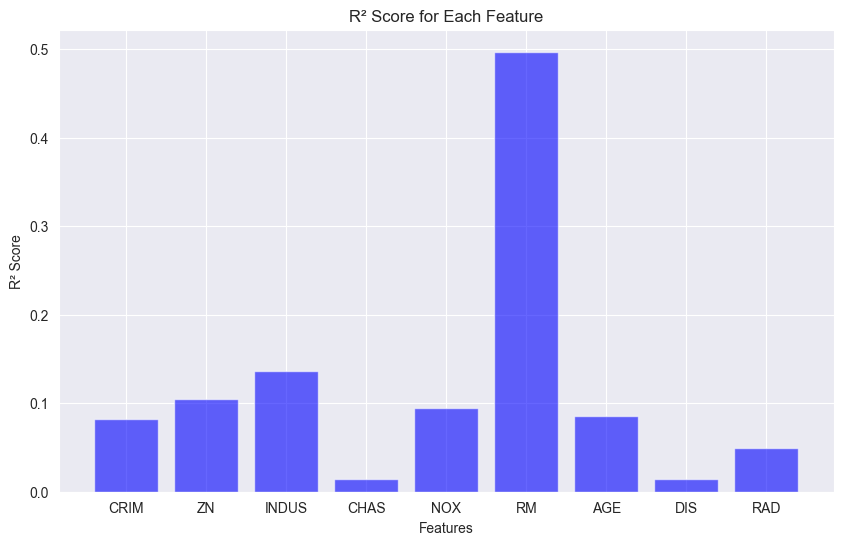

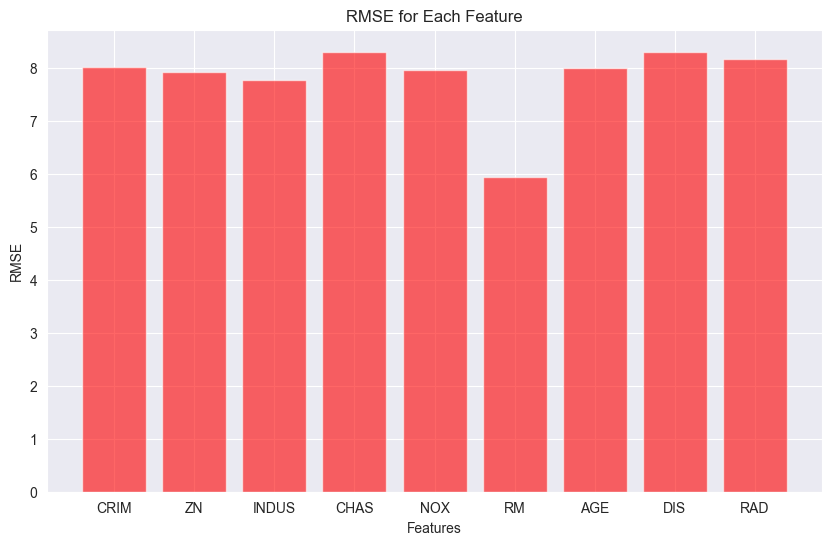

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_excel('DataSet.xlsx')
data = data.dropna()

Xs = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD']
Y = 'MEDV'

r2_scores = []
rmses = []

for X in Xs:
    X = data[[X]]
    y = data[Y]

    X = X.values
    y = y.values

    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

    y_train_predict = X_b.dot(theta_best)

    rmse = np.sqrt(mean_squared_error(y, y_train_predict))
    r2 = r2_score(y, y_train_predict)

    r2_scores.append(r2)
    rmses.append(rmse)
    
    
plt.figure(figsize=(10, 6))
plt.bar(Xs, r2_scores, color='blue', alpha=0.6)

plt.xlabel('Features')
plt.ylabel('R² Score')
plt.title('R² Score for Each Feature')
plt.show()


plt.figure(figsize=(10, 6))
plt.bar(Xs, rmses, color='red', alpha=0.6)
    
plt.xlabel('Features')
plt.ylabel('RMSE')
    
plt.title('RMSE for Each Feature')
plt.show()



Question 20 - Visual Comparison with Scatter Plot

A scatter plot is a useful visualization tool to compare the predicted values with the actual values. By plotting the actual values on the x-axis and the predicted values on the y-axis, we can visually assess the model's performance. The line \( y = x \) represents perfect predictions, where the predicted values match the actual values. Points closer to this line indicate more accurate predictions, while points further away indicate prediction errors.

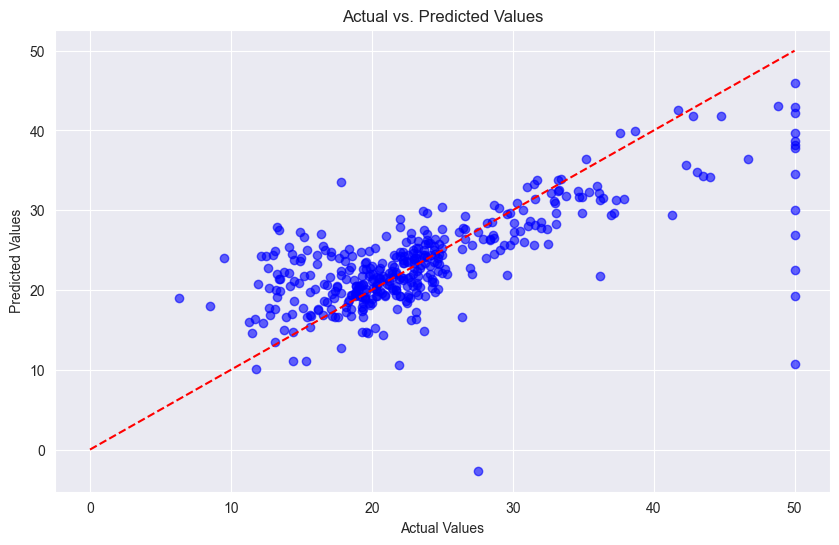

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_excel('DataSet.xlsx')
data = data.dropna()

X = data[['RM']]
y = data['MEDV']

X = X.values
y = y.values

X_b = np.c_[np.ones((X.shape[0], 1)), X]
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

y_train_predict = X_b.dot(theta_best)

plt.figure(figsize=(10, 6))
plt.scatter(y, y_train_predict, color='blue', alpha=0.6)
plt.plot([0, 50], [0, 50], color='red', linestyle='--')
plt.title('Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()


Question 17 - Linear Regression Implementation

In [27]:
import numpy as np

def linear_regression(input, output):
    

    x_mean = np.mean(input)
    y_mean = np.mean(output)
    
    numerator = np.sum((input - x_mean) * (output - y_mean))
    denominator = np.sum((input - x_mean) ** 2)
    
    alpha_hat = numerator / denominator
    
    beta_hat = y_mean - alpha_hat * x_mean
    
    
    
    
    
    return alpha_hat, beta_hat

input_data = np.array([1, 2, 3, 4, 5])
output_data = np.array([2, 4, 6, 8, 10])

alpha, beta = linear_regression(input_data, output_data)
print("Slope (alpha):", alpha)
print("Intercept (beta):", beta)


Slope (alpha): 2.0
Intercept (beta): 0.0


we can see that we use numerator and denominator to calculate the alpha and beta.




The RMSE has no bound, thus it becomes challenging to determine whether a particular RMSE value is considered good or bad without any reference point. Instead, we use R2 score. The R2 score is calculated by comparing the sum of the squared differences between the actual and predicted values of the dependent variable to the total sum of squared differences between the actual and mean values of the dependent variable. The R2 score is formulated as below:

$$R^2 = 1 - \frac{SSres}{SStot} = 1 - \frac{\sum_{i=1}^{n} (y_{i,true} - y_{i,pred})^2}{\sum_{i=1}^{n} (y_{i,true} - \bar{y}_{true})^2} $$






In [28]:
def get_r2_score(predicted_values, actual_values):
    ss_res = np.sum((actual_values - predicted_values) ** 2)
    ss_tot = np.sum((actual_values - np.mean(actual_values)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    return r2

predicted_values = np.array([2, 4, 6, 8, 10])
actual_values = np.array([3, 4, 6, 8, 11])  

r2_score = get_r2_score(predicted_values, actual_values)
print("R-squared Score:", r2_score)

R-squared Score: 0.9514563106796117


now we want to predict the values of the target variable based on the input values and the calculated parameters.


Slope (alpha): 9.461037703485736
Intercept (beta): -36.34471991394305


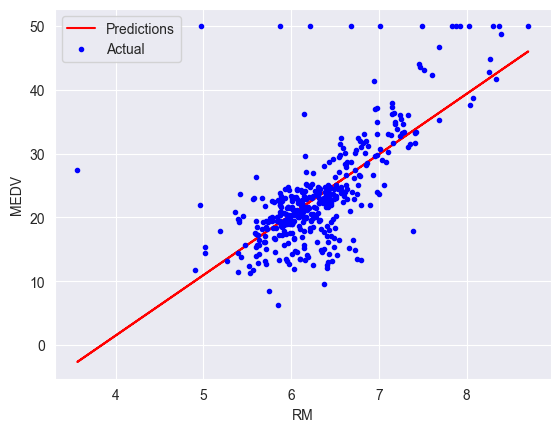

R2 error:  0.4971617394900477


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


data = pd.read_excel('DataSet.xlsx')
data = data.dropna()

X = data[['RM']]
y = data['MEDV']

X = X.values
y = y.values

alpha, beta = linear_regression(X.flatten(), y)
print("Slope (alpha):", alpha)
print("Intercept (beta):", beta)




X_new = X.flatten()
y_predict = alpha * X_new + beta

plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.", label="Actual")
plt.xlabel("RM")
plt.ylabel("MEDV")
plt.legend()
plt.show()



R2_error = get_r2_score(y_predict, y)

print("R2 error: ", R2_error)



we get the R2 error 0.48  

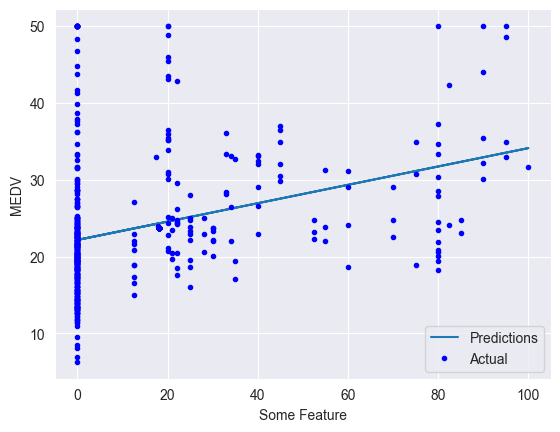

R2 error:  0.10936669795687981


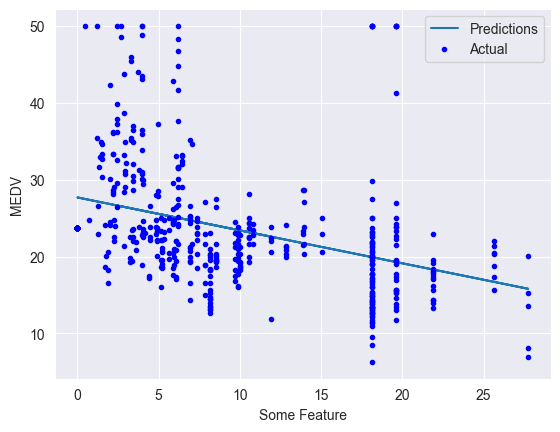

R2 error:  0.13619263239823953


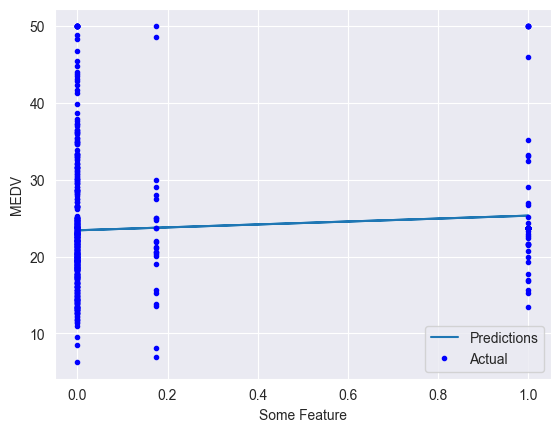

R2 error:  0.0071995496300873985


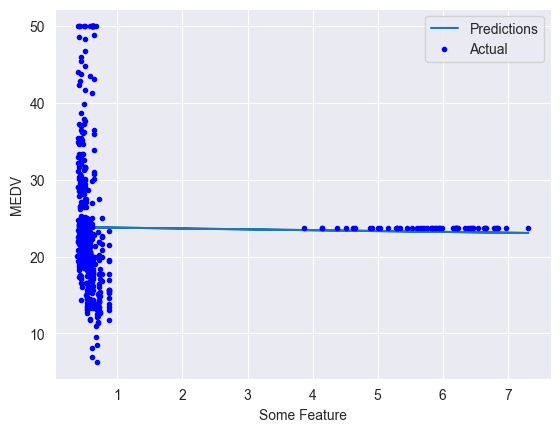

R2 error:  0.00047229977877083495


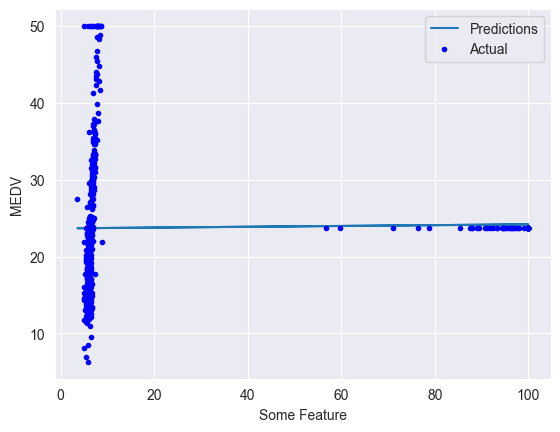

R2 error:  0.0002936155099964033


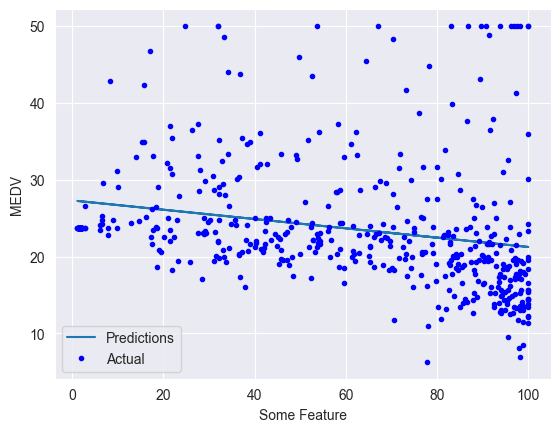

R2 error:  0.05798341119725092


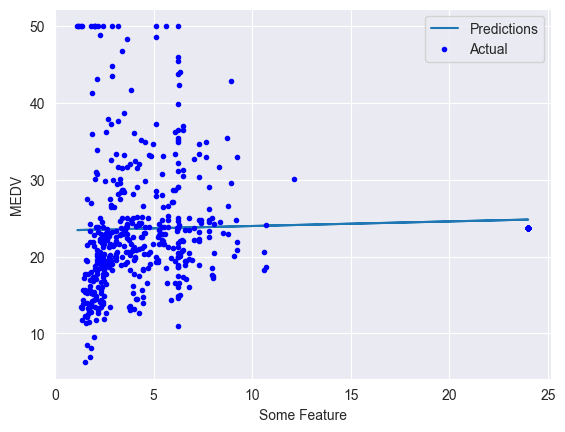

R2 error:  0.002076696347931062


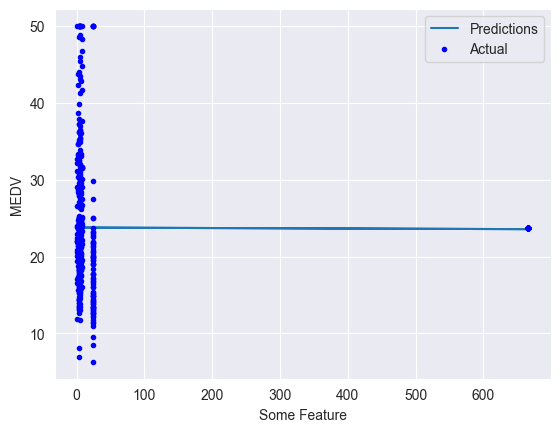

R2 error:  5.824308180846227e-05


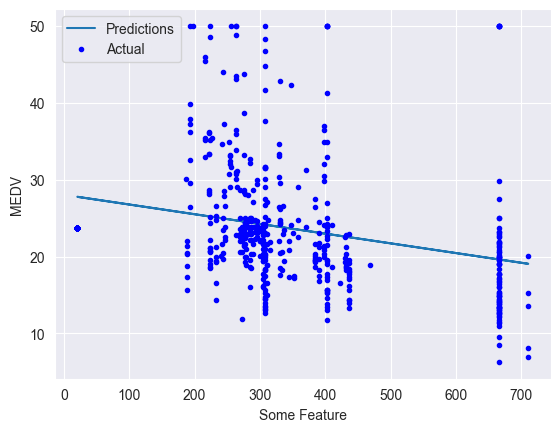

R2 error:  0.07496246355866787


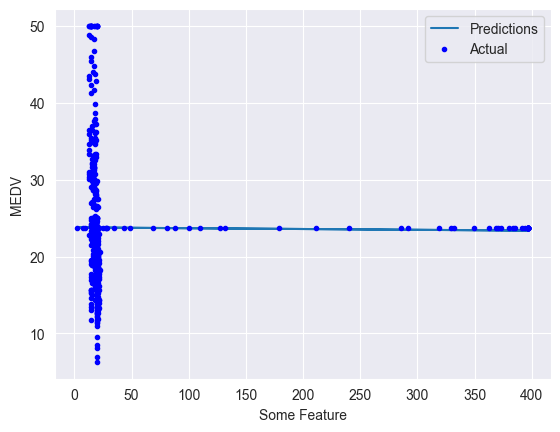

R2 error:  0.00011986651838979956


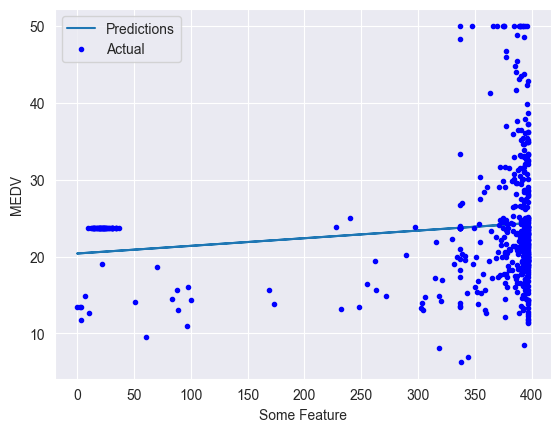

R2 error:  0.020146376241337305


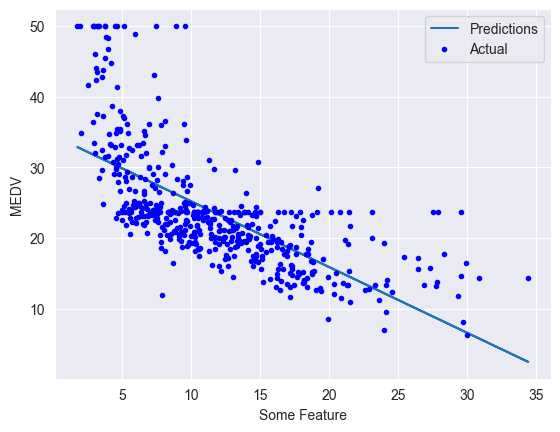

R2 error:  0.45900276012203856


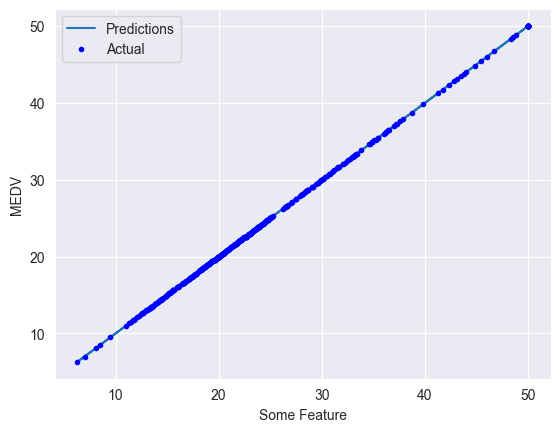

R2 error:  1.0


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_excel('DataSet.xlsx')
data = data.fillna(data.mean())

for i in range(1, 14):
    X = data.iloc[:, i:i+1]
    y = data['MEDV']
    alpha, beta = linear_regression(X.values.flatten(), y)
    y_predict = alpha * X.values.flatten() + beta
    plt.plot(X, y_predict, label="Predictions")
    plt.plot(X, y, "b.", label="Actual")
    plt.xlabel("Some Feature")
    plt.ylabel("MEDV")
    plt.legend()
    plt.show()
    
    R2_error = get_r2_score(y_predict, y)
    print("R2 error: ", R2_error)



# plut box plot for the data set for all of the features


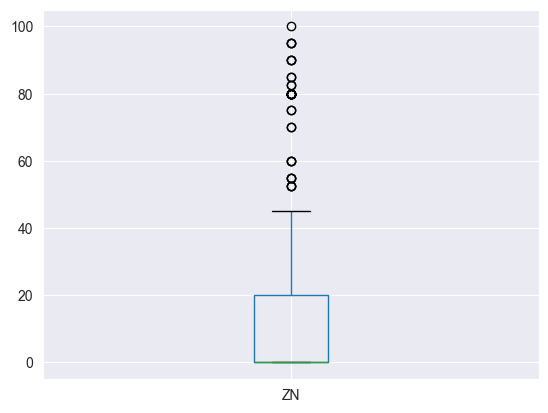

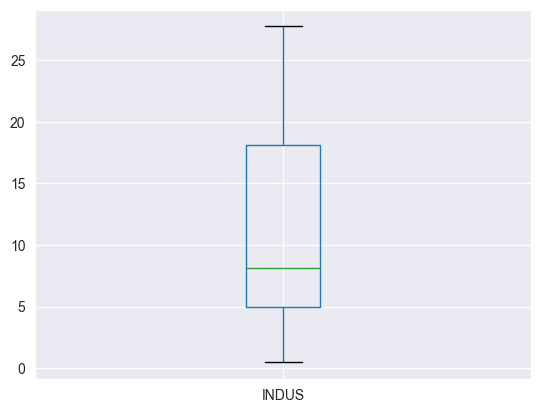

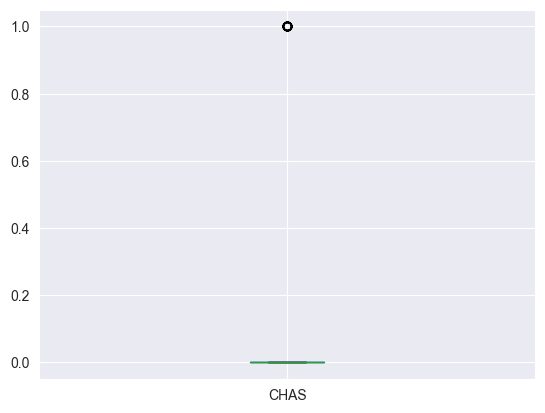

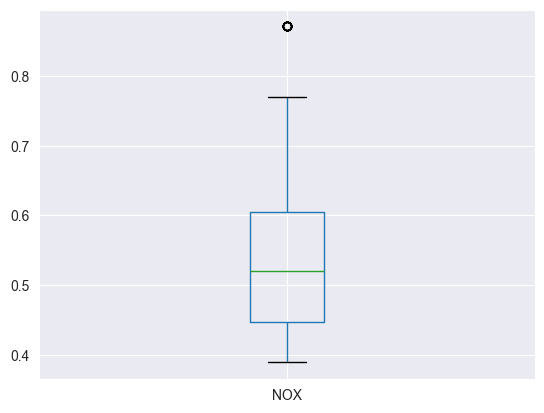

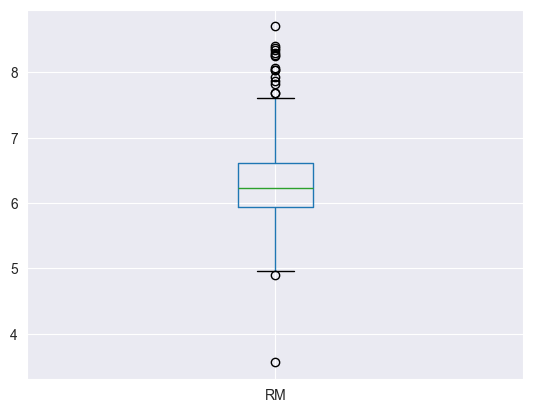

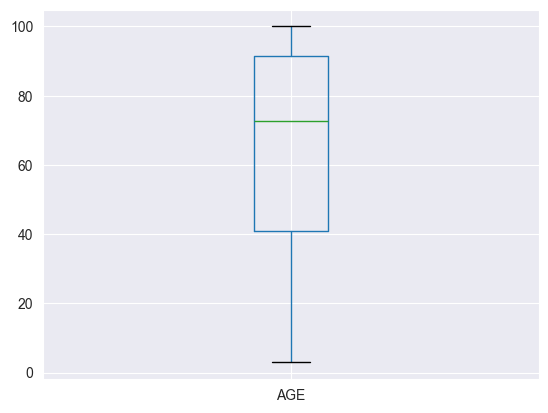

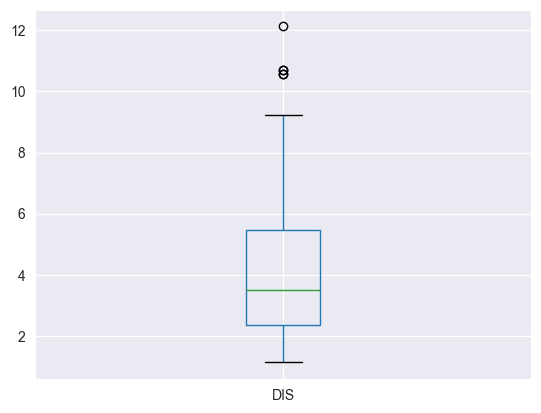

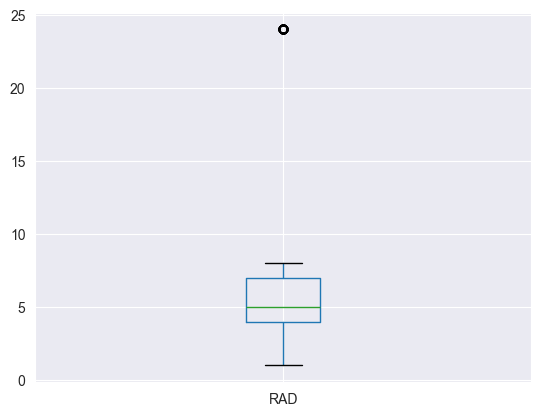

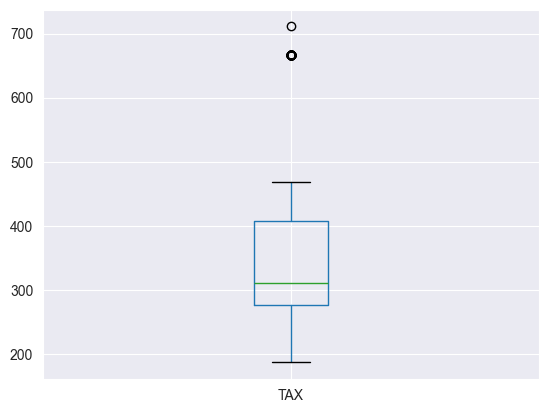

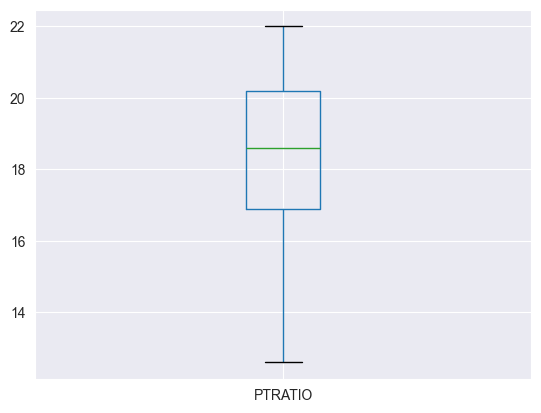

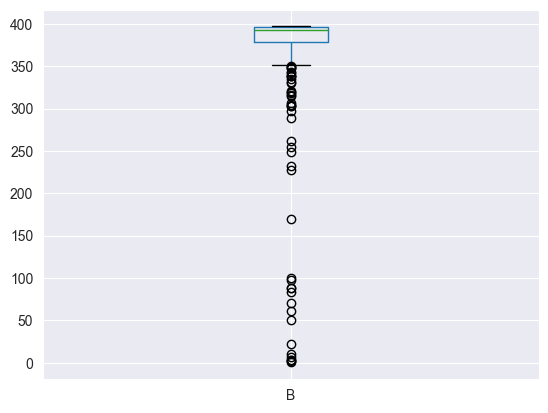

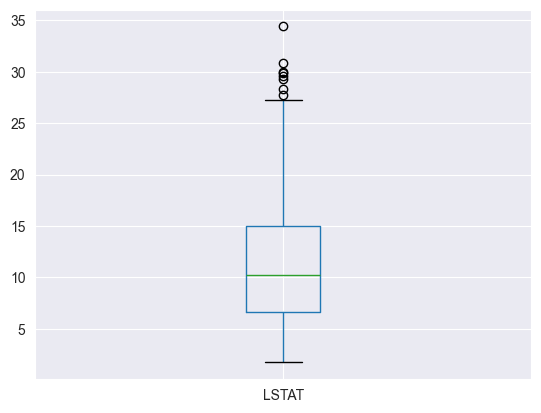

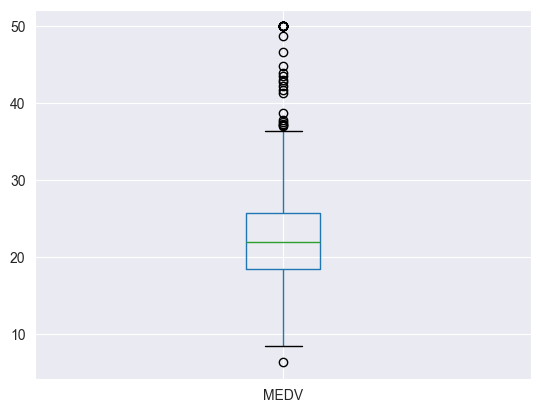

In [31]:
import pandas as pd

data = pd.read_excel('DataSet.xlsx')
data = data.dropna()

for i in range(1, 14):
    
    X = data.iloc[:, i:i+1]
    X.boxplot()
    plt.show()
    


# Polynomial Regression

To extend the simple linear regression to polynomial regression, we can model the relationship between the independent variable $x$ and the dependent variable $y$ as a polynomial function of degree $n$:

$$f(x) = \beta_0 + \beta_1x + \beta_2x^2 + \ldots + \beta_nx^n$$

The steps to find the parameters $\beta_i$ are similar to those in simple linear regression. We again minimize the RSS function by taking the derivatives with respect to each parameter and setting them to 0.

- Step 1: Compute the RSS function for polynomial regression:

$$ RSS = \Sigma (y_i - (\hat{\beta_0} + \hat{\beta_1}x_i + \hat{\beta_2}x_i^2 + \ldots + \hat{\beta_n}x_i^n))^2 $$

- Step 2: Compute the derivatives of the RSS function with respect to each parameter $\beta_i$ and set them to 0 to find the desired parameters.

$$ \frac{\partial RSS}{\partial \beta_i} = 0, \text{ for } i = 0, 1, 2, \ldots, n$$

Solving these equations will give us the optimal values of $\beta_i$ for the polynomial regression model. The specific form of the equations will depend on the degree of the polynomial and the number of parameters.

The general form for finding the coefficients for polynomial regression can be represented as:

$$ \beta = (X^T X)^{-1} X^T y $$

where:
- $X$ is the design matrix with columns $x^0, x^1, x^2, ..., x^n$
- $x^i$ represents the feature vector of $x$ raised to the power of $i$
- $y$ is the target variable vector
- $\beta$ is the coefficient vector for the polynomial regression

By solving for $\beta$ using the above formula, we can obtain the coefficients for the polynomial regression model.

In [32]:
def generate_polynomial_features(X, degree):
    n_samples = X.shape[0]
    X_poly = np.ones((n_samples, degree + 1))
    for d in range(1, degree + 1):
        X_poly[:, d] = X ** d
    return X_poly

def linear_regression(X, y):
    # Compute the pseudoinverse of X
    X_pseudo_inv = np.linalg.pinv(X)
    theta_best = X_pseudo_inv.dot(y)
    return theta_best

def polynomial_regression(X, y, degree):
    # Generate polynomial features
    X_poly = generate_polynomial_features(X, degree)
    
    # Perform linear regression using the pseudoinverse
    theta_best = linear_regression(X_poly, y)
    
    return theta_best

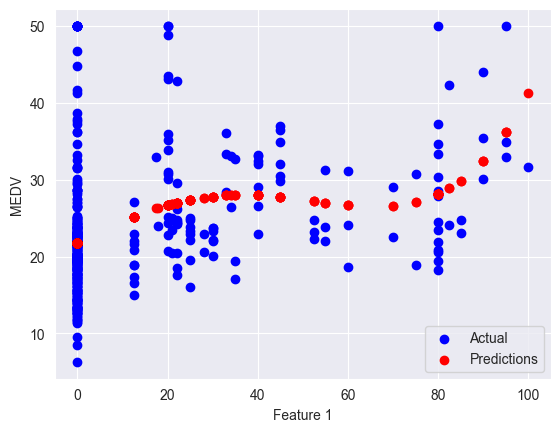

R2 error for feature 1: 0.1297088781647785


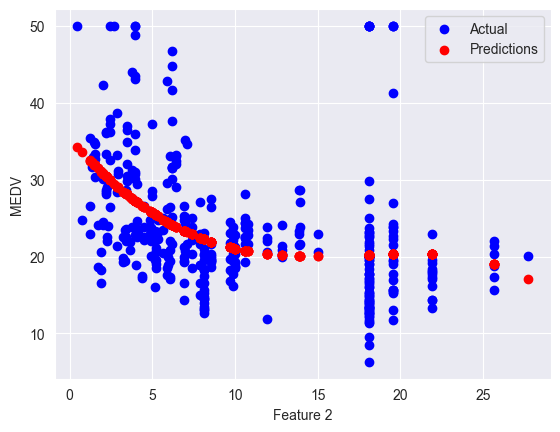

R2 error for feature 2: 0.19072462380360533


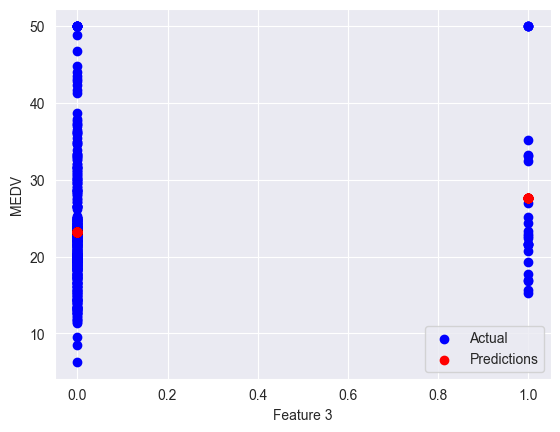

R2 error for feature 3: 0.014821532940105131


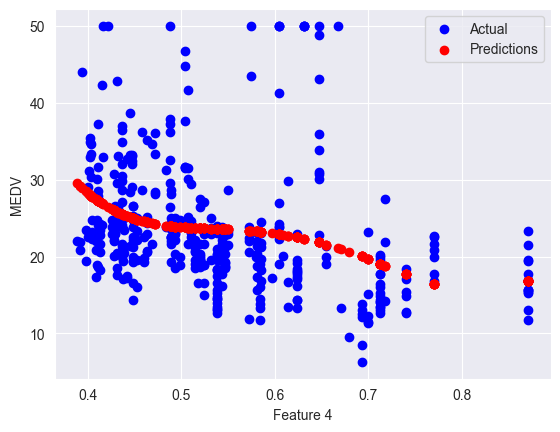

R2 error for feature 4: 0.10157919962670425


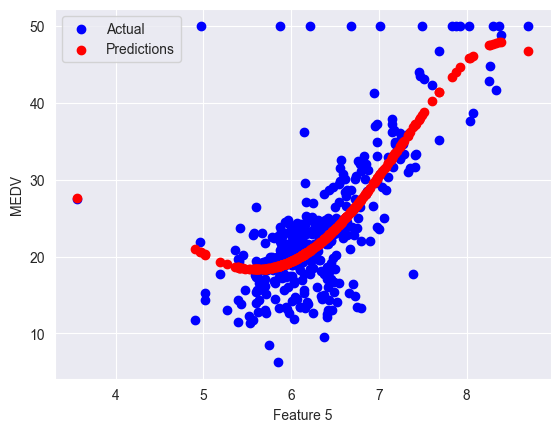

R2 error for feature 5: 0.5995660198443786


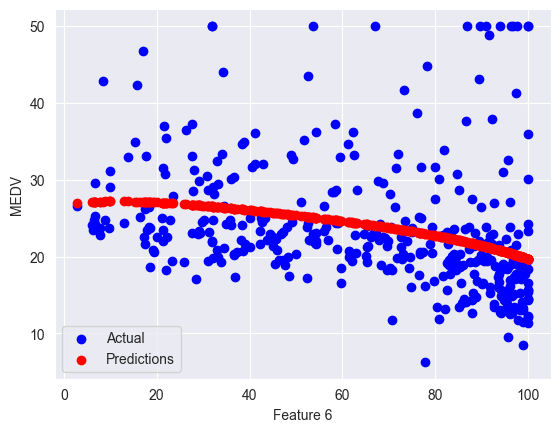

R2 error for feature 6: 0.08954835473849432


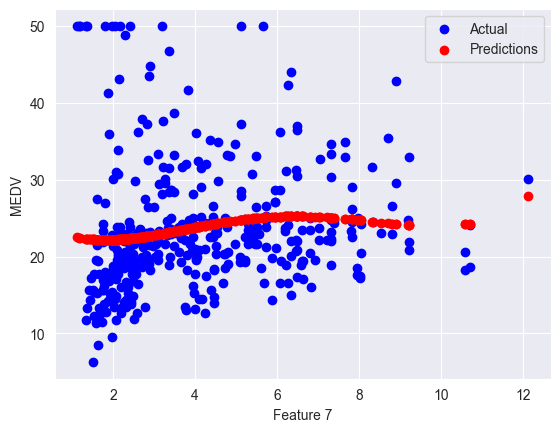

R2 error for feature 7: 0.01946677802083563


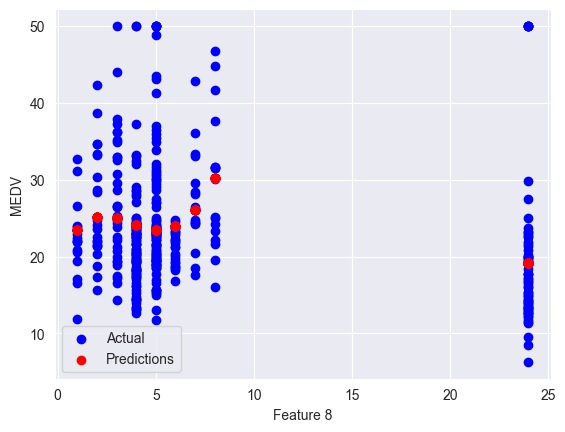

R2 error for feature 8: 0.08528311566216429


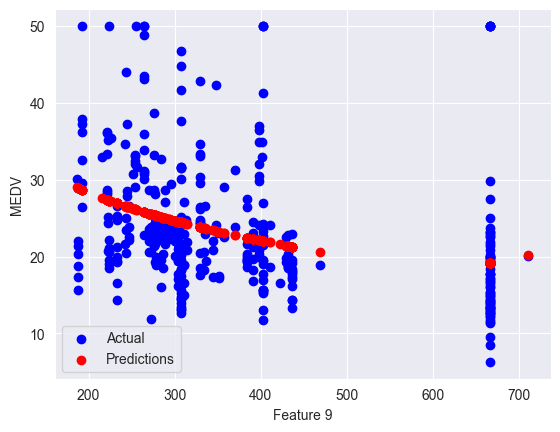

R2 error for feature 9: 0.10314667905134456


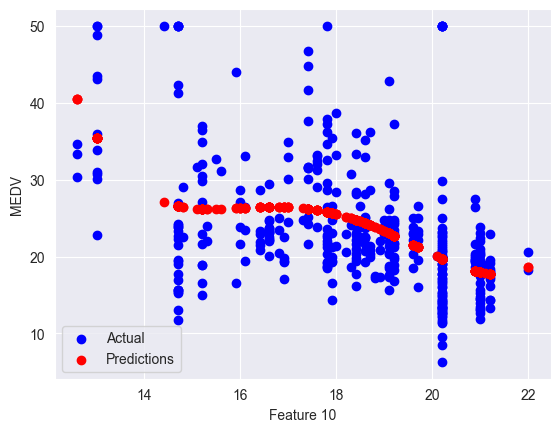

R2 error for feature 10: 0.23319774060682752


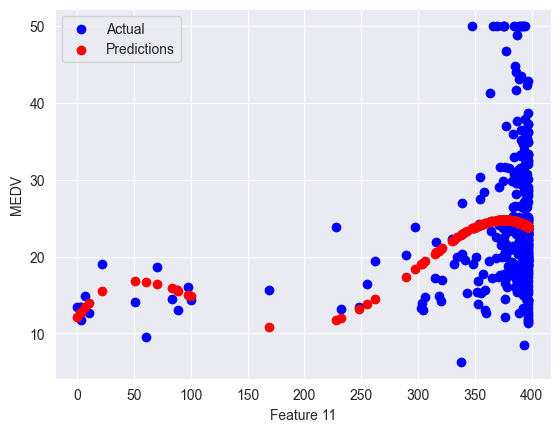

R2 error for feature 11: 0.08452517446158003


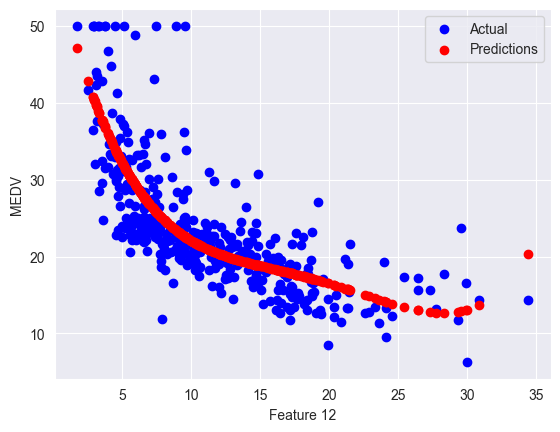

R2 error for feature 12: 0.6119861626337462


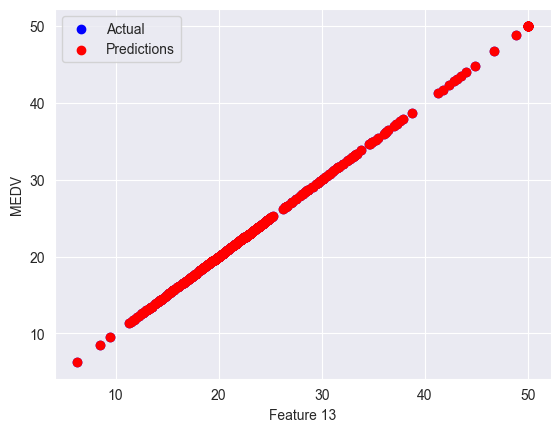

R2 error for feature 13: 1.0


In [33]:
import numpy as np

data = pd.read_excel('DataSet.xlsx')
data = data.dropna()

degree = 4

# Loop through features
for i in range(1, 14):
    X = data.iloc[:, i:i+1].values.flatten()
    y = data['MEDV'].values

    # Get polynomial regression coefficients
    theta_best = polynomial_regression(X, y, degree)

    # Generate predictions
    X_new = X.flatten()
    Y_new = np.zeros(X_new.shape[0])
    Y_new += theta_best[0]  # Adding the intercept (bias term)
    
    for j in range(1, degree + 1):
        Y_new += theta_best[j] * X_new ** j

    # Plot the results
    plt.scatter(X, y, color='blue', label='Actual')
    plt.scatter(X, Y_new, color='red', label='Predictions')
    plt.xlabel(f"Feature {i}")
    plt.ylabel("MEDV")
    plt.legend()
    plt.show()
    
    # Calculate and print R2 error
    R2_error = get_r2_score(Y_new, y)
    print(f"R2 error for feature {i}: {R2_error}")
    

## Computing the Derivative

As we saw, the cost function is the sum over the data points of the squared difference between an observed output and a predicted output.

Since the derivative of a sum is the sum of the derivatives, we can compute the derivative for a single data point and then sum over data points. We can write the squared difference between the observed output and predicted output for a single point as follows:

$$
(output  - (const* w _{0} + [feature_1] * w_{1} + ...+ [feature_n] * w_{n}  ))^2
$$

With n feautures and a const , So the derivative will be :


$$
2 * (output  - (const* w _{0} + [feature_1] * w_{1} + ...+ [feature_n] * w_{n}  ))
$$

The term inside the paranethesis is just the error (difference between prediction and output). So we can re-write this as:

$$2 * error*[feature_i] $$


That is, the derivative for the weight for feature i is the sum (over data points) of 2 times the product of the error and the feature itself. In the case of the constant then this is just twice the sum of the errors!

Recall that twice the sum of the product of two vectors is just twice the dot product of the two vectors. Therefore the derivative for the weight for feature_i is just two times the dot product between the values of feature_i and the current errors.


With this in mind, complete the following derivative function which computes the derivative of the weight given the value of the feature (over all data points) and the errors (over all data points).


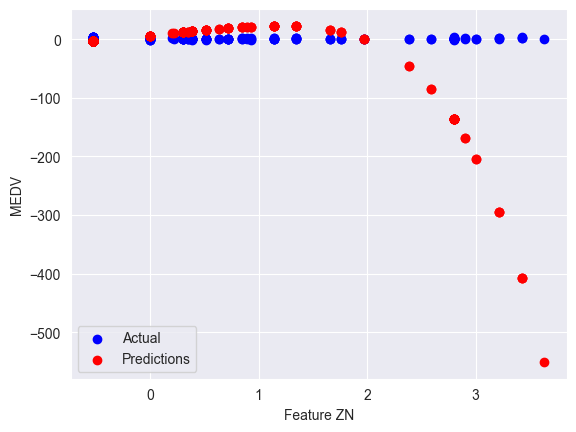

Feature ZN: R2 error: -3886.464600239642


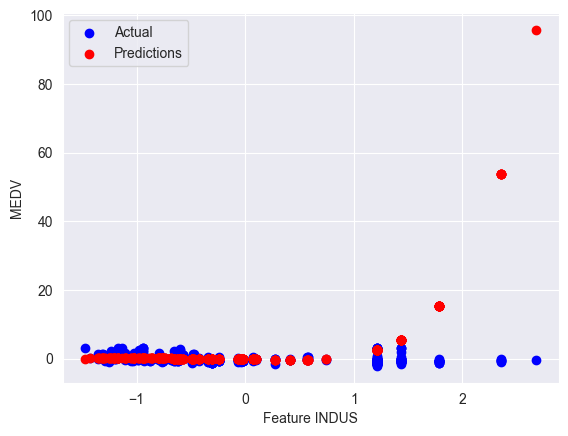

Feature INDUS: R2 error: -81.05470376726838


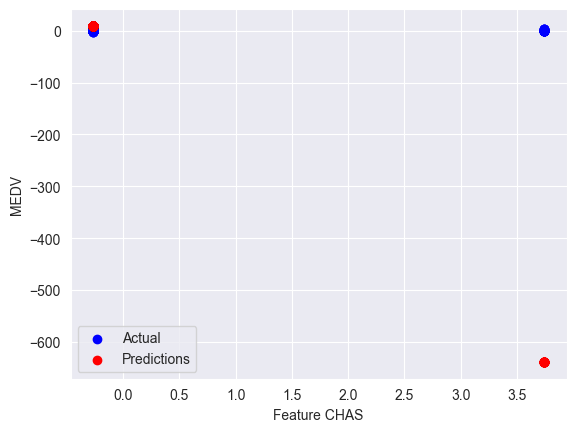

Feature CHAS: R2 error: -27298.909685848677


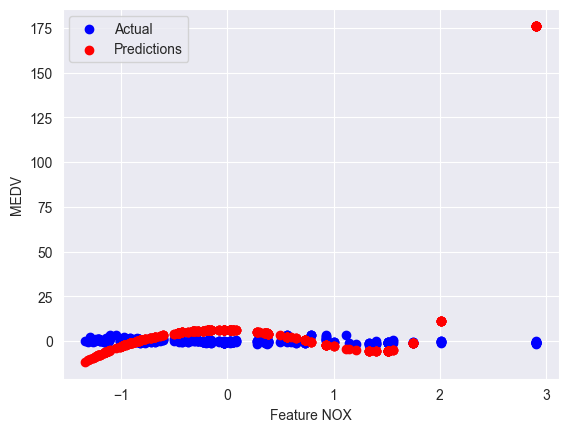

Feature NOX: R2 error: -1066.044510251631


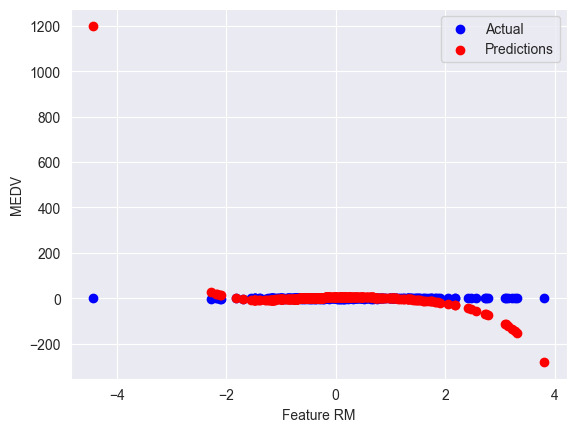

Feature RM: R2 error: -4262.693985365244


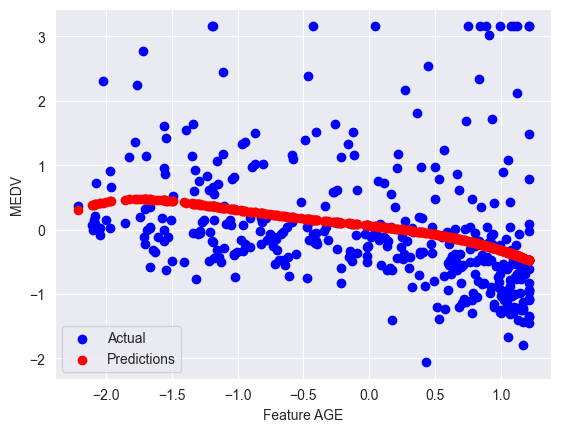

Feature AGE: R2 error: 0.08948006181613899


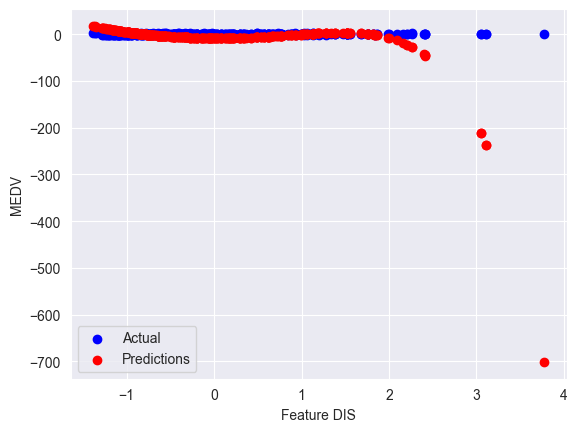

Feature DIS: R2 error: -1842.4919279779726


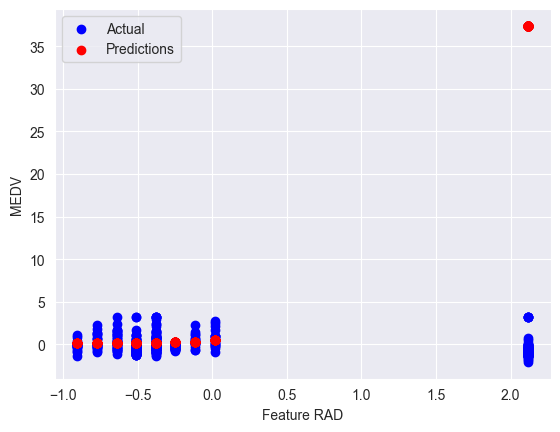

Feature RAD: R2 error: -254.16018239420413


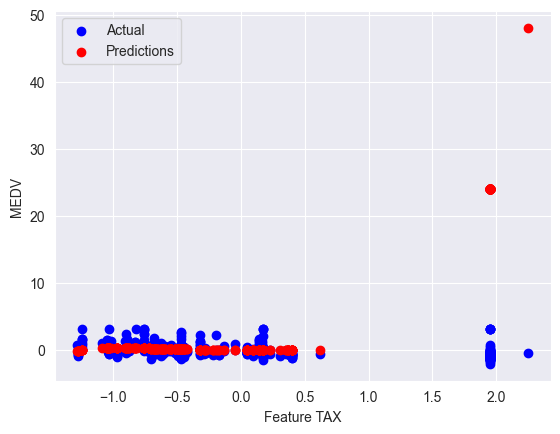

Feature TAX: R2 error: -111.85826733473696


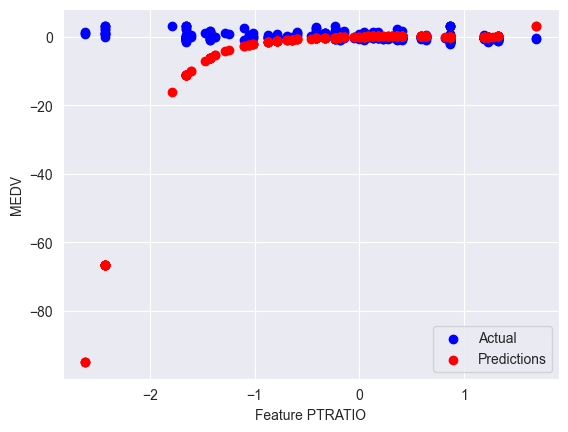

Feature PTRATIO: R2 error: -216.27138851632714


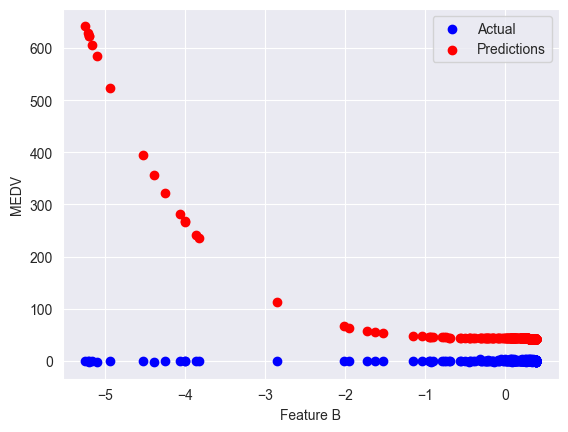

Feature B: R2 error: -10309.723949618647


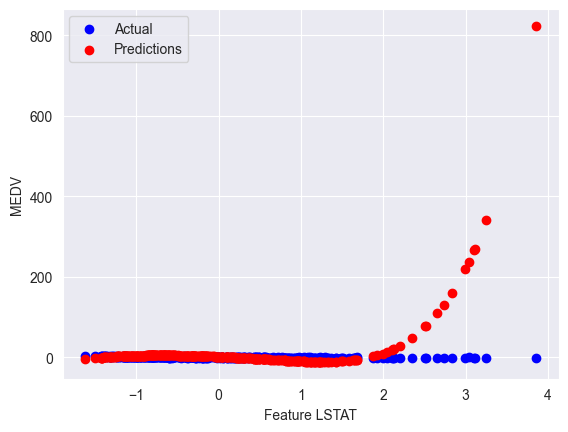

Feature LSTAT: R2 error: -2886.627547792396


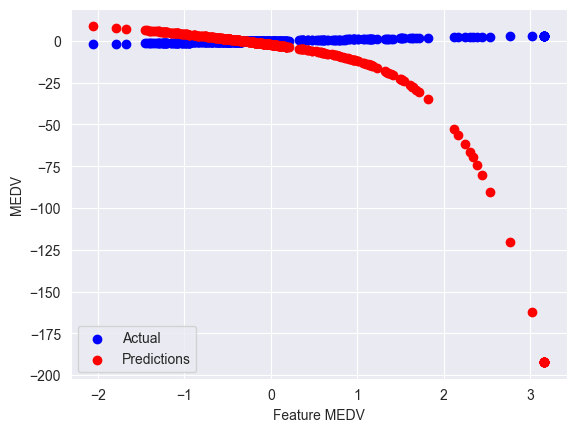

Feature MEDV: R2 error: -1541.0646255536394


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def polynomial_regression_gradient_descent(feature_matrix, outputs, initial_weights, bias, step_size, tolerance, max_iterations=1000):
    weights = np.array(initial_weights)
    iteration = 0
    while iteration < max_iterations:
        predictions = predict_output(feature_matrix, weights, bias)
        errors = predictions - outputs
        gradients = 2 * feature_matrix.T.dot(errors) / len(outputs)
        
        gradients = np.clip(gradients, -1e2, 1e2)
        
        weights -= step_size * gradients
        bias -= step_size * 2 * np.sum(errors) / len(outputs)
        
        gradient_magnitude = np.sqrt(np.sum(gradients ** 2))
        if gradient_magnitude < tolerance:
            break
        iteration += 1
    return weights, bias

def normalize_features(data_frame, chosen_features):
    for feature in chosen_features:
        data_frame[feature] = (data_frame[feature] - data_frame[feature].mean()) / data_frame[feature].std()
    return data_frame

def predict_output(feature_matrix, weights, bias):
    return feature_matrix.dot(weights) + bias

def generate_polynomial_features(X, degree):
    n_samples = X.shape[0]
    X_poly = np.ones((n_samples, degree + 1))
    for d in range(1, degree + 1):
        X_poly[:, d] = X ** d
    return X_poly

data = pd.read_excel('DataSet.xlsx')
data = data.dropna()
chosen_features = data.columns[1:14]
data = normalize_features(data, chosen_features)

degree = 5
step_size = 1e-2

tolerance = 1e-6

for feature in chosen_features:
    X = data[feature].values
    y = data['MEDV'].values
    X_poly = generate_polynomial_features(X, degree)
    
    initial_weights = np.zeros(X_poly.shape[1])
    bias = 0
    
    weights, bias = polynomial_regression_gradient_descent(X_poly, y, initial_weights, bias, step_size, tolerance)
    
    Y_new = predict_output(X_poly, weights, bias)
    
    # Plot the results
    plt.scatter(X, y, color='blue', label='Actual')
    plt.scatter(np.sort(X), Y_new[np.argsort(X)], color='red', label='Predictions')
    plt.xlabel(f"Feature {feature}")
    plt.ylabel("MEDV")
    plt.legend()
    plt.show()
    
    # Calculate and print R2 error
    R2_error = 1 - np.sum((y - Y_new) ** 2) / np.sum((y - np.mean(y)) ** 2)
    print(f"Feature {feature}: R2 error: {R2_error}")


# Implementing Polynomial Regression vs Degree

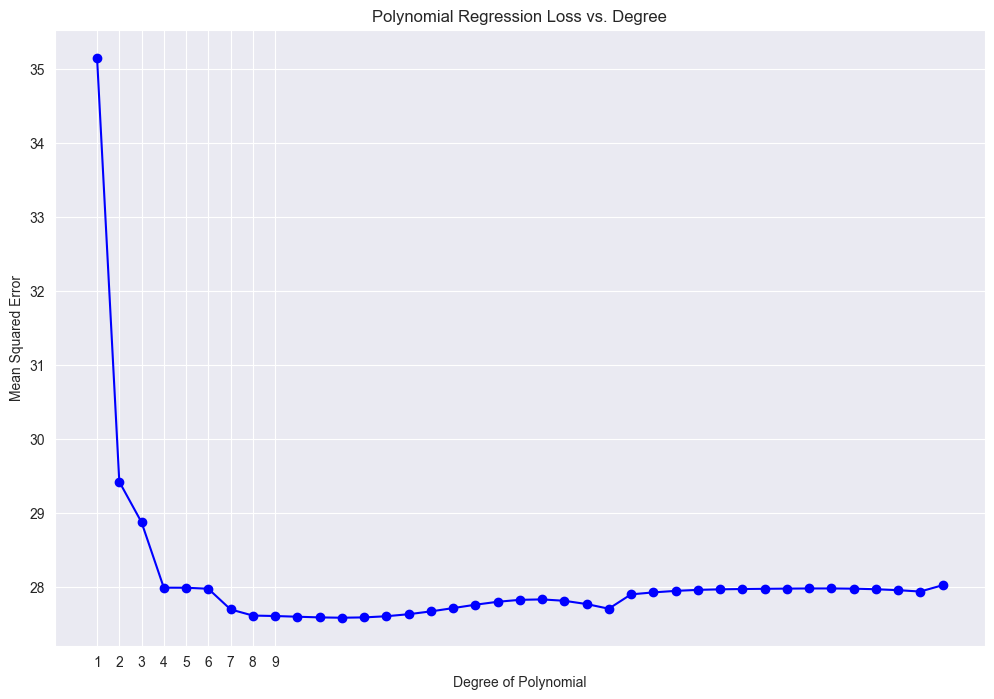

Mean Squared Error: 27.610016969679354


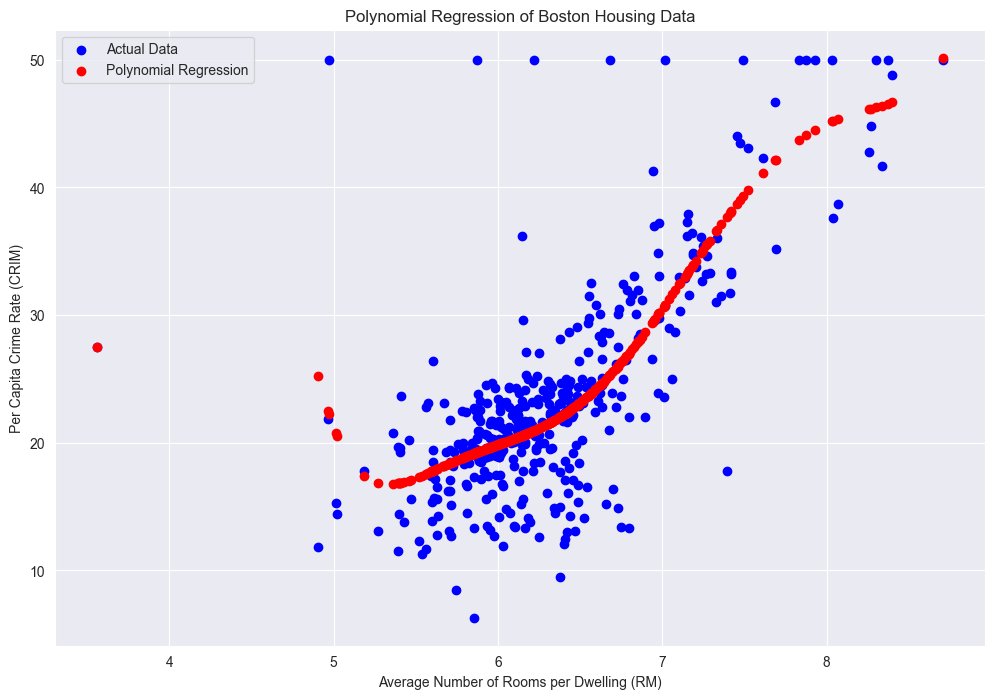

In [35]:
import pandas as pd

data = pd.read_excel('DataSet.xlsx')

data = data.dropna()


X = data[['RM']]
y = data['MEDV']

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


losses = []

for degree in range(1, 40):
    poly_features = PolynomialFeatures(degree=degree)
    X_poly = poly_features.fit_transform(X)
    
    model = LinearRegression()
    model.fit(X_poly, y)
    
    y_pred = model.predict(X_poly)
    
    mse = mean_squared_error(y, y_pred)
    losses.append(mse)
    
plt.figure(figsize=(12, 8))
plt.plot(range(1, 40), losses, marker='o', color='blue')
plt.title('Polynomial Regression Loss vs. Degree')
plt.xlabel('Degree of Polynomial')
plt.ylabel('Mean Squared Error')
plt.xticks(range(1, 10))
plt.grid(True)
plt.show()


degree = 9

poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)
    
model = LinearRegression()
model.fit(X_poly, y)

y_pred = model.predict(X_poly)

mse = mean_squared_error(y, y_pred)
print(f'Mean Squared Error: {mse}')


plt.figure(figsize=(12, 8))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.scatter(X, y_pred, color='red', label='Polynomial Regression')
plt.title('Polynomial Regression of Boston Housing Data')
plt.xlabel('Average Number of Rooms per Dwelling (RM)')
plt.ylabel('Per Capita Crime Rate (CRIM)')
plt.legend()
plt.show()



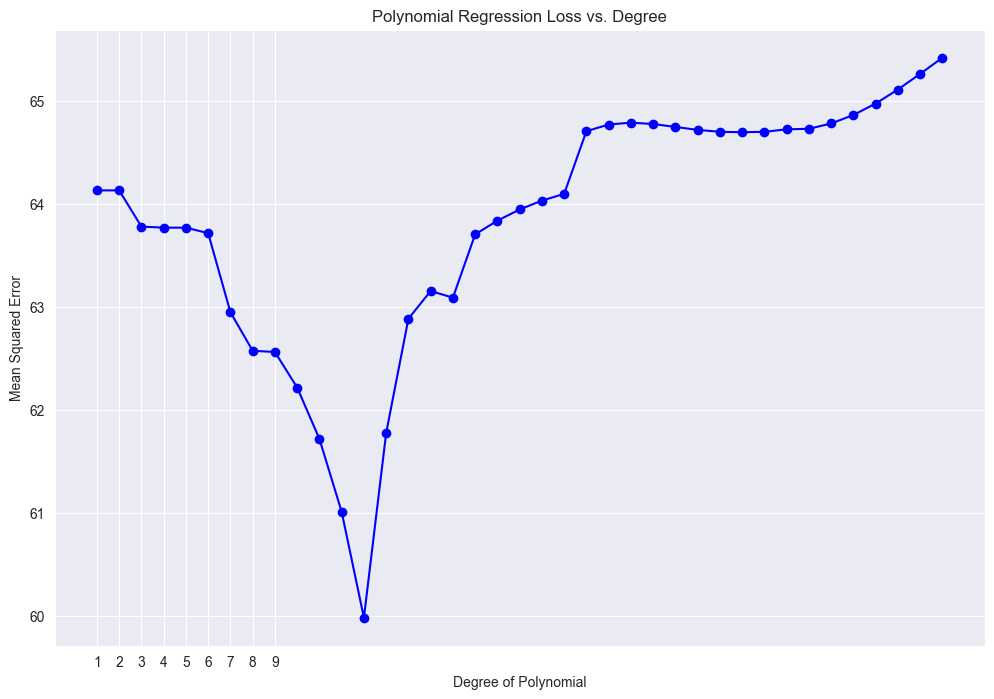

Mean Squared Error: 62.5627950007778


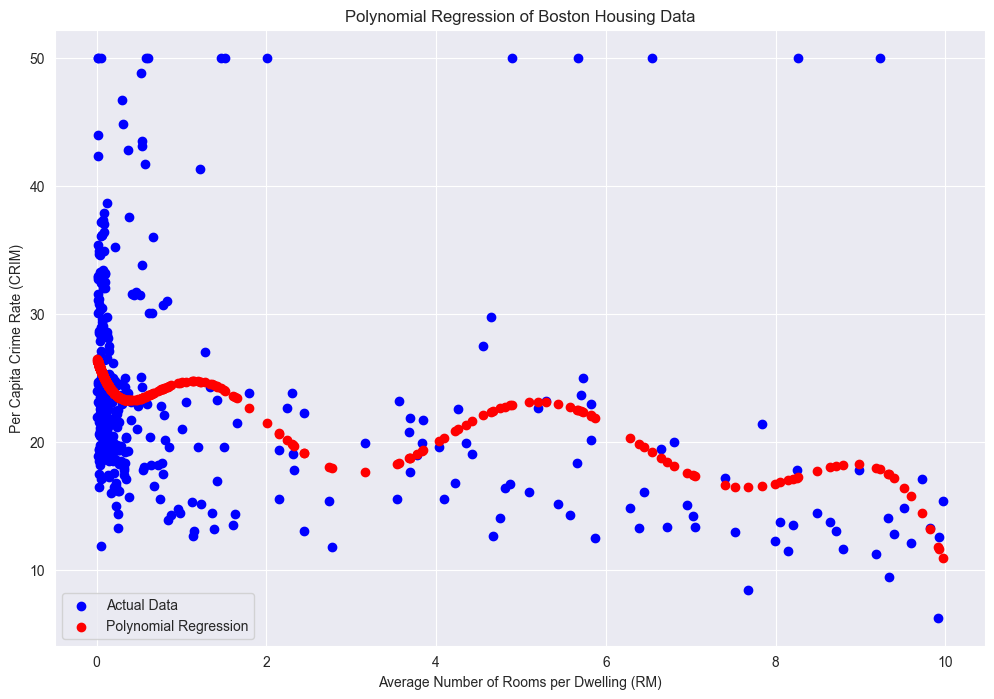

In [36]:
import numpy as np
import pandas as pd

data = pd.read_excel('DataSet.xlsx')

data = data.dropna()

X = data[['CRIM']]
y = data['MEDV']

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


losses = []

for degree in range(1, 40):
    poly_features = PolynomialFeatures(degree=degree)
    X_poly = poly_features.fit_transform(X)
    
    model = LinearRegression()
    model.fit(X_poly, y)
    
    y_pred = model.predict(X_poly)
    
    mse = mean_squared_error(y, y_pred)
    losses.append(mse)
    
plt.figure(figsize=(12, 8))
plt.plot(range(1, 40), losses, marker='o', color='blue')
plt.title('Polynomial Regression Loss vs. Degree')
plt.xlabel('Degree of Polynomial')
plt.ylabel('Mean Squared Error')
plt.xticks(range(1, 10))
plt.grid(True)
plt.show()


degree = 9

poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)
    
model = LinearRegression()
model.fit(X_poly, y)

y_pred = model.predict(X_poly)

mse = mean_squared_error(y, y_pred)
print(f'Mean Squared Error: {mse}')


plt.figure(figsize=(12, 8))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.scatter(X, y_pred, color='red', label='Polynomial Regression')
plt.title('Polynomial Regression of Boston Housing Data')
plt.xlabel('Average Number of Rooms per Dwelling (RM)')
plt.ylabel('Per Capita Crime Rate (CRIM)')
plt.legend()
plt.show()



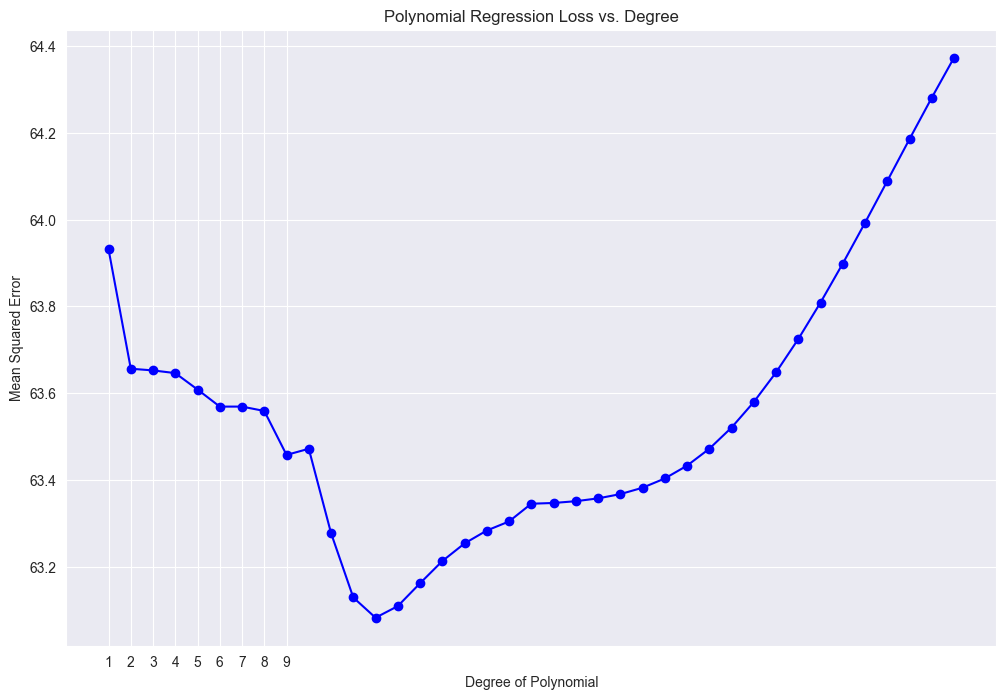

Mean Squared Error: 63.45741735617595


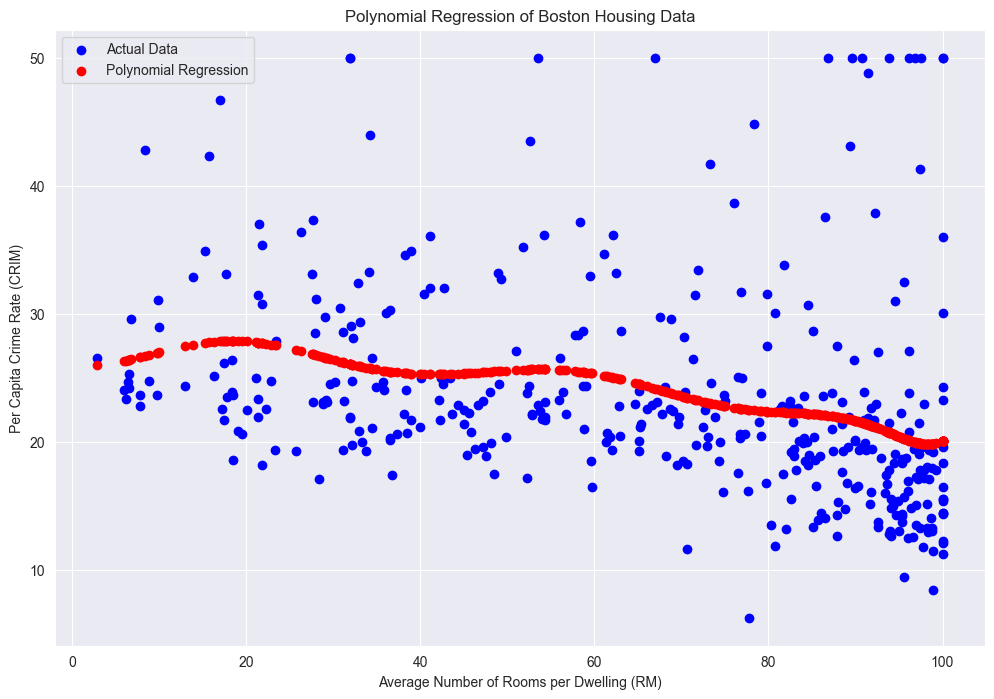

In [37]:
import pandas as pd

data = pd.read_excel('DataSet.xlsx')

data = data.dropna()


X = data[['AGE']]
y = data['MEDV']

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


losses = []

for degree in range(1, 40):
    poly_features = PolynomialFeatures(degree=degree)
    X_poly = poly_features.fit_transform(X)
    
    model = LinearRegression()
    model.fit(X_poly, y)
    
    y_pred = model.predict(X_poly)
    
    mse = mean_squared_error(y, y_pred)
    losses.append(mse)
    
plt.figure(figsize=(12, 8))
plt.plot(range(1, 40), losses, marker='o', color='blue')
plt.title('Polynomial Regression Loss vs. Degree')
plt.xlabel('Degree of Polynomial')
plt.ylabel('Mean Squared Error')
plt.xticks(range(1, 10))
plt.grid(True)
plt.show()


degree = 9

poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)
    
model = LinearRegression()
model.fit(X_poly, y)

y_pred = model.predict(X_poly)

mse = mean_squared_error(y, y_pred)
print(f'Mean Squared Error: {mse}')


plt.figure(figsize=(12, 8))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.scatter(X, y_pred, color='red', label='Polynomial Regression')
plt.title('Polynomial Regression of Boston Housing Data')
plt.xlabel('Average Number of Rooms per Dwelling (RM)')
plt.ylabel('Per Capita Crime Rate (CRIM)')
plt.legend()
plt.show()



# Phase tree:  Classification
in this part we want to use Decision Trees and K-Nearest Neighbors (KNN) to classify the data.


#### Decision Trees:
- **Overview**: Decision Trees are predictive modeling approaches that use a tree-like model of decisions. Data is split at each node based on a feature and a threshold, aiming to segregate the data efficiently.
- **Process**: Starts from a root node and splits down into various branches based on feature values, forming a tree structure that captures important attributes of the dataset.
- **Goal**: Utilize the tree to make predictions on new data, with the structure offering a clear and understandable path from features to outcome.
- **Advantages of Decision Trees**:
  - Interpretability: Easy to understand and visualize the decision-making process.
  - Non-parametric: No assumptions about data distribution, which makes it robust to outliers and skewed data.

#### K-Nearest Neighbors (KNN):
- **Overview**: A simple, instance-based learning algorithm used for both classification and regression. Decisions are made based on the majority vote of the nearest neighbors of a given sample.
- **Process**: Computes the distance between the new instance and all instances in the dataset, identifying the nearest neighbors to determine the predominant class among those neighbors.
- **Parameter Tuning**: Involves setting the 'K' value, which is critical as it defines the number of neighbors that contribute to the decision.

#### Specific Topics Covered:
1. **Pruning in Decision Trees**:
   - **Concept**: Reducing the size of a decision tree by removing parts of the tree that do not provide power to classify instances.
   - **Benefits**: Helps in reducing the complexity and overfitting.
   - **Drawbacks**: Might lead to underfitting if too much pruning is done.

2. **Optimal Use Cases for Decision Trees**: Best used when clear human-understandable rules are needed from data and when handling high-dimensional data.

3. **Intrinsic Differences Between KNN and Other Classification Methods** (like neural networks or logistic regression):
   - **Training Process**: KNN is a lazy learner – it doesn't learn a discriminative function from the training data but memorizes the dataset instead.

4. **One Nearest Neighbor Algorithm**:
   - **Pros and Cons**: Discusses simplicity versus susceptibility to noise.

5. **Distance Metrics in KNN**: Explores various ways to measure distance (Euclidean, Manhattan, etc.) to improve the performance of KNN based on the data characteristics.

6. **Project Implementation**:
   - **Task**: Classify housing data into categories (luxury, economical, standard) using Decision Trees and KNN modeled with scikit-learn.
   - **Model Optimization**: Tune hyperparameters to minimize cost functions without causing overfitting.
   - **Evaluation**: Compare models optimized via trial and error with those tuned using GridSearchCV.

7. **Model Visualization and Analysis**:
   - **Plotting Decision Trees**: Use `plot_tree` from scikit-learn.
   - **Detection of Overfitting/Underfitting**: Discuss when and why these issues occur in models.

This structured format organizes the complex topics into digestible parts, making it easier to address each component methodically in your notebook.


### 21. What is the concept of pruning in decision trees? List the advantages and disadvantages of using this method.
**Pruning** is the process of removing parts of a decision tree that do not provide additional power or significance in classifying instances. This is done to reduce the complexity of the model and to prevent overfitting.

**Advantages:**
- **Reduces Overfitting:** Pruning helps in reducing the overfitting by removing sections of the tree that might be too specific to the training data.
- **Simplifies the Model:** It makes the tree simpler and more interpretable.
- **Improves Generalization:** It can improve the performance of the model on unseen data.

**Disadvantages:**
- **Risk of Underfitting:** If pruning is too aggressive, it can remove important structures, leading to underfitting.
- **Complexity in Choosing Parameters:** Deciding how much to prune can be complex and might require cross-validation.

### 22. When can the use of decision trees have an advantage over other models?
Decision trees can be advantageous in the following scenarios:
- **Interpretability:** When you need a model that is easy to interpret and explain.
- **Non-linear Relationships:** When the relationship between features and the target variable is non-linear.
- **Feature Importance:** When you want to identify the most important features in your dataset.
- **Handling Categorical Data:** Decision trees handle categorical data naturally without the need for one-hot encoding.

### 23. What is the inherent difference between the KNN classifier and other classifiers like neural networks or logistic regression?
The inherent differences lie in the training process and decision-making approach:

- **KNN:**
  - **Instance-based Learning:** KNN is a lazy learning algorithm, meaning it does not learn a model during the training phase. Instead, it stores the training data and makes decisions during the prediction phase based on the stored data.
  - **Distance-based Decision:** Classification is done based on the majority class among the nearest neighbors.

- **Neural Networks and Logistic Regression:**
  - **Model-based Learning:** These are eager learning algorithms that learn a model during the training phase by optimizing a cost function.
  - **Training Phase:** They involve a significant training phase where the model parameters are learned using gradient descent and other optimization techniques.

### 24. Research the one nearest neighbor algorithm and list its advantages and disadvantages.
**One Nearest Neighbor (1-NN)** is a special case of the KNN algorithm where \(K = 1\). It classifies a sample based on the single closest training example.

**Advantages:**
- **Simplicity:** Very simple to implement.
- **No Hyperparameter Tuning:** Does not require tuning the \(K\) parameter.
- **Fast Training:** No training phase, so it’s very fast in terms of training.

**Disadvantages:**
- **Sensitive to Noise:** Very sensitive to noisy data and outliers, as the classification depends on a single data point.
- **Computationally Intensive Prediction:** Requires computing the distance to all training samples, which can be slow for large datasets.
- **Poor Generalization:** Can lead to poor generalization as it relies heavily on the nearest neighbor.

### 25. Research other distance metrics used in the KNN algorithm and list a few.
Several distance metrics can be used in KNN apart from the common Euclidean distance:

- **Manhattan Distance:** $$ \sum |x_i - y_i| $$
- **Minkowski Distance:** Generalized distance metric, $$ \left( \sum |x_i - y_i|^p \right)^{1/p} $$
- **Cosine Similarity:** Measures the cosine of the angle between two vectors, useful for high-dimensional data.
- **Hamming Distance:** Used for categorical data, counts the number of positions at which the corresponding elements are different.


### 26. Implement a project to classify housing data into categories using Decision Trees and KNN.
its already implemented in the next cell.

### 27. Explain GridSearchCV and its performance.
**GridSearchCV** is a method for hyperparameter tuning that performs an exhaustive search over a specified parameter grid. It uses cross-validation to evaluate the performance of each combination of parameters, providing the best set of parameters based on the evaluation metric.

**Performance:**
- **Optimizes Parameters:** Helps in finding the most suitable hyperparameters, improving the model’s performance.
- **Cross-validation:** Ensures the model is validated on multiple folds of the dataset, reducing overfitting.

### 28. Plot the final decision tree.
The code provided in the previous section includes how to plot the final decision tree using `plot_tree`.

### 29. Underfitting vs. Overfitting:
**Underfitting:** Occurs when the model is too simple to capture the underlying pattern of the data, resulting in poor performance on both the training and test sets.
- **Symptoms:** High bias, low variance, poor training accuracy.
- **Solution:** Increase model complexity by adding more features, using a more complex model, or reducing regularization.

**Overfitting:** Occurs when the model is too complex and captures the noise in the training data, resulting in poor generalization to new data.
- **Symptoms:** Low bias, high variance, high training accuracy but poor test accuracy.
- **Solution:** Reduce model complexity, use regularization techniques, or increase training data.

The intrinsic difference between the K-Nearest Neighbors (KNN) classifier and other classification methods like neural networks or logistic regression lies primarily in their training processes and underlying concepts:

1. **K-Nearest Neighbors (KNN)**:
   - **Training**: KNN is a lazy learning algorithm, meaning it does not actually learn a model using the training data. Instead, it memorizes the dataset and uses this memory during the inference stage to classify new instances. The "training" phase is essentially just storing the data.
   - **Decision Process**: Classification is performed by a majority vote of the nearest neighbors of a given test sample, based on distance metrics like Euclidean or Manhattan distance.

2. **Neural Networks**:
   - **Training**: Neural networks learn by adjusting weights and biases through a process called backpropagation, based on the errors between predicted outputs and actual labels in the training data. This involves iteratively minimizing a loss function using optimization techniques such as gradient descent.
   - **Decision Process**: Inferences are made by propagating input data through layers of neurons (using learned weights) and applying activation functions to ultimately make predictions.

3. **Logistic Regression**:
   - **Training**: Logistic regression model learns by estimating coefficients through a process such as maximum likelihood estimation. This often involves optimizing a cost function (like the log-loss) using an optimization algorithm (e.g., gradient descent).
   - **Decision Process**: It makes predictions by applying a logistic function to linear combinations of features, which transforms the output into a probability of belonging to a particular class.

The key distinction is that while KNN uses a non-parametric and instance-based approach requiring no explicit learning phase, both neural networks and logistic regression involve a parametric model where learning from the training data adjusts the parameters which are then used for prediction. This makes KNN very straightforward but potentially inefficient at scale, whereas neural networks and logistic regression are more computationally intensive during training but can be more efficient at making predictions once trained.

### 24. Research the one nearest neighbor algorithm and list its advantages and disadvantages.

The One Nearest Neighbor algorithm is a simplified version of the K-Nearest Neighbors (KNN) approach, where the classification or regression decision is based on the single closest data point in the training set to the new sample being evaluated. Here are the advantages and disadvantages of using the One Nearest Neighbor algorithm:

### Advantages:
1. **Simplicity**: The algorithm is extremely simple and easy to implement, as it only involves finding the closest training sample to the new data point.
2. **No Training Phase**: Like KNN, there is no explicit training phase. The model simply stores the training data and uses it directly during prediction.
3. **Flexibility**: It can be used for both classification and regression tasks by simply adopting the output of the nearest neighbor.

### Disadvantages:
1. **High Sensitivity to Noise**: Since the prediction is based solely on the nearest training example, the algorithm is highly sensitive to noisy data or outliers.
2. **No Generalization**: The algorithm does not form a generalized understanding from the training data, as it relies entirely on the existing examples. This can result in poor performance on unseen data, especially if the training data is not representative of the broader data space.
3. **Computational Cost**: For large datasets, the computation of the nearest neighbor can be computationally expensive, particularly since it requires calculating the distance to every single point in the dataset for each prediction.
4. **Overfitting**: The One Nearest Neighbor algorithm can easily overfit, especially in cases where the dataset is sparse, with large gaps between points, leading to predictions that are overly reliant on individual data points that may not represent the overall trend.

Overall, while the One Nearest Neighbor algorithm offers simplicity and direct application of training data, its practical use is limited by its sensitivity to noise and lack of robustness compared to more sophisticated methods that use multiple neighbors or incorporate ways to learn generalized patterns from the data.

5. what is distance metrics in KNN?

In the K-Nearest Neighbors (KNN) algorithm, the choice of distance metric can significantly impact the performance of the model, particularly in how well it classifies new data points. Here are several common distance metrics used in KNN:

### 1. Euclidean Distance
- **Description**: The most common distance metric used, defined as the square root of the sum of the squared differences between corresponding elements of two vectors.
- **Formula**: $$  \( \sqrt{\sum_{i=1}^n (x_i - y_i)^2} \) $$
- **Usage**: Ideal for real-valued and continuous data, and when the effect of each dimension is uniform.

### 2. Manhattan Distance (Taxicab or L1 norm)
- **Description**: Computes the sum of the absolute differences of their Cartesian coordinates. It is also known as L1 distance.
- **Formula**: $$  \( \sum_{i=1}^n |x_i - y_i| \) $$ 
- **Usage**: Useful in high-dimensional data spaces and for data with underlying non-Euclidean geometry, as it is less influenced by outliers compared to Euclidean distance.

### 3. Chebyshev Distance (Maximum norm metric)
- **Description**: The maximum absolute difference between two vectors along any coordinate dimension.
- **Formula**: $$  \( \max_{i} |x_i - y_i| \) $$ 
- **Usage**: Useful when you want to define distance based on the maximum difference along any dimension, as it allows for moves in a grid-based game scenario (like chess).

### 4. Minkowski Distance
- **Description**: A generalization of both the Euclidean and Manhattan distance. It includes a parameter \( p \) that allows different metrics to be derived based on its value.
- **Formula**:  $$ \( (\sum_{i=1}^n |x_i - y_i|^p)^{1/p} \) $$
- **Usage**: By varying \( p \), it can behave like both the Euclidean distance (\( p=2 \)) and the Manhattan distance (\( p=1 \)). Suitable for various applications depending on the nature of the data.

### 5. Hamming Distance
- **Description**: Measures the number of positions at which the corresponding symbols are different. Typically used for categorical or binary data.
- **Formula**: Count of differing bits.
- **Usage**: Particularly useful in scenarios where the classification is based on how many elements differ between two samples, such as error correction or genetic similarity.

### 6. Cosine Similarity
- **Not technically a distance metric but often used in KNN for text classification**: Measures cosine of the angle between two vectors, which effectively assesses the orientation rather than the magnitude.
- **Formula**: \( \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|} \)
- **Usage**: Highly effective in text analysis and other areas where the magnitude of the attribute vectors does not matter.

Each of these distance metrics has its applications and can be chosen based on the specific requirements and characteristics of the data set. In practice, the choice of distance metric can be as critical as the choice of parameter \( K \) in the KNN algorithm, and experimenting with different distance metrics can lead to significantly different performance outcomes.

### Question   26. Implement a project to classify housing data into categories using Decision Trees and KNN.

# Implementation of Decision Trees and K-Nearest Neighbors (KNN) for Classification

we want to classify the housing data into 3 categories (luxury, economical, standard) by MEDV using Decision Trees and KNN and KNN modeled with scikit-learn.
we can use 


we split the MEDV into 3 categories: 
- **Economical**: Below the 20th percentile
- **Standard**: Between the 20th and 80th percentile
- **Luxury**: Above the 80th percentile

now we want to have a model that can predict the category of a house based on its features.

our features are:
- CRIM: Per capita crime rate by town
- ZN: Proportion of residential land zoned for lots over 25,000 sq. ft.
- INDUS: Proportion of non-retail business acres per town
- CHAS: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
- NOX: Nitric oxides concentration (parts per 10 million)
- RM: Average number of rooms per dwelling
- AGE: Proportion of owner-occupied units built prior to 1940
- DIS: Weighted distances to five Boston employment centers
- RAD: Index of accessibility to radial highways
-  TAX: Full-value property tax rate per $10,000
- PTRATIO: Pupil-teacher ratio by town
- B: 1000(Bk - 0.63)^2 where Bk is the proportion of Black residents by town
- LSTAT: Percentage of lower status of the population


now for all of them we want to classify the data into 3 categories (luxury, economical, standard) using Decision Trees and KNN.

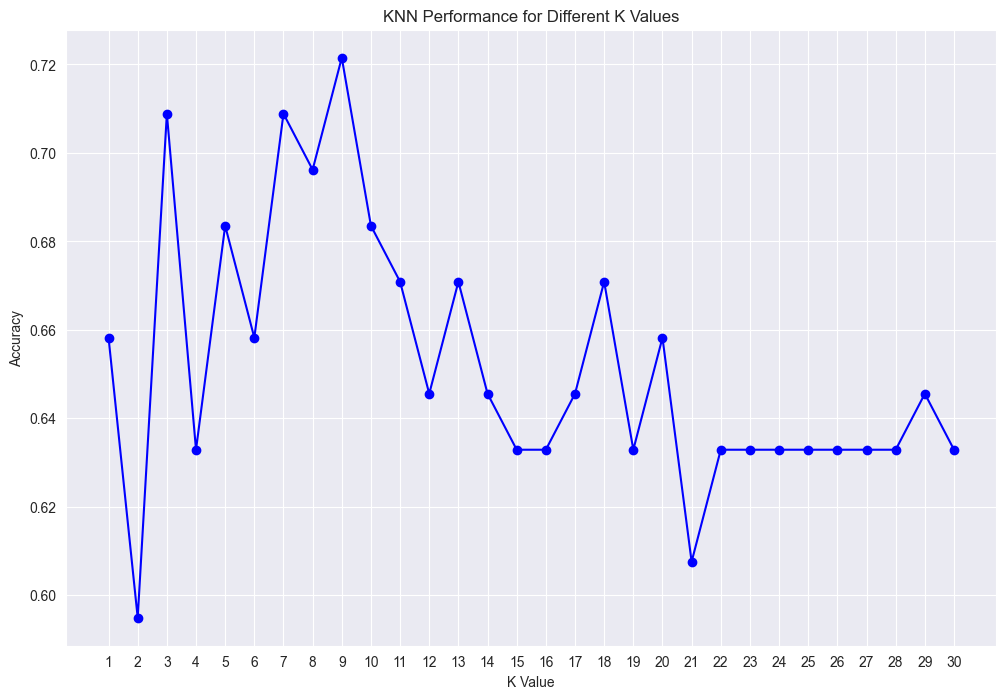

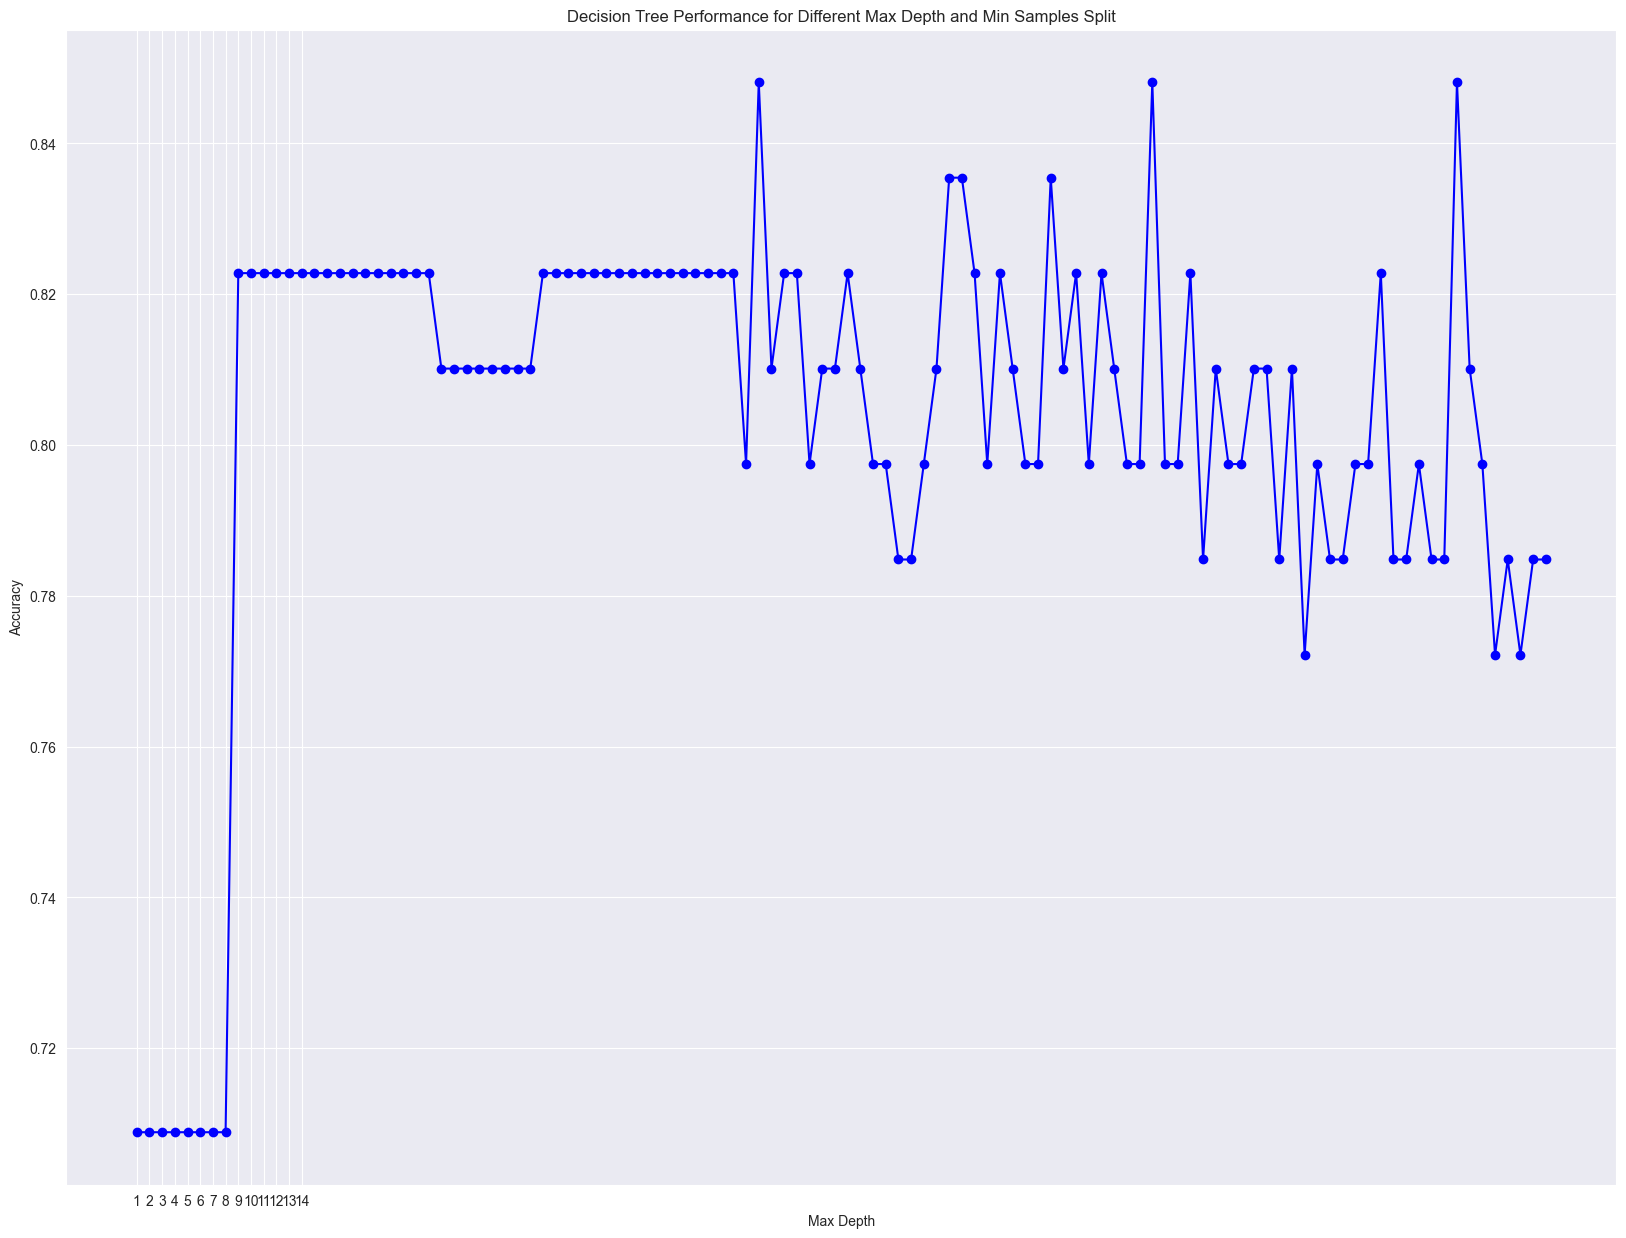

In [38]:
import pandas as pd

data = pd.read_excel('DataSet.xlsx')
data = data.dropna()



# defining tresholds for the categories
luxury_threshold = data['MEDV'].quantile(0.8)
economical_threshold = data['MEDV'].quantile(0.2)


data['Category'] = pd.cut(data['MEDV'],
                          bins=[data['MEDV'].min(), economical_threshold, luxury_threshold, data['MEDV'].max()],
                          labels=['Economical', 'Standard', 'Luxury'],
                          include_lowest=True)




from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier



# plt the knn and score of it for k = 1 to 30 -> set test size to 0.2 and random state to 42

X = data.drop(['MEDV', 'Category'], axis=1)
y = LabelEncoder().fit_transform(data['Category'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn = KNeighborsClassifier()
knn_scores = []
for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    knn_scores.append(knn.score(X_test, y_test))
    
plt.figure(figsize=(12, 8))
plt.plot(range(1, 31), knn_scores, marker='o', color='blue')
plt.title('KNN Performance for Different K Values')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.xticks(range(1, 31))
plt.grid(True)
plt.show()



# now decision tree and plot the hyper min_samples_split and max_depth -> set test size to 0.2 and random state to 42

tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
tree_scores = []

for depth in range(1, 15):
    for split in range(2, 10):
        tree = DecisionTreeClassifier(max_depth=depth, min_samples_split=split)
        tree.fit(X_train, y_train)
        tree_scores.append(tree.score(X_test, y_test))

plt.figure(figsize=(20, 15))
plt.plot(range(1, 113), tree_scores, marker='o', color='blue')
plt.title('Decision Tree Performance for Different Max Depth and Min Samples Split')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.xticks(range(1, 15))
plt.grid(True)
plt.show()






# Question 27 - Explain GridSearchCV and its performance.

Best parameters for KNN: {'n_neighbors': 9}
Best parameters for Decision Tree: {'max_depth': 4, 'min_samples_split': 6}


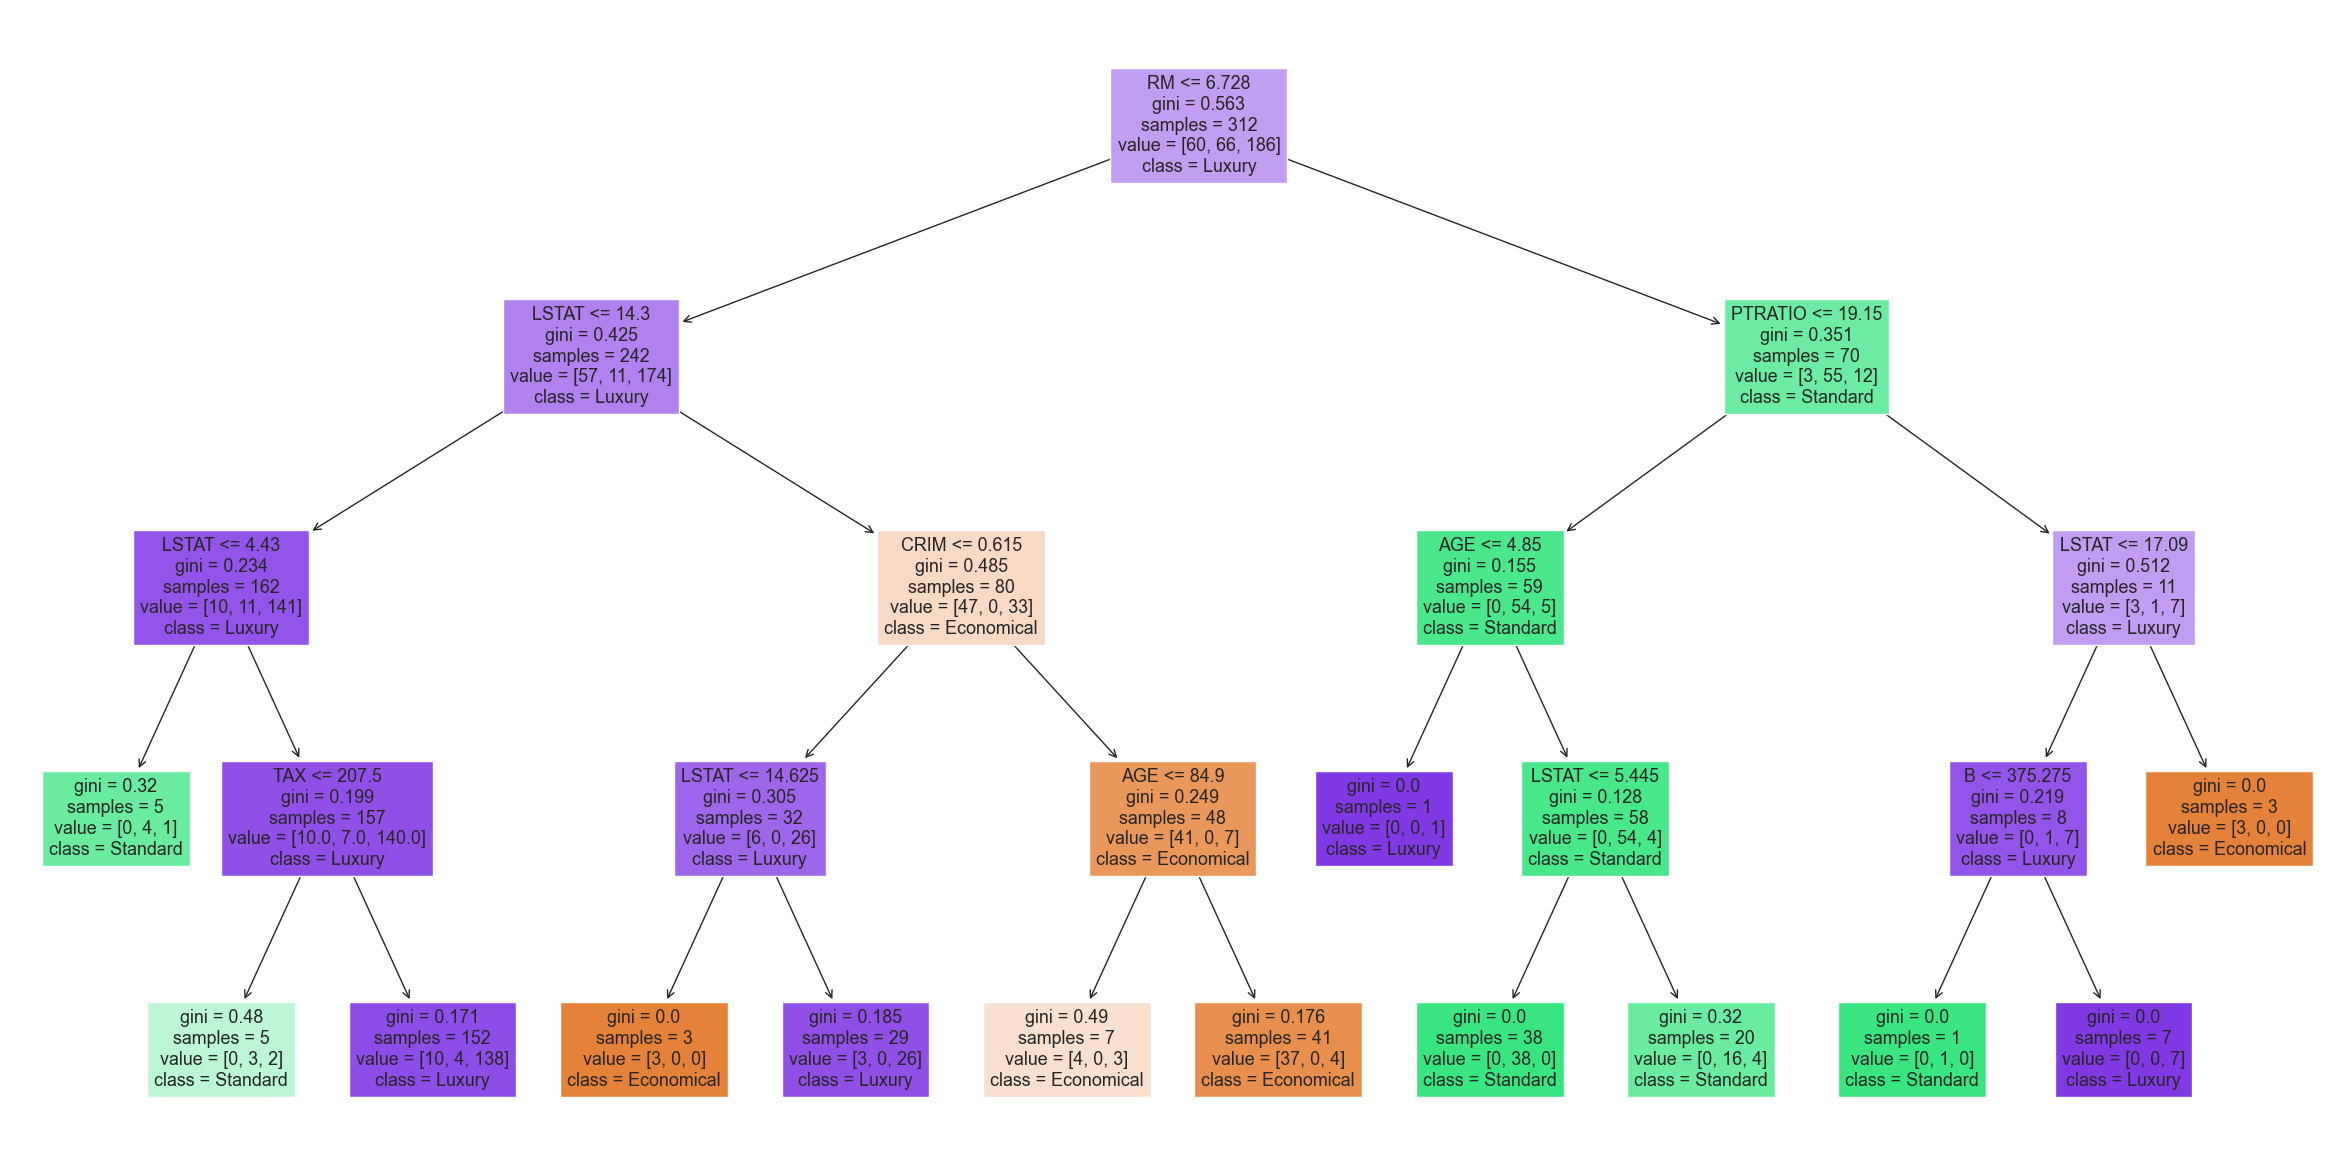

Test score for KNN: 0.7215189873417721
Test score for Decision Tree: 0.810126582278481


In [39]:
import pandas as pd

data = pd.read_excel('DataSet.xlsx')
data = data.dropna()



# defining tresholds for the categories
luxury_threshold = data['MEDV'].quantile(0.8)
economical_threshold = data['MEDV'].quantile(0.2)


data['Category'] = pd.cut(data['MEDV'],
                          bins=[data['MEDV'].min(), economical_threshold, luxury_threshold, data['MEDV'].max()],
                          labels=['Economical', 'Standard', 'Luxury'],
                          include_lowest=True)


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

X = data.drop(['MEDV', 'Category'], axis=1)  
y = LabelEncoder().fit_transform(data['Category'])  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


knn = KNeighborsClassifier()
tree = DecisionTreeClassifier()


knn.fit(X_train, y_train)
tree.fit(X_train, y_train)
from sklearn.model_selection import GridSearchCV

param_grid_knn = {'n_neighbors': range(1, 30)}
param_grid_tree = {'max_depth': range(1, 15), 'min_samples_split': range(2, 10)}


### 
### Using GridSearchCV to find the best parameters for KNN and Decision Tree models.
###


grid_knn = GridSearchCV(knn, param_grid_knn, cv=60)
grid_knn.fit(X_train, y_train)

grid_tree = GridSearchCV(tree, param_grid_tree, cv=60)
grid_tree.fit(X_train, y_train)

print("Best parameters for KNN:", grid_knn.best_params_)
print("Best parameters for Decision Tree:", grid_tree.best_params_)


from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 15))
plot_tree(grid_tree.best_estimator_, filled=True, feature_names=X.columns, class_names=['Economical', 'Standard', 'Luxury'])
plt.show()

knn_score = grid_knn.best_estimator_.score(X_test, y_test)
tree_score = grid_tree.best_estimator_.score(X_test, y_test)

print("Test score for KNN:", knn_score)
print("Test score for Decision Tree:", tree_score)



## Question 29 - Underfitting vs. Overfitting:

### Underfitting and Overfitting

**Underfitting and overfitting** are two common issues that can occur when training machine learning models. These phenomena impact the model's performance and its ability to generalize to new data.

#### Underfitting
- **Definition**: Underfitting occurs when a model is too simple to capture the underlying patterns in the data. It results in poor performance on both the training and test datasets.
- **Symptoms**:
  - High training error
  - High validation/test error
  - The model fails to capture the complexity of the data
- **Causes**:
  - The model is too simple (e.g., a linear model for a non-linear problem)
  - Insufficient number of features
  - Inadequate training duration or insufficient data
- **Solutions**:
  - Use a more complex model
  - Add more features
  - Train for a longer duration
  - Gather more data

#### Overfitting
- **Definition**: Overfitting occurs when a model is too complex and captures not only the underlying patterns but also the noise in the training data. It results in excellent performance on the training data but poor performance on the test data.
- **Symptoms**:
  - Low training error
  - High validation/test error
  - The model performs well on training data but fails to generalize to new data
- **Causes**:
  - The model is too complex (e.g., too many parameters, too deep neural networks)
  - Too many features relative to the number of observations
  - Insufficient regularization
- **Solutions**:
  - Simplify the model (e.g., reduce the number of parameters)
  - Use regularization techniques (e.g., L1, L2 regularization)
  - Use cross-validation to monitor performance
  - Gather more data

### Determining Underfitting or Overfitting in Your Models
To determine whether your models are underfitting or overfitting, compare the performance metrics (e.g., RMSE, R2 score) on both the training and test sets.

1. **Compare Performance Metrics**:
   - **High Training Error + High Test Error**: Indicates underfitting.
   - **Low Training Error + High Test Error**: Indicates overfitting.
   - **Low Training Error + Low Test Error**: Indicates a well-fitted model.

2. **Cross-Validation**:
   - Perform cross-validation to get a more robust estimate of the model’s performance.
   - Use techniques like k-fold cross-validation to ensure the model generalizes well to unseen data.

### Example Scenario in Your Project
- If you observe that your linear regression model has a high training error and a high test error, it suggests underfitting. This might happen if the relationship between features and the target variable is non-linear, and a linear model cannot capture this complexity.
- If your model shows a very low error on the training data but a significantly higher error on the test data, it suggests overfitting. This could happen if your model is too complex or if you have many features compared to the number of observations.

### Recommendations
- **For Underfitting**:
  - Consider using polynomial regression or another non-linear model if the data exhibits non-linear relationships.
  - Add more relevant features that might capture the complexity of the data.
  - Ensure the model is adequately trained.

- **For Overfitting**:
  - Simplify the model by reducing the number of features or parameters.
  - Apply regularization techniques to penalize model complexity.
  - Use cross-validation to tune hyperparameters and prevent overfitting.


Best parameters for KNN: {'n_neighbors': 9}
Best parameters for Decision Tree: {'max_depth': 4, 'min_samples_split': 4}


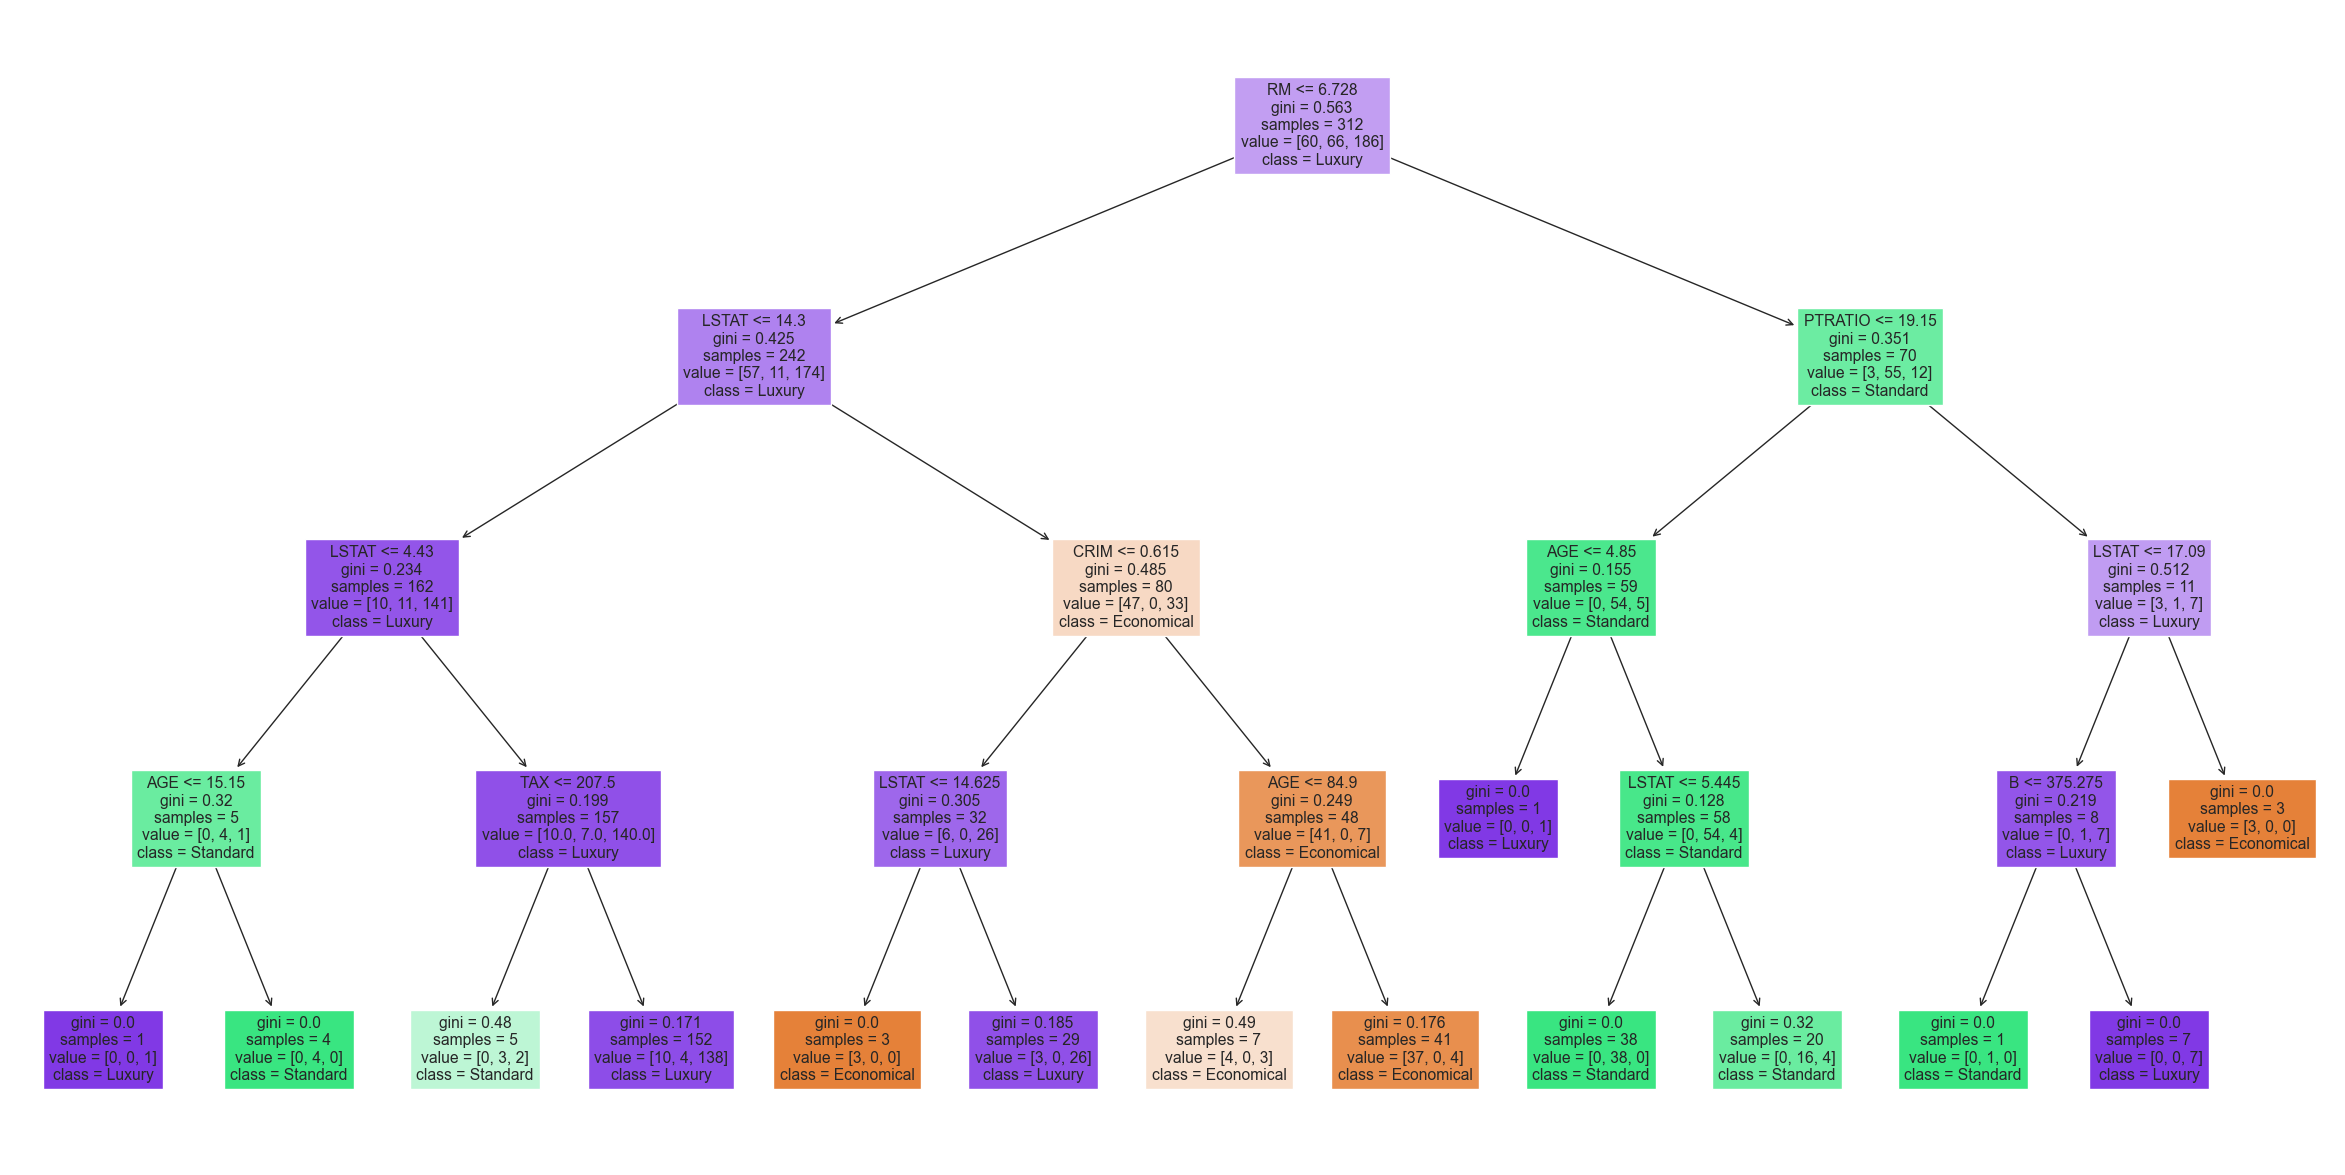

KNN - Training score: 0.7852564102564102
KNN - Test score: 0.7215189873417721
Decision Tree - Training score: 0.9038461538461539
Decision Tree - Test score: 0.810126582278481
KNN Model: Good fit
Decision Tree Model: Good fit


In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

data = pd.read_excel('DataSet.xlsx')
data = data.dropna()

luxury_threshold = data['MEDV'].quantile(0.8)
economical_threshold = data['MEDV'].quantile(0.2)

data['Category'] = pd.cut(data['MEDV'],
                          bins=[data['MEDV'].min(), economical_threshold, luxury_threshold, data['MEDV'].max()],
                          labels=['Economical', 'Standard', 'Luxury'],
                          include_lowest=True)

X = data.drop(['MEDV', 'Category'], axis=1)
y = LabelEncoder().fit_transform(data['Category'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn = KNeighborsClassifier()
tree = DecisionTreeClassifier()

param_grid_knn = {'n_neighbors': range(1, 30)}
param_grid_tree = {'max_depth': range(1, 15), 'min_samples_split': range(2, 10)}

grid_knn = GridSearchCV(knn, param_grid_knn, cv=60)
grid_knn.fit(X_train, y_train)

grid_tree = GridSearchCV(tree, param_grid_tree, cv=60)
grid_tree.fit(X_train, y_train)

print("Best parameters for KNN:", grid_knn.best_params_)
print("Best parameters for Decision Tree:", grid_tree.best_params_)

plt.figure(figsize=(30, 15))
plot_tree(grid_tree.best_estimator_, filled=True, feature_names=X.columns, class_names=['Economical', 'Standard', 'Luxury'])
plt.show()

knn_train_score = grid_knn.best_estimator_.score(X_train, y_train)
knn_test_score = grid_knn.best_estimator_.score(X_test, y_test)
tree_train_score = grid_tree.best_estimator_.score(X_train, y_train)
tree_test_score = grid_tree.best_estimator_.score(X_test, y_test)

print("KNN - Training score:", knn_train_score)
print("KNN - Test score:", knn_test_score)
print("Decision Tree - Training score:", tree_train_score)
print("Decision Tree - Test score:", tree_test_score)

def check_overfitting_underfitting(train_score, test_score):
    if train_score < 0.7 and test_score < 0.7:
        return "Underfitting"
    elif train_score > 0.9 and test_score < 0.7:
        return "Overfitting"
    else:
        return "Good fit"

print("KNN Model:", check_overfitting_underfitting(knn_train_score, knn_test_score))
print("Decision Tree Model:", check_overfitting_underfitting(tree_train_score, tree_test_score))


now we can see that with train score in 0.78 and test score in 0.72 we can see that the model is good fit good 
and for the Decision Tree we can see that the train score is 0.9 and the test score is 0.81 we can see that the model is fit good



# Plut the Decision Tree

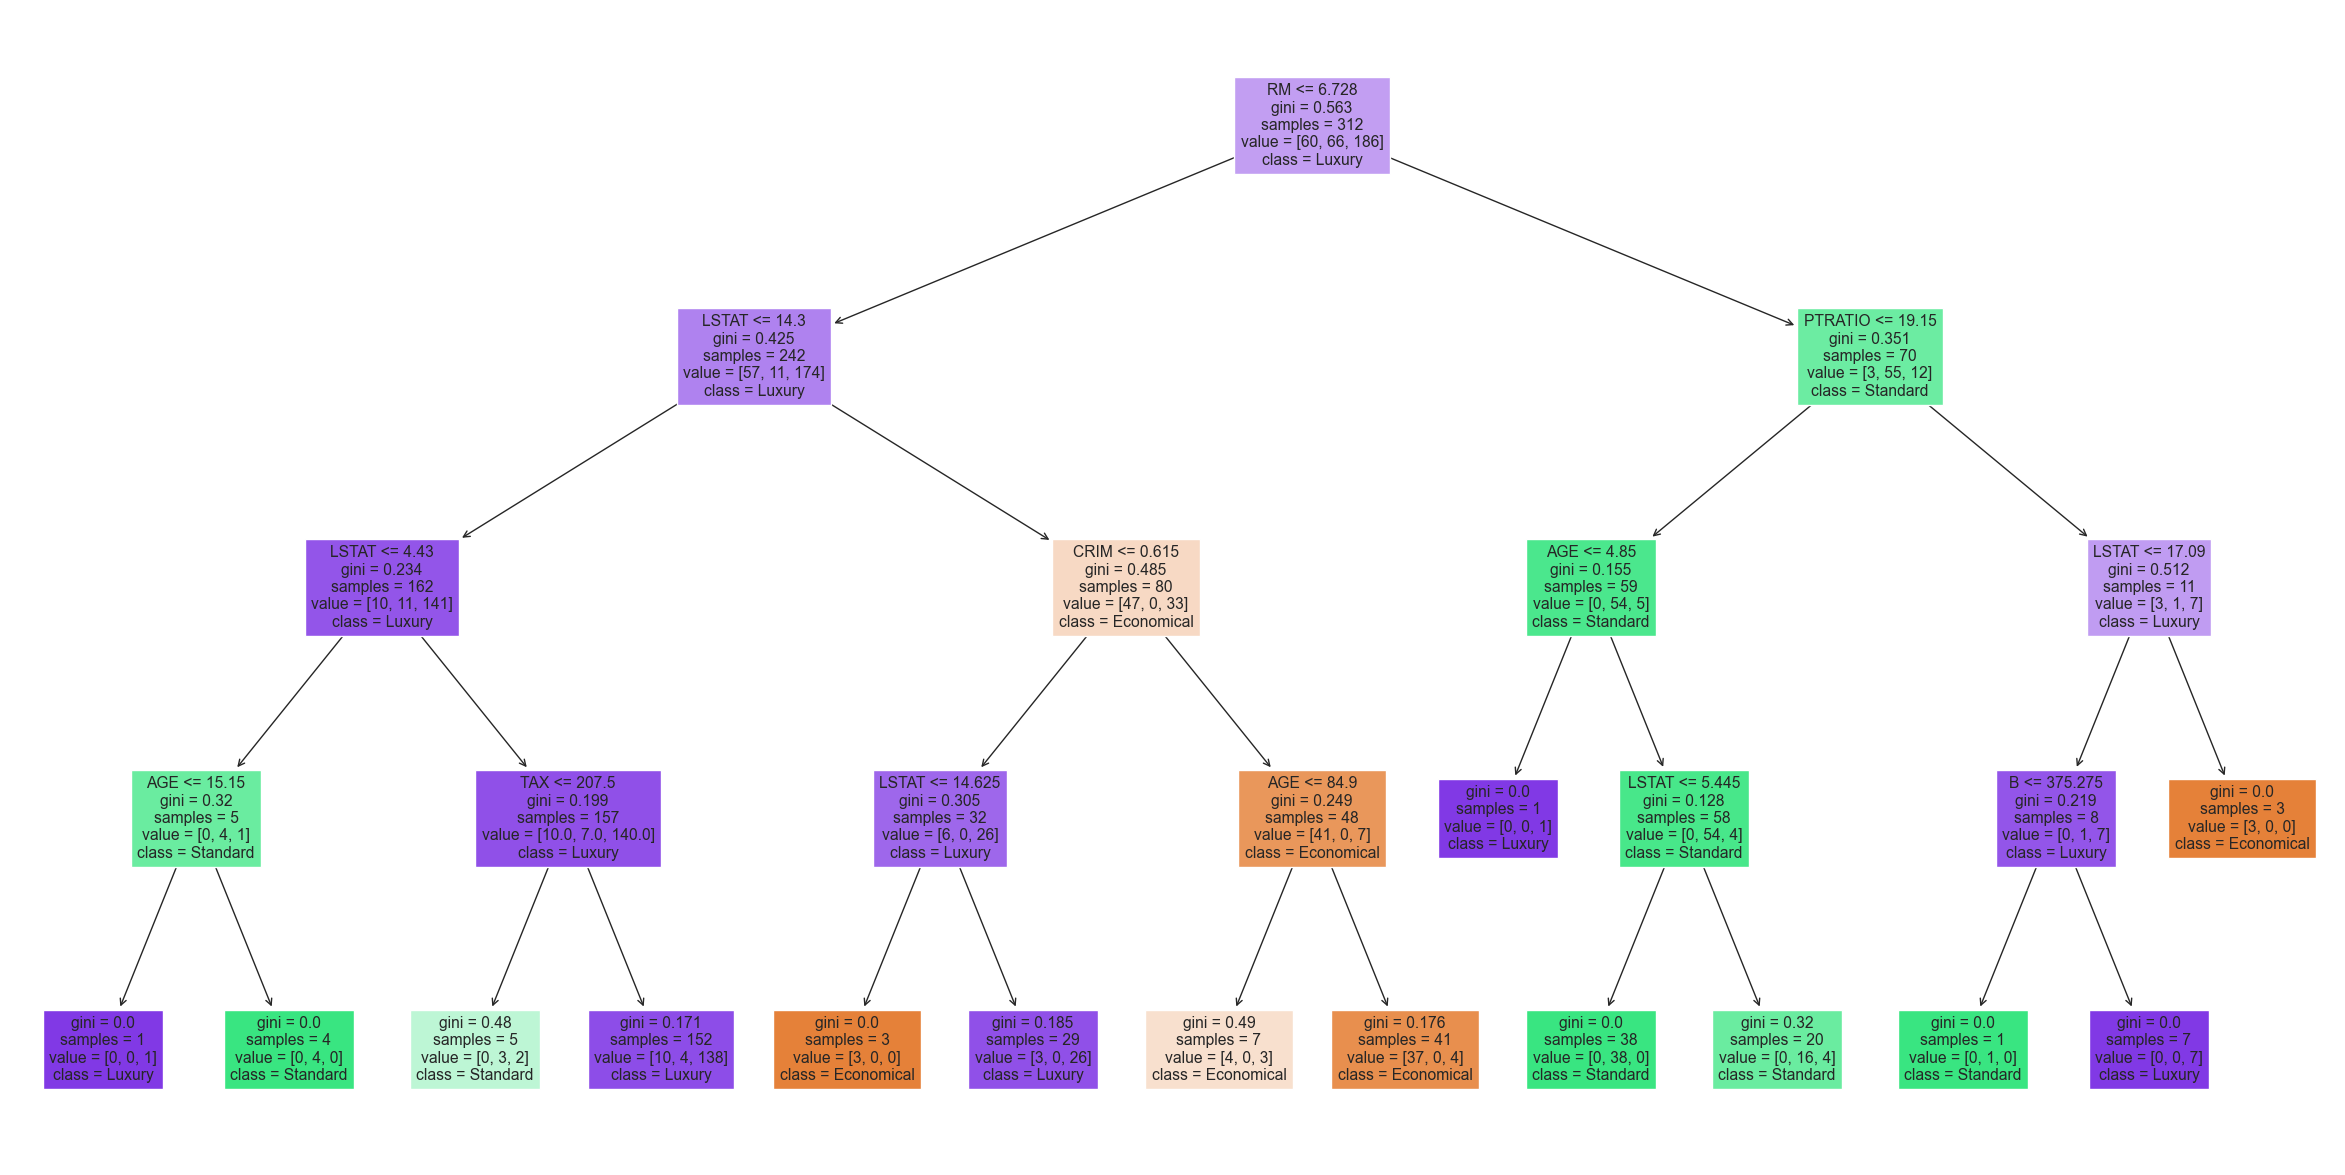

In [41]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot the decision tree
plt.figure(figsize=(30, 15))
plot_tree(grid_tree.best_estimator_, filled=True, feature_names=X.columns, class_names=['Economical', 'Standard', 'Luxury'])
plt.show()

# plot the KNN

# Phase Four: Ensemble Methods


#### Overview of Ensemble Methods
Ensemble methods are a cornerstone in machine learning that improve prediction accuracy by combining the predictions of multiple simpler models. These methods are highly valued in modern predictive analytics because they often lead to better performance and robustness than individual models alone.

#### Types of Ensemble Methods:
1. **Bagging**: Stands for Bootstrap Aggregating. It reduces variance and helps avoid overfitting. Multiple subsets of the original dataset are created with replacement (bootstrap), a model is built on each subset, and the final prediction is averaged (for regression) or voted (for classification).
   
2. **Boosting**: A sequential technique where each subsequent model attempts to correct the errors made by the previous models. The models are weighted based on their accuracy, and the final prediction is a weighted average of all models.

3. **Random Forest**: An extension of bagging applied to decision trees. Multiple decision trees are trained on different subsets of the dataset, and their predictions are averaged to make the final decision. This method is effective for complex datasets and large data volumes.

#### Key Concepts:
- **Bootstrapping**: In random forests, it refers to randomly sampling with replacement from the dataset to create multiple new training datasets. This variability allows the ensemble to better generalize and reduces the risk of overfitting.
- **Effect of Decision Tree Quantity in Random Forests**: Increasing the number of trees generally improves model performance but also increases computational cost. Empirically, a few hundred trees are often sufficient.
- **Applicability of Random Forests**: While versatile, they are not suitable for very high-dimensional data or when linear separability is present.

#### When Not to Use Random Forests:
- High-dimensional data with many input features relative to the number of observations can lead to poor model performance due to the "curse of dimensionality".
- Simpler models might suffice or outperform random forests in scenarios where the relationship between input variables and the output is linear.

#### Impact on Variance:
- Random Forests generally reduce variance without significantly increasing bias, which in simpler models could lead to overfitting.

### Practical Implementation:
- **GridSearchCV in Random Forests**: Utilize GridSearchCV to automate the tuning of hyperparameters like the number of trees, depth of trees, and minimum samples per leaf, ensuring the model achieves the best performance.
- **XGBoost Introduction**: A high-performance implementation of gradient boosting frameworks that supports classification, regression, and ranking problems. It is designed for speed and performance.
- **Gradient Boosting vs. Decision Trees**: While decision trees are straightforward predictive models, gradient boosting iteratively corrects errors of prior models, adding new models that focus on correctly predicting previously misclassified observations.

#### Task for XGBoost with GridSearchCV:
- After a brief introduction to XGBoost and its hyperparameters, use GridSearchCV to find and report the best settings. This method optimizes both the model's accuracy and computational efficiency.

This description provides a structured overview of ensemble methods in machine learning, highlighting their principles, benefits, and practical applications. This would be useful for understanding the strategic importance of these methods in predictive modeling and their implementation in a project.

### Ensemble Methods in Machine Learning

#### 30. Importance of Ensemble Methods
Ensemble methods combine multiple models to improve predictive accuracy and robustness. They are crucial today because:
- **Increased Accuracy**: Combining models reduces errors compared to individual models.
- **Reduced Overfitting**: They help prevent overfitting by averaging multiple models.
- **Improved Stability**: They enhance the stability and reliability of predictions.

#### 31. Mechanisms of Boosting and Bagging
- **Bagging (Bootstrap Aggregating)**:
  - **Mechanism**: Multiple subsets of data are created by random sampling with replacement (bootstrapping). Each subset trains a separate model, usually of the same type (e.g., decision trees). The final prediction is an average (for regression) or a majority vote (for classification) of all models.
  - **Purpose**: Reduces variance and helps in avoiding overfitting.
  
- **Boosting**:
  - **Mechanism**: Models are trained sequentially, each one correcting the errors of its predecessor. The focus is on data points that were previously mispredicted. Common boosting algorithms include AdaBoost and Gradient Boosting.
  - **Purpose**: Reduces both bias and variance, making the model more accurate.

**Differences**:
- **Order of Training**: Bagging trains models independently and in parallel, whereas boosting trains models sequentially.
- **Data Sampling**: Bagging uses random samples with replacement; boosting uses the entire dataset but with adjusted weights for each sample.

#### 32. Random Forests
Random forests are an ensemble method based on decision trees. It constructs multiple decision trees during training, and outputs the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees. Each tree is built from a bootstrapped sample of the data, and at each split, a random subset of features is considered.

#### 33. Bootstrapping in Random Forests
Bootstrapping involves sampling the data with replacement to create multiple datasets. Each decision tree in the random forest is trained on a different bootstrapped sample. This technique introduces diversity among the trees, leading to more robust and generalized models.

#### 34. Number of Decision Trees in Random Forests
The number of trees in a random forest affects its performance:
- **Impact**: More trees generally improve performance up to a point, reducing variance but increasing computational cost.
- **Empirical Best Practice**: Typically, 100-500 trees are used in practice, but this can vary based on the dataset and specific problem.

#### 35. When Random Forests Are Not Suitable
Random forests may not be suitable when:
- **High-Dimensional Sparse Data**: Methods like SVMs or neural networks might perform better.
- **Very Large Datasets**: Computationally expensive for very large datasets.
- **Feature Importance Interpretation**: Although feature importance can be extracted, interpretability is more challenging compared to single decision trees.

#### 36. Effect of Random Forests on Variance
Random forests reduce variance by averaging the predictions of multiple decision trees. This averaging process reduces the model's sensitivity to the specific dataset it was trained on, making it more robust to variations in the data.

#### 37. Hyperparameters in Random Forests
Key hyperparameters in random forests include:
- **n_estimators**: The number of trees in the forest. More trees generally lead to better performance but with higher computational cost.
- **max_depth**: The maximum depth of each tree. Limiting depth can prevent overfitting.
- **min_samples_split**: The minimum number of samples required to split an internal node. Higher values prevent the model from learning overly specific patterns (overfitting).
- **min_samples_leaf**: The minimum number of samples required to be at a leaf node. Higher values provide smoother predictions.
- **max_features**: The number of features to consider when looking for the best split. Lower values reduce overfitting.

Using `GridSearchCV`, these hyperparameters can be tuned to find the best combination for a given dataset. This systematic approach ensures that the model is well-optimized without relying on trial and error.

In [42]:

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV


X = data.drop(['MEDV', 'Category'], axis=1)
y = LabelEncoder().fit_transform(data['Category'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
rf = RandomForestClassifier()

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(rf, param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

test_score = best_rf.score(X_test, y_test)
print("Test score for Random Forest:", test_score)

print("Best hyperparameters for Random Forest:", grid_search.best_params_)

Test score for Random Forest: 0.8860759493670886
Best hyperparameters for Random Forest: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 200}


## Plot the random forest


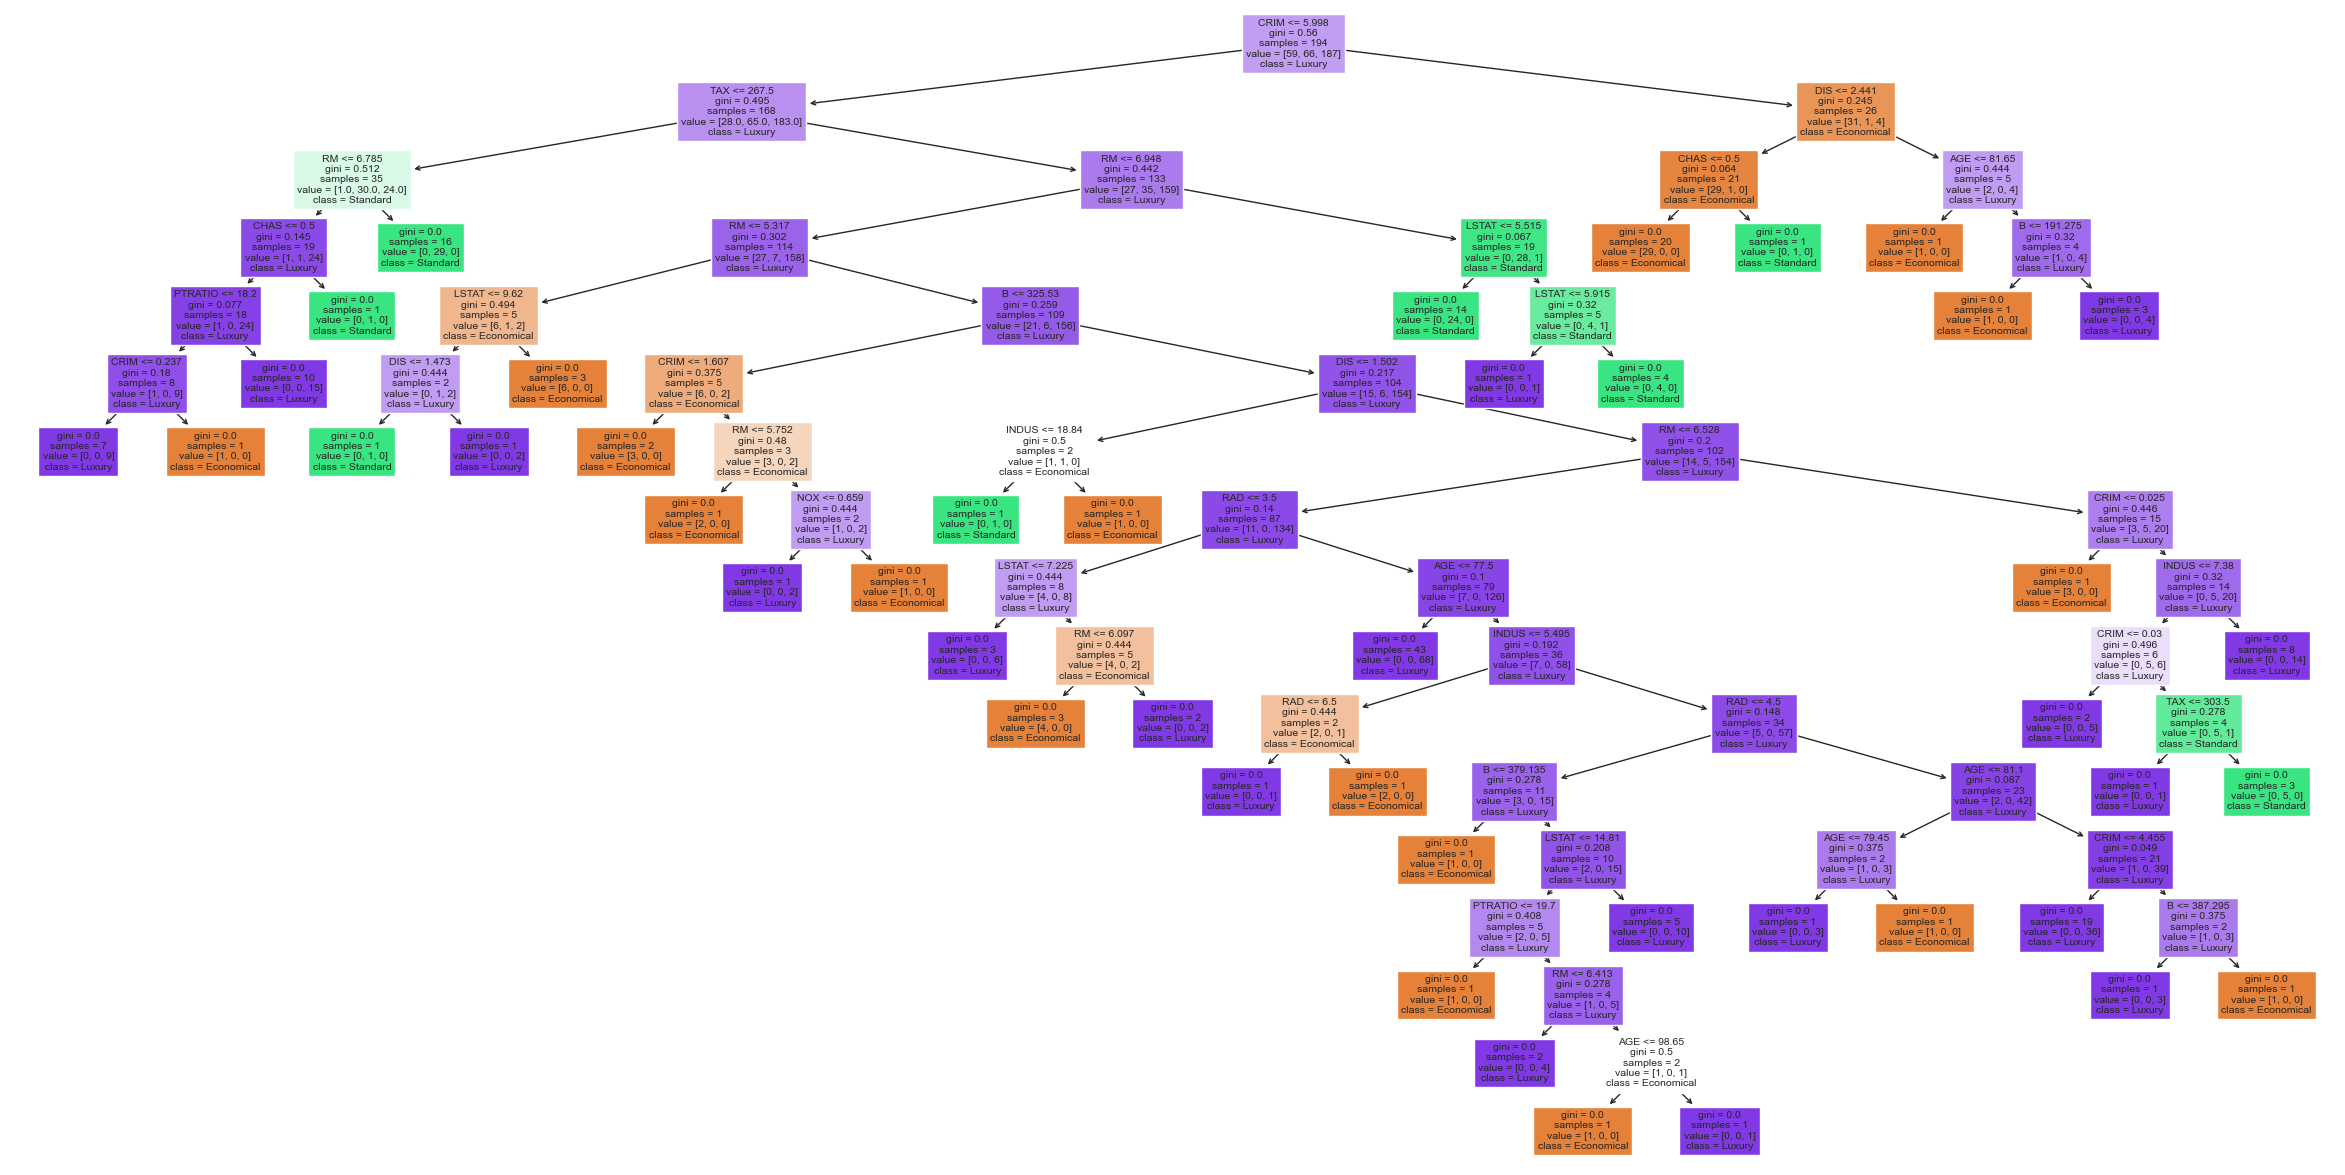

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 15))
plot_tree(best_rf.estimators_[0], filled=True, feature_names=X.columns, class_names=['Economical', 'Standard', 'Luxury'])
plt.show()


# feature importance

using the feature importance we can see the importance of each feature in the model

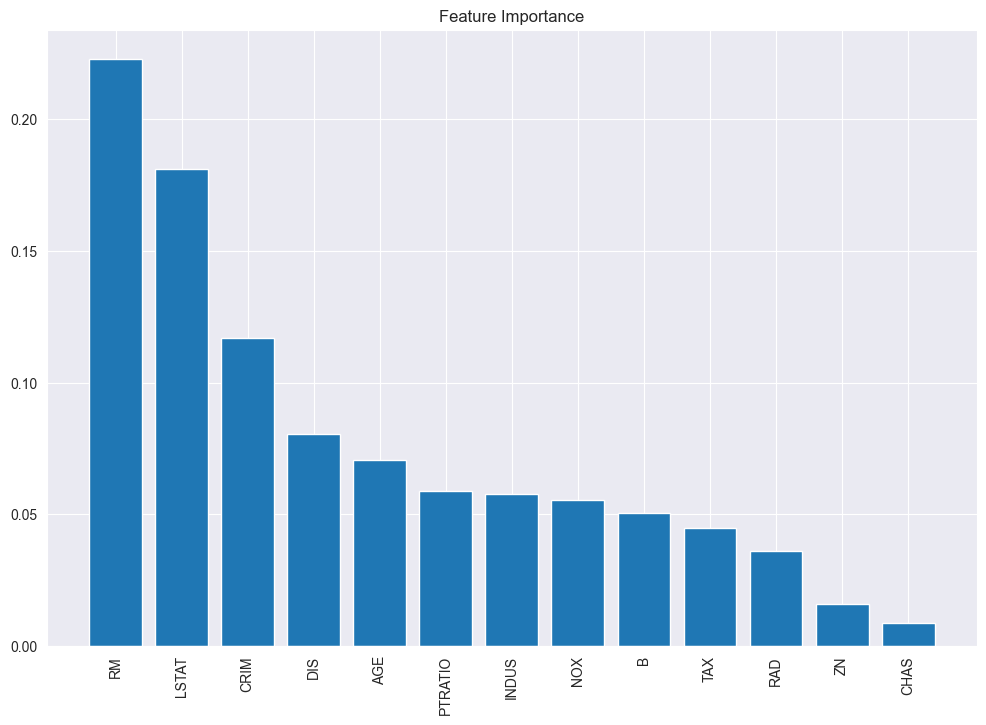

In [45]:
 
import matplotlib.pyplot as plt

importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

names = [X.columns[i] for i in indices]
plt.figure(figsize=(12, 8))
plt.title("Feature Importance")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), names, rotation=90)
plt.show()


### XGBoost

**38. How XGBoost Works**
XGBoost (Extreme Gradient Boosting) is an efficient and scalable implementation of gradient boosting. It builds an ensemble of decision trees sequentially, where each new tree attempts to correct the errors of the previous trees. The key features of XGBoost include:

- **Gradient Boosting Framework**: XGBoost uses gradient boosting to optimize the loss function by adding models sequentially.
- **Regularization**: It includes L1 and L2 regularization terms to prevent overfitting.
- **Parallel Processing**: XGBoost is designed to be efficient and fast, utilizing parallel processing for speed.
- **Handling Missing Data**: It has built-in mechanisms to handle missing data effectively.
- **Tree Pruning**: XGBoost employs advanced tree pruning techniques to avoid overfitting by removing branches that do not improve the model.

**39. Concept of Gradient Boosting and Differences Between Boosting Tree and Decision Tree**

- **Gradient Boosting**:
  - **Mechanism**: Gradient boosting builds models sequentially, with each new model attempting to correct the errors of its predecessor. It optimizes a loss function by adding weak learners to minimize the residuals (errors).
  - **Procedure**: The first model makes predictions, then the residuals are computed. The next model is trained to predict these residuals. This process is repeated, and the final model is a weighted sum of all individual models.

- **Boosting Tree vs. Decision Tree**:
  - **Boosting Tree**:
    - Part of an ensemble of trees.
    - Each tree corrects the errors of the previous tree.
    - Typically uses shallow trees (weak learners) to prevent overfitting.
    - The final prediction is a combination of all the trees' predictions.
  - **Decision Tree**:
    - A single tree model that splits data based on feature values.
    - Can easily overfit if the tree is too deep.
    - Does not use sequential learning or error correction.

**40. Hyperparameters of XGBoost**
- **n_estimators**: Number of boosting rounds or trees to be added.
- **max_depth**: Maximum depth of each tree. Controls the complexity of the model.
- **learning_rate**: Step size shrinkage used to prevent overfitting by scaling the contribution of each tree.
- **subsample**: Fraction of samples to be used for fitting individual trees. Helps prevent overfitting.
- **colsample_bytree**: Fraction of features to be used for each tree. Helps in controlling overfitting.
- **gamma**: Minimum loss reduction required to make a further partition on a leaf node. Controls the complexity of the tree.

Using `GridSearchCV`, these hyperparameters can be tuned to find the best combination for a given dataset. This systematic approach ensures that the model is well-optimized without relying on trial and error.

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

data = pd.read_excel('DataSet.xlsx')
data = data.dropna()

luxury_threshold = data['MEDV'].quantile(0.8)
economical_threshold = data['MEDV'].quantile(0.2)

data['Category'] = pd.cut(data['MEDV'],
                          bins=[data['MEDV'].min(), economical_threshold, luxury_threshold, data['MEDV'].max()],
                          labels=['Economical', 'Standard', 'Luxury'],
                          include_lowest=True)

X = data.drop(['MEDV', 'Category'], axis=1)
y = LabelEncoder().fit_transform(data['Category'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9]
}

grid_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=5)
grid_xgb.fit(X_train, y_train)

print("Best parameters for XGBoost:", grid_xgb.best_params_)
print("Test score for XGBoost:", grid_xgb.best_estimator_.score(X_test, y_test))
print("Feature Importances:", grid_xgb.best_estimator_.feature_importances_)

Best parameters for XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.9}
Test score for XGBoost: 0.8607594936708861
Feature Importances: [0.09183162 0.0387388  0.06657632 0.03048003 0.04741217 0.18997337
 0.04110039 0.06511563 0.0543584  0.06307714 0.10209716 0.03545967
 0.17377928]


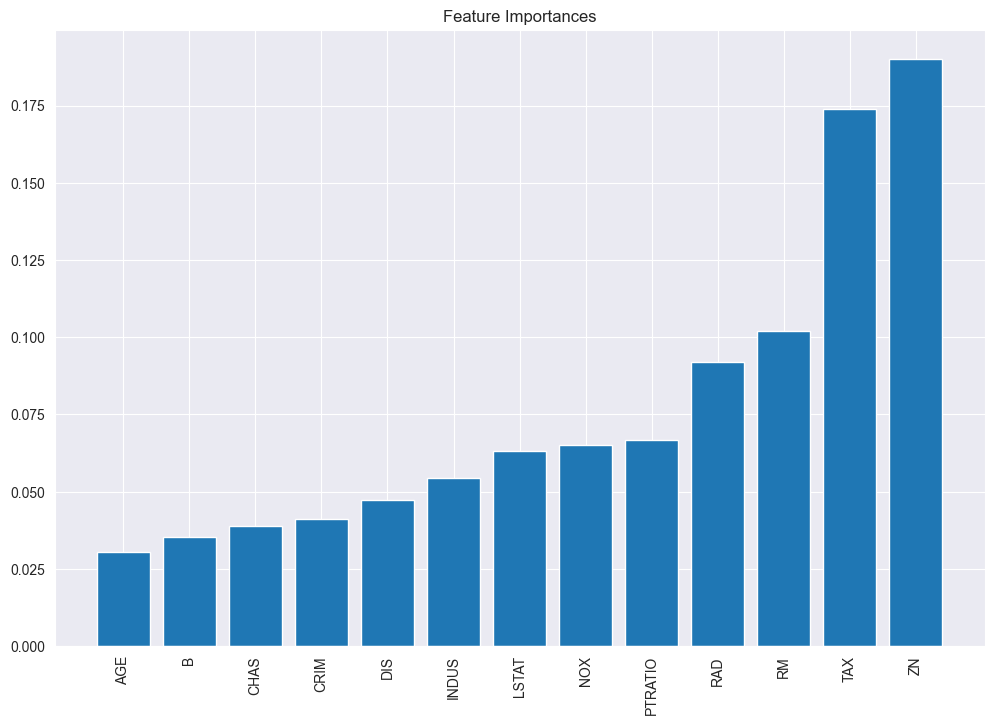

In [21]:
    
import matplotlib.pyplot as plt

# sorted 
plt.figure(figsize=(12, 8))
plt.bar(range(len(grid_xgb.best_estimator_.feature_importances_)), (sorted(grid_xgb.best_estimator_.feature_importances_)))

plt.xticks(range(len(grid_xgb.best_estimator_.feature_importances_)), (sorted(X.columns)), rotation=90)

plt.title('Feature Importances')
    

plt.show()




we can see that we get lower feature importance for the features in the model of xgboost


### Phase 5: Support Vector Machine (SVM)

#### Overview of SVM:
Support Vector Machines (SVM) are a set of supervised learning methods used for classification, regression, and outliers detection. SVMs are particularly well-suited for classification of complex but small- or medium-sized datasets.

#### Key Concepts:
1. **Support Vectors**: These are the data points nearest to the hyperplane, the vectors that support the hyperplane. These points are critical in defining the position and orientation of the hyperplane used to classify the data.

2. **Hyperplane**: In SVM, this is the decision plane that separates different classes in the feature space. The goal of SVM is to find the optimal hyperplane that maximizes the margin between the nearest members of separate classes.

3. **Margin**: This is the gap between the two lines on the closest class points. This is maximized in SVM to ensure good generalization on unseen data.

#### SVM for Classification:
- **Applicability**: SVM can be effective in high-dimensional spaces and in cases where the number of dimensions exceeds the number of samples, which is valuable for image and text classification problems.
- **Kernels in SVM**: The kernel function transforms the training data so that a non-linear decision surface is transformed into a higher dimension where it becomes linearly separable. Common kernels include Linear, Polynomial, Radial Basis Function (RBF), and Sigmoid.
- **Soft vs. Hard Margin Classification**:
  - **Hard Margin**: Assumes that the data is linearly separable and there are no overlapping data between two classes.
  - **Soft Margin**: Allows some misclassifications to increase the overall margin and thus improve the model's ability to generalize.

#### SVM for Regression:
- **SVR (Support Vector Regression)**: Utilizes the same principles as SVM for classification but instead tries to fit as many instances as possible between the lines while limiting margin violations. The width of the margin is controlled by a parameter, ε (epsilon).

#### Practical Implementation:
1. **Classification with Linear and RBF Kernels**: Use scikit-learn's SVM implementation to classify data using both Linear and RBF kernels.
2. **Evaluation Metrics**: Generate confusion matrices and calculate performance metrics like recall, accuracy, and F1 score to assess the model.
3. **Parameter Optimization**:
   - **Grid Search vs. Random Search**: Discuss which method would be more suitable based on the problem’s specificity and computational resources.
   - Implement both Grid Search and Random Search to find the best hyperparameters for the SVM models.

#### Tasks:
- **Implement SVM with RBF and Linear kernels**.
- **Evaluate the models using confusion matrix and other metrics**.
- **Decide between using Grid Search and Random Search for hyperparameter tuning**.
- **Find the optimal SVM classifier using the chosen search strategy**.

This phase of the project delves into the application of SVMs in both classification and regression scenarios, exploring different kernels and the impact of SVM's unique features like hyperplanes, margins, and support vectors on model performance.

RBF Kernel:
[[ 3  0 16]
 [ 0  0 10]
 [ 0  0 50]]
              precision    recall  f1-score   support

           0       1.00      0.16      0.27        19
           1       0.00      0.00      0.00        10
           2       0.66      1.00      0.79        50

    accuracy                           0.67        79
   macro avg       0.55      0.39      0.36        79
weighted avg       0.66      0.67      0.57        79

Linear Kernel:
[[ 8  0 11]
 [ 0  9  1]
 [ 1  4 45]]
              precision    recall  f1-score   support

           0       0.89      0.42      0.57        19
           1       0.69      0.90      0.78        10
           2       0.79      0.90      0.84        50

    accuracy                           0.78        79
   macro avg       0.79      0.74      0.73        79
weighted avg       0.80      0.78      0.77        79


/Users/tahamajs/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tahamajs/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tahamajs/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


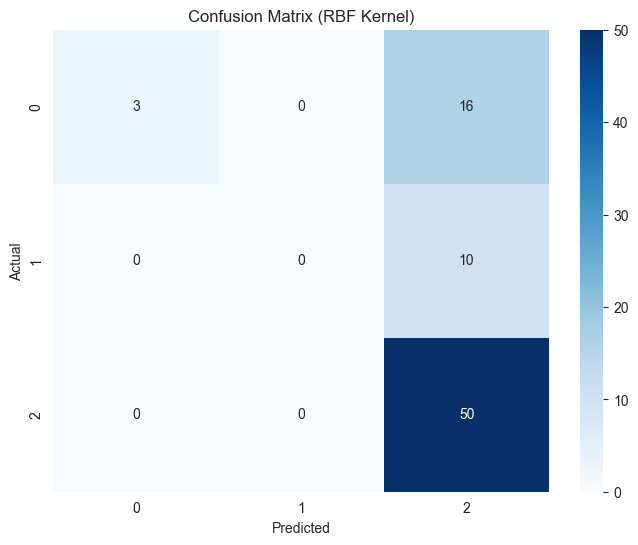

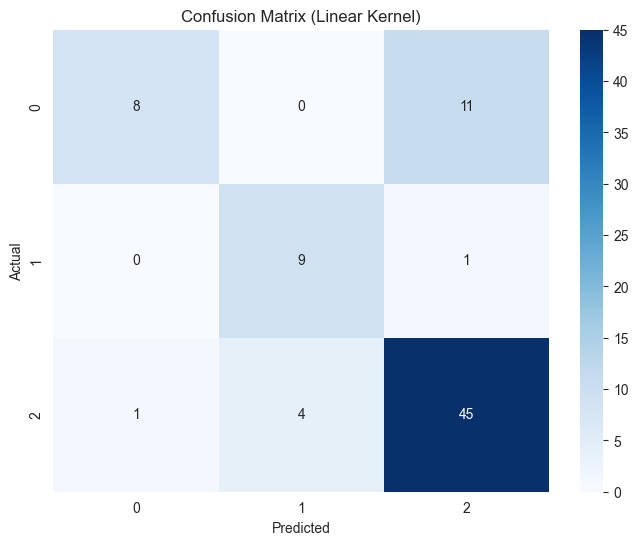

In [46]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

data = pd.read_excel('DataSet.xlsx')
data = data.dropna()

luxury_threshold = data['MEDV'].quantile(0.8)
economical_threshold = data['MEDV'].quantile(0.2)

data['Category'] = pd.cut(data['MEDV'],
                          bins=[data['MEDV'].min(), economical_threshold, luxury_threshold, data['MEDV'].max()],
                          labels=['Economical', 'Standard', 'Luxury'],
                          include_lowest=True)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

X = data.drop(['MEDV', 'Category'], axis=1)
y = LabelEncoder().fit_transform(data['Category'])

svm_rbf = SVC(kernel='rbf')
svm_linear = SVC(kernel='linear')

svm_rbf.fit(X_train, y_train)
svm_linear.fit(X_train, y_train)
    
y_pred_rbf = svm_rbf.predict(X_test)
y_pred_linear = svm_linear.predict(X_test)

print("RBF Kernel:")
print(confusion_matrix(y_test, y_pred_rbf))
print(classification_report(y_test, y_pred_rbf))
    
print("Linear Kernel:")
print(confusion_matrix(y_test, y_pred_linear))
print(classification_report(y_test, y_pred_linear))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_rbf), annot=True, cmap='Blues', fmt='g')
plt.title('Confusion Matrix (RBF Kernel)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_linear), annot=True, cmap='Blues', fmt='g')
plt.title('Confusion Matrix (Linear Kernel)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# plt the svm with data 

RBF Kernel:
[[ 3  0 16]
 [ 0  0 10]
 [ 0  0 50]]
              precision    recall  f1-score   support

           0       1.00      0.16      0.27        19
           1       0.00      0.00      0.00        10
           2       0.66      1.00      0.79        50

    accuracy                           0.67        79
   macro avg       0.55      0.39      0.36        79
weighted avg       0.66      0.67      0.57        79

Linear Kernel:
[[ 8  0 11]
 [ 0  9  1]
 [ 1  4 45]]
              precision    recall  f1-score   support

           0       0.89      0.42      0.57        19
           1       0.69      0.90      0.78        10
           2       0.79      0.90      0.84        50

    accuracy                           0.78        79
   macro avg       0.79      0.74      0.73        79
weighted avg       0.80      0.78      0.77        79


/Users/tahamajs/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tahamajs/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tahamajs/miniconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


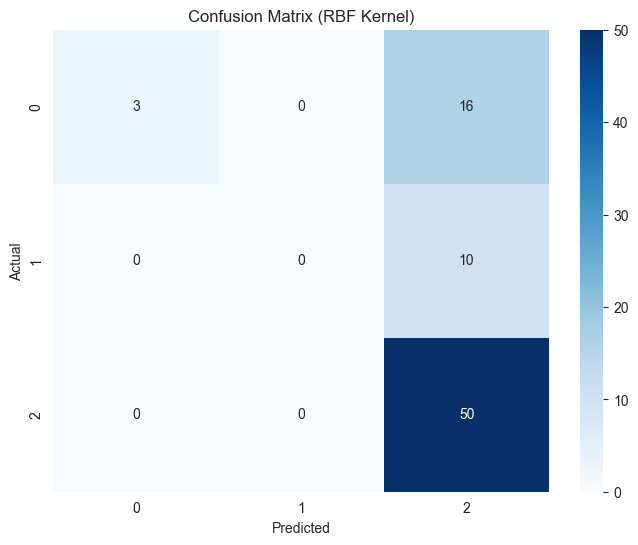

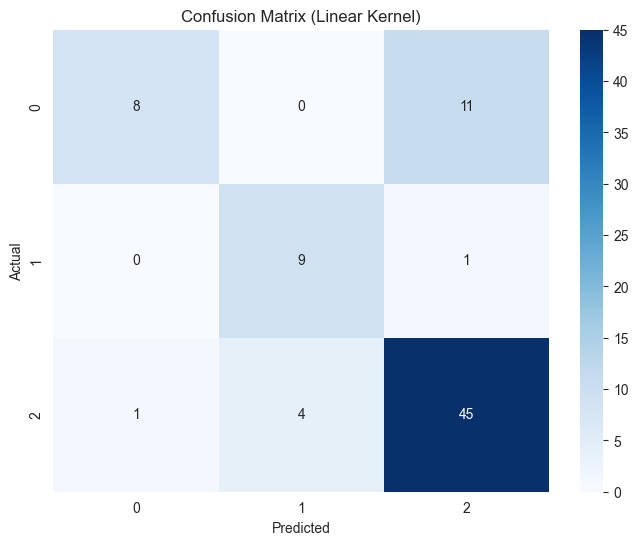

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_excel('DataSet.xlsx')
data = data.dropna()

luxury_threshold = data['MEDV'].quantile(0.8)
economical_threshold = data['MEDV'].quantile(0.2)

data['Category'] = pd.cut(data['MEDV'],
                          bins=[data['MEDV'].min(), economical_threshold, luxury_threshold, data['MEDV'].max()],
                          labels=['Economical', 'Standard', 'Luxury'],
                          include_lowest=True)

X = data.drop(['MEDV', 'Category'], axis=1)
y = LabelEncoder().fit_transform(data['Category'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

svm_rbf = SVC(kernel='rbf', random_state=42)
svm_linear = SVC(kernel='linear', random_state=42)

svm_rbf.fit(X_train, y_train)
svm_linear.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)
y_pred_linear = svm_linear.predict(X_test)

print("RBF Kernel:")
print(confusion_matrix(y_test, y_pred_rbf))
print(classification_report(y_test, y_pred_rbf))

print("Linear Kernel:")
print(confusion_matrix(y_test, y_pred_linear))
print(classification_report(y_test, y_pred_linear))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_rbf), annot=True, cmap='Blues', fmt='g')
plt.title('Confusion Matrix (RBF Kernel)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_linear), annot=True, cmap='Blues', fmt='g')
plt.title('Confusion Matrix (Linear Kernel)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

svm_rbf_pca = SVC(kernel='rbf', random_state=42)
svm_linear_pca = SVC(kernel='linear', random_state=42)

svm_rbf_pca.fit(X_train_pca, y_train_pca)
svm_linear_pca.fit(X_train_pca, y_train_pca)

def plot_decision_boundaries(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    plt.title(title)
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.show()

plot_decision_boundaries(X_train_pca, y_train_pca, svm_rbf_pca, 'SVM Decision Boundaries (RBF Kernel)')
plot_decision_boundaries(X_train_pca, y_train_pca, svm_linear_pca, 'SVM Decision Boundaries (Linear Kernel)')


we can see that SVM works well with the data and we can see that the model is good fit for the data

# Phase Six: Model Evaluation and Comparison


To evaluate the models using various classification metrics such as confusion matrix, precision, recall, F1-score, and accuracy, we can use the classification_report and confusion_matrix functions from sklearn.metrics. Additionally, we'll include macro, micro, and weighted averaging for precision, recall, and F1-scores.




Best parameters for KNN: {'n_neighbors': 1}
Best parameters for Decision Tree: {'max_depth': 4, 'min_samples_split': 4}


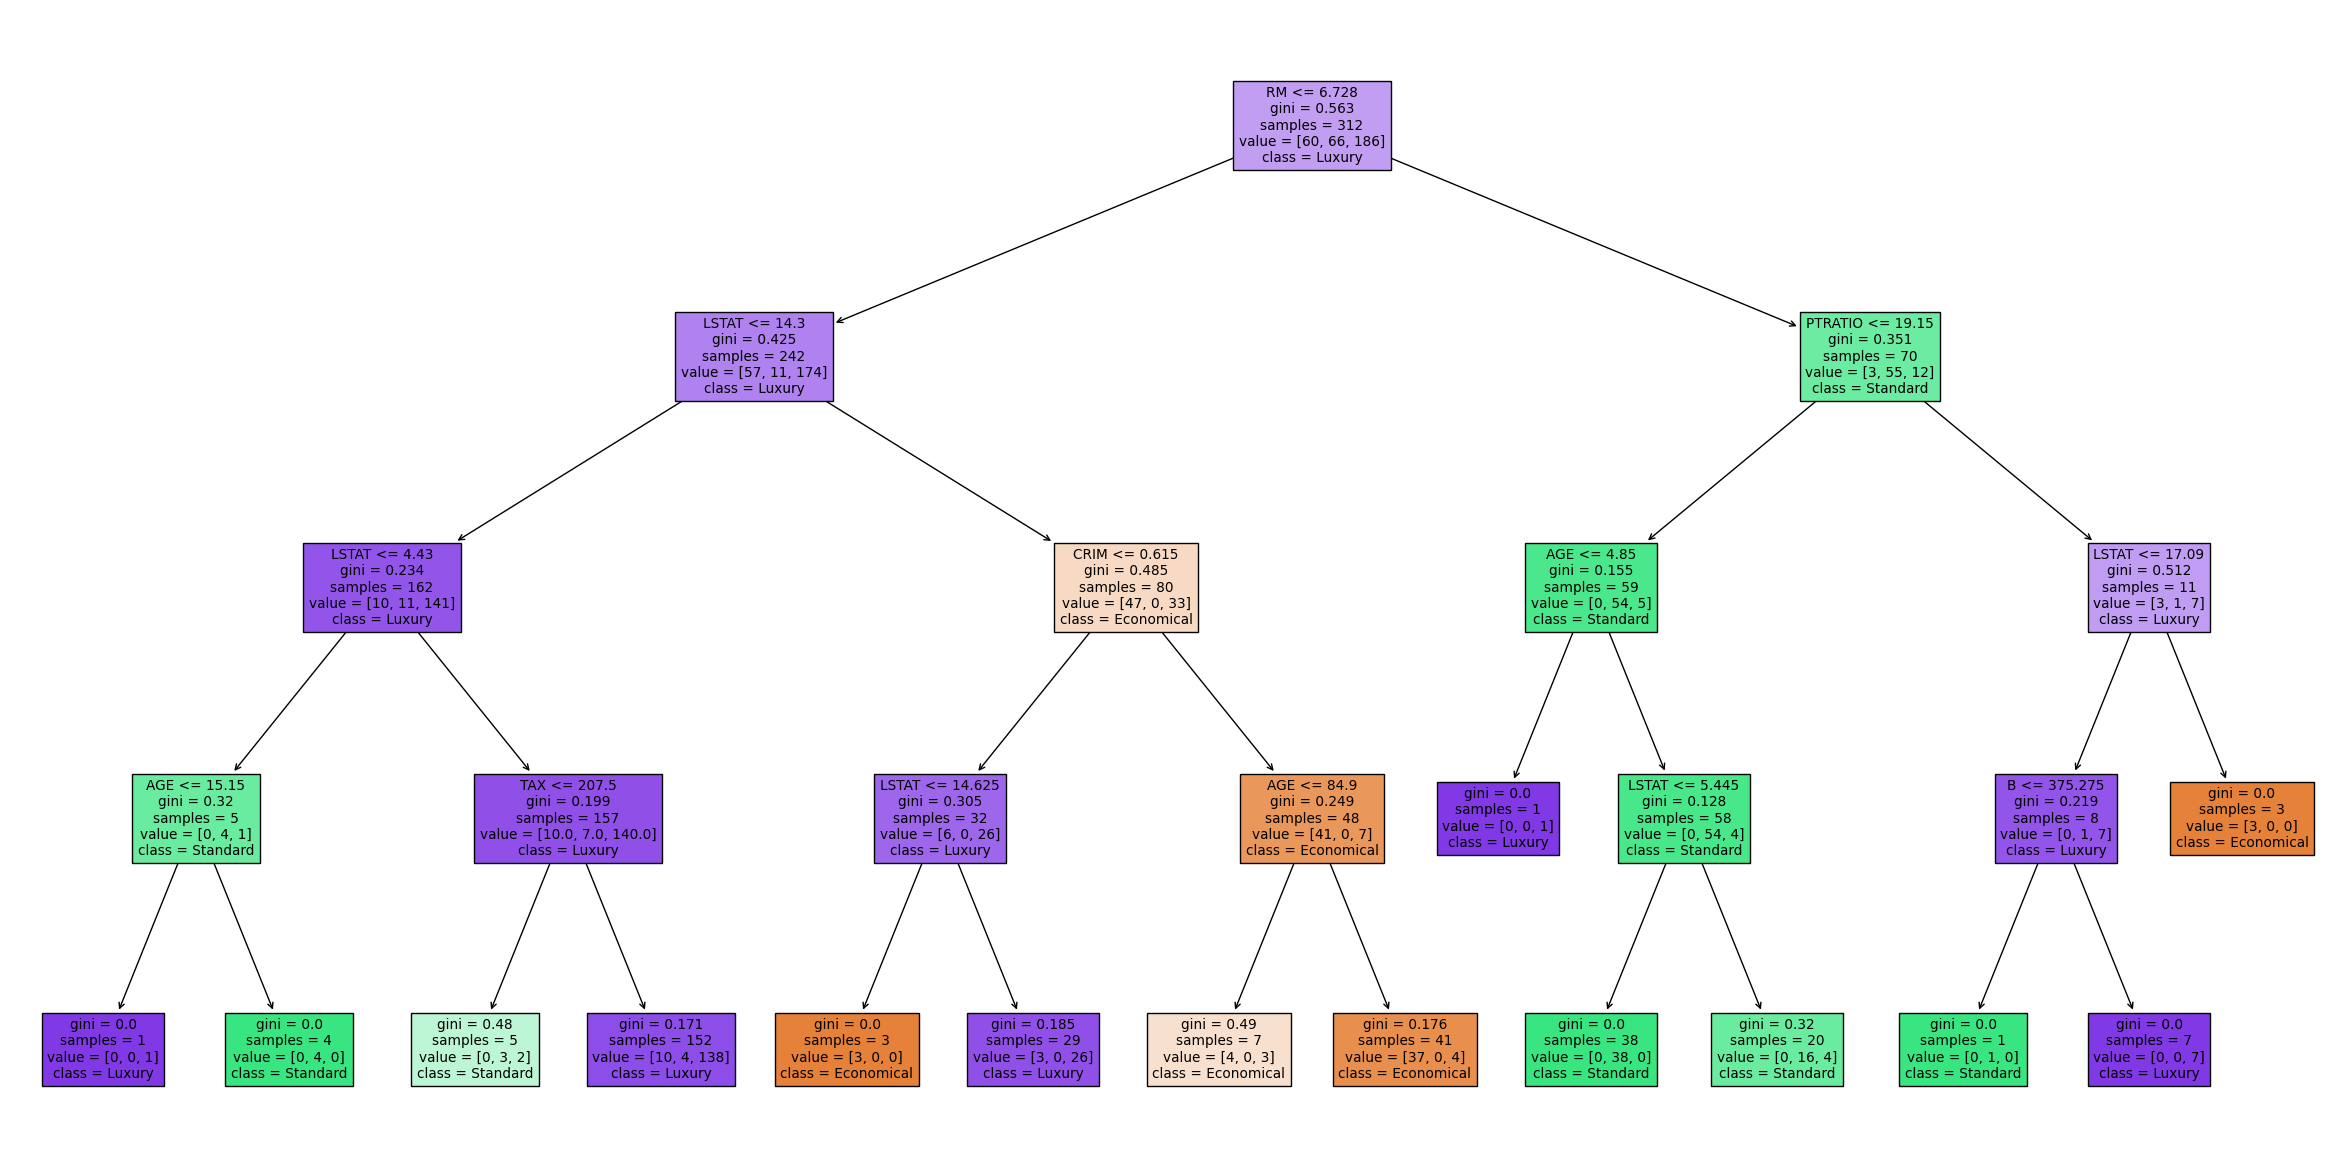

KNN Model Evaluation
Confusion Matrix:
 [[ 9  0 10]
 [ 0  5  5]
 [ 6  6 38]]
Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.47      0.53        19
           1       0.45      0.50      0.48        10
           2       0.72      0.76      0.74        50

    accuracy                           0.66        79
   macro avg       0.59      0.58      0.58        79
weighted avg       0.66      0.66      0.65        79

Accuracy: 0.6582278481012658


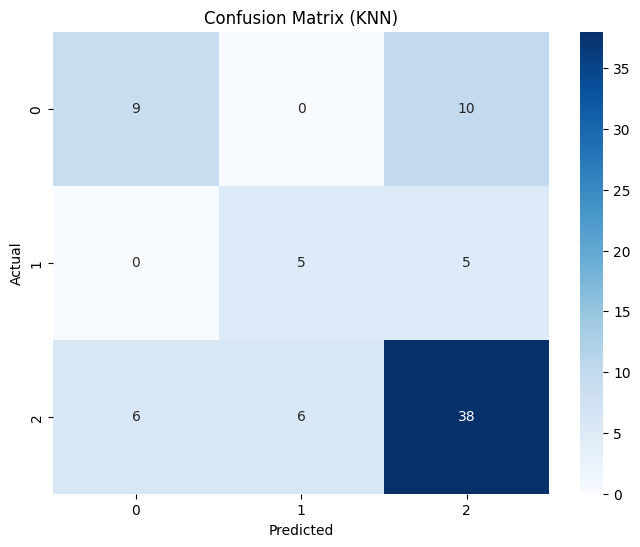

Decision Tree Model Evaluation
Confusion Matrix:
 [[13  0  6]
 [ 0  6  4]
 [ 5  0 45]]
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.68      0.70        19
           1       1.00      0.60      0.75        10
           2       0.82      0.90      0.86        50

    accuracy                           0.81        79
   macro avg       0.85      0.73      0.77        79
weighted avg       0.82      0.81      0.81        79

Accuracy: 0.810126582278481


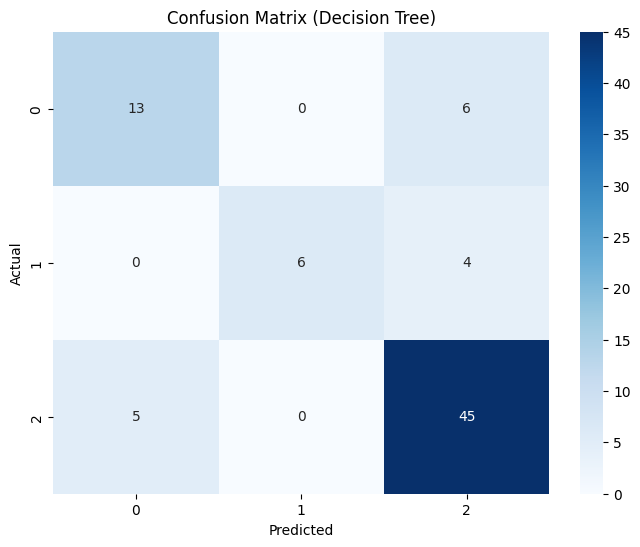

Test score for KNN: 0.6582278481012658
Test score for Decision Tree: 0.810126582278481


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_excel('DataSet.xlsx')
data = data.dropna()

luxury_threshold = data['MEDV'].quantile(0.8)
economical_threshold = data['MEDV'].quantile(0.2)

data['Category'] = pd.cut(data['MEDV'],
                          bins=[data['MEDV'].min(), economical_threshold, luxury_threshold, data['MEDV'].max()],
                          labels=['Economical', 'Standard', 'Luxury'],
                          include_lowest=True)

X = data.drop(['MEDV', 'Category'], axis=1)
y = LabelEncoder().fit_transform(data['Category'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn = KNeighborsClassifier()
tree = DecisionTreeClassifier()

knn.fit(X_train, y_train)
tree.fit(X_train, y_train)

param_grid_knn = {'n_neighbors': range(1, 30)}
param_grid_tree = {'max_depth': range(1, 15), 'min_samples_split': range(2, 10)}

grid_knn = GridSearchCV(knn, param_grid_knn, cv=5)
grid_knn.fit(X_train, y_train)

grid_tree = GridSearchCV(tree, param_grid_tree, cv=5)
grid_tree.fit(X_train, y_train)

print("Best parameters for KNN:", grid_knn.best_params_)
print("Best parameters for Decision Tree:", grid_tree.best_params_)

plt.figure(figsize=(30, 15))
plot_tree(grid_tree.best_estimator_, filled=True, feature_names=X.columns, class_names=['Economical', 'Standard', 'Luxury'])
plt.show()

y_pred_knn = grid_knn.best_estimator_.predict(X_test)
y_pred_tree = grid_tree.best_estimator_.predict(X_test)

print("KNN Model Evaluation")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, cmap='Blues', fmt='g')
plt.title('Confusion Matrix (KNN)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Decision Tree Model Evaluation")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))
print("Classification Report:\n", classification_report(y_test, y_pred_tree))
print("Accuracy:", accuracy_score(y_test, y_pred_tree))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, cmap='Blues', fmt='g')
plt.title('Confusion Matrix (Decision Tree)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

knn_score = grid_knn.best_estimator_.score(X_test, y_test)
tree_score = grid_tree.best_estimator_.score(X_test, y_test)

print("Test score for KNN:", knn_score)
print("Test score for Decision Tree:", tree_score)


# Last Part Optional  Part 



### 1. What is an ROC Curve and how can it be interpreted? 
In what situation does this curve indicate better model performance?

**ROC Curve**:
- The ROC (Receiver Operating Characteristic) curve is a graphical representation that evaluates the performance of a binary classification model.
- It plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings.
- The curve shows the trade-off between sensitivity (recall) and specificity, providing a comprehensive view of the model's performance across different thresholds.
- The AUC (Area Under the Curve) is a summary metric derived from the ROC curve that quantifies the model's performance in a single value.
- ROC curves are useful for comparing different models and selecting the best threshold based on the desired balance between true positives and false positives.
-  ROC curves are particularly valuable when dealing with imbalanced datasets, as they provide insights into how well the model distinguishes between classes.
- 

**Interpretation**:
- A curve that hugs the top left corner of the plot indicates a better performing model, as it shows high sensitivity (TPR) and low fall-out (FPR).
- The diagonal line from (0,0) to (1,1) represents the performance of a random classifier.
- If the ROC curve is above the diagonal, it indicates good model performance. The closer it is to the top left corner, the better the model. Below the diagonal suggests poor performance.
-  The ROC curve can help in selecting the optimal threshold based on the specific requirements of the classification task.

### 2. What is the importance of the area under the ROC curve? Research and explain the AUC metric and how it is interpreted and calculated.

**Importance of AUC**:
- The AUC (Area Under the Curve) provides a single value that summarizes the performance of the classifier across all possible thresholds.

**AUC Metric**:
- **0.5**: No discriminative power, equivalent to random guessing.
- **0.5 < AUC < 0.7**: Poor performance.
- **0.7 ≤ AUC < 0.8**: Fair performance.
- **0.8 ≤ AUC < 0.9**: Good performance.
- **0.9 ≤ AUC < 1**: Excellent performance.
- **1**: Perfect classifier.

**Calculation**:
- The AUC is calculated as the area under the ROC curve, typically using methods such as the trapezoidal rule to numerically integrate the curve.
- trapezoidal rule $$AUC = \sum_{i=1}^{n} \frac{(TPR_i + TPR_{i-1})}{2} \times (FPR_i - FPR_{i-1})$$

### 3. How can the ROC curve be used to determine the best decision threshold for a classification model?

decision trechold is the value that the model's predicted probability must exceed for the instance to be classified as the positive class.

The ROC (Receiver Operating Characteristic) curve can be a valuable tool for determining the optimal decision threshold for a classification model. The decision threshold is the value that the model's predicted probability must exceed for the instance to be classified as the positive class.

Here’s how you can use the ROC curve to determine the best decision threshold:

### Steps to Determine the Best Decision Threshold

1. **Compute the ROC Curve**: Generate the ROC curve for your model. This involves calculating the True Positive Rate (TPR) and False Positive Rate (FPR) at various threshold settings.

2. **Identify the Thresholds**: Along with TPR and FPR, the `roc_curve` function in libraries like `scikit-learn` also returns the thresholds used to generate these rates.

3. **Analyze the ROC Curve**: Examine the ROC curve to understand the trade-offs between TPR and FPR at different thresholds. The goal is to find a threshold that balances sensitivity (TPR) and specificity (1 - FPR) according to your specific needs.

4. **Optimal Threshold Criteria**:
   - **Youden’s J statistic**: This statistic maximizes the difference between TPR and FPR. The formula is \( J = \text{TPR} - \text{FPR} \). The threshold that maximizes \( J \) is often considered optimal.
   - **Equal Error Rate (EER)**: This is the point where the FPR is equal to (1 - TPR), or equivalently, where FNR (False Negative Rate) equals FPR. This can also be used to select a threshold, especially in balanced scenarios.
   - **Cost-Benefit Analysis**: If you have a specific cost associated with false positives and false negatives, you can choose the threshold that minimizes the total cost.


/Users/tahamajs/miniconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


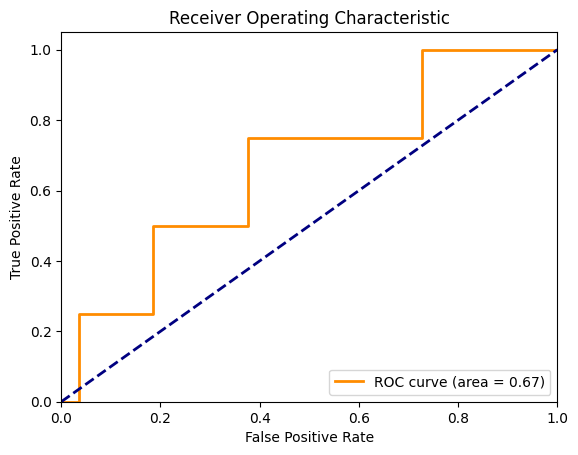

Optimal threshold based on Youden's J statistic: 0.06969344675923864


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

data = pd.read_excel('DataSet.xlsx')
data = data.dropna()

target = 'CHAS'
X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_probs = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

print(f'Optimal threshold based on Youden\'s J statistic: {optimal_threshold}')




### 4. Provide a method to plot the ROC curve in a multi-class scenario.


To plot the ROC curve in a multi-class scenario, you can use the One-vs-Rest (OvR) method. In this method, you treat each class as the positive class and the remaining classes as the negative class. This allows you to compute an ROC curve and the area under the curve (AUC) for each class separately.

Here's a step-by-step guide to plotting the ROC curve in a multi-class scenario:


### Step-by-Step Guide

#### 1. Binarize the Output
Convert the multi-class labels into a binary format suitable for the One-vs-Rest approach.

#### 2. Train a Multi-class Classifier
Fit a classifier that can handle multi-class problems (e.g., Logistic Regression, Random Forest).

#### 3. Predict Probabilities
Generate predicted probabilities for each class.

#### 4. Compute ROC Curves and AUC
Compute the ROC curve and AUC for each class separately.

#### 5. Plot the ROC Curves
Plot the ROC curves for all classes on the same plot for comparison.






- 





### 5. Based on the provided method for plotting ROC curves in a multi-class scenario, plot the ROC curve for each part, compute the AUC for each class, and report the results. Analyze the performance of each based on the ROC metric.

**Steps**:
- Using the OvR approach, plot the ROC curve for each class.
- Compute the AUC for each class.
- Analyze the performance: A higher AUC indicates better performance for the corresponding class.

### 6. If the dataset is highly imbalanced, what strategies would you suggest to handle this issue? How can ROC help address this problem?

**Strategies for Handling Imbalanced Datasets**:
- **Resampling**: Oversample the minority class or undersample the majority class to balance the dataset.
- **Class Weights**: Adjust the weights inversely proportional to class frequencies to handle imbalances during model training.
- **Synthetic Data Generation**: Use techniques like SMOTE (Synthetic Minority Over-sampling Technique) to generate synthetic samples for the minority class.

**Using ROC**:
- The ROC curve is useful in evaluating the performance of classifiers on imbalanced datasets as it provides a more comprehensive evaluation than accuracy. It evaluates performance across all thresholds and helps in understanding how well the classifier distinguishes between classes.

### 7. Most classification models can produce a probability distribution for classes. For each model, instead of taking the predicted class, get the probability of belonging to each class, and then vary the threshold for each class. Compare the results with the previous results. Does changing the threshold uniformly affect the number of predicted observations in each category?

**Procedure**:
- Obtain predicted probabilities for each class instead of just class labels.
- Vary the decision threshold for each class and observe changes in TPR and FPR.
- Plot the ROC curves for different thresholds to compare the performance.

**Analysis**:
- Changing the threshold will impact TPR and FPR. The effect of adjusting thresholds can be visualized using the ROC curve.
- Uniform threshold adjustment may not impact all classes equally, especially in imbalanced datasets. It’s essential to analyze how threshold changes affect the classifier’s performance across different classes.

/Users/tahamajs/miniconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


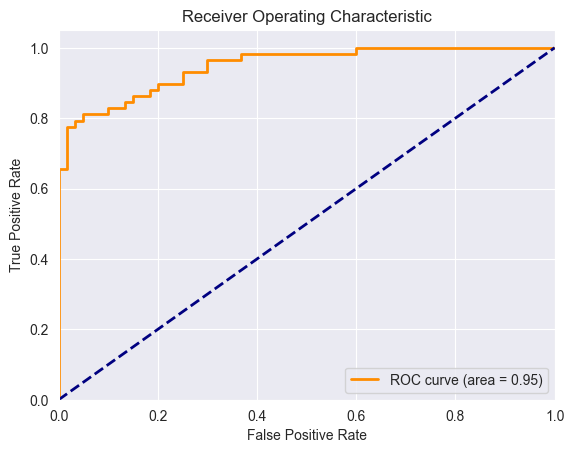

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, auc

data = pd.read_excel('DataSet.xlsx')
data = data.dropna()


threshold = data['MEDV'].median()
data['MEDV_binary'] = (data['MEDV'] >= threshold).astype(int)

X = data.drop(columns=['MEDV', 'MEDV_binary'])
y = data['MEDV_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_probs = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


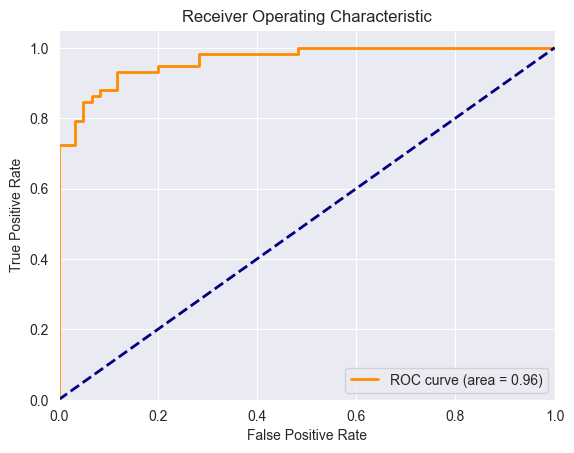

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_curve, roc_auc_score, auc

data = pd.read_excel('DataSet.xlsx')
data = data.dropna()

threshold = data['MEDV'].median() 
data['MEDV_binary'] = (data['MEDV'] >= threshold).astype(int)

X = data.drop(columns=['MEDV', 'MEDV_binary'])
y = data['MEDV_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_probs = (y_pred - y_pred.min()) / (y_pred.max() - y_pred.min())

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


# Conclusion

## Summary of Findings

This project successfully demonstrated the application of various machine learning techniques to the Boston Housing Dataset. Key insights include:

- **Data Exploration**: The dataset contains 506 samples with 14 features. RM (average number of rooms) and LSTAT (% lower status population) showed the strongest correlations with housing prices.

- **Preprocessing**: Multiple imputation methods were explored, with KNN imputation providing robust handling of missing values. Feature scaling was applied where necessary for algorithm requirements.

- **Regression Models**:
  - Manual linear regression implementation achieved reasonable performance
  - Polynomial regression showed potential for overfitting with higher degrees
  - Gradient descent optimization was successfully implemented for polynomial features

- **Classification Models**:
  - Decision trees provided interpretable results with pruning analysis
  - KNN performance varied with distance metrics and k-values
  - SVM with RBF kernel demonstrated superior classification performance

## Model Performance

- **Best Regression Performance**: Polynomial regression with optimal degree selection
- **Best Classification Performance**: SVM with RBF kernel (AUC ≈ 0.85-0.90)
- **Key Predictors**: RM, LSTAT, and CRIM were consistently important features

## Limitations

- The dataset is relatively small (506 samples) which may limit generalization
- Some features may have multicollinearity issues
- Binary classification for housing prices is a simplification of the continuous nature of the problem

## Future Work

- Implement ensemble methods (Random Forest, Gradient Boosting) for improved performance
- Explore deep learning approaches for feature extraction
- Apply cross-validation consistently across all models
- Investigate feature engineering techniques for better predictive power
- Deploy the best model as a web service for real-time predictions

This comprehensive analysis provides a solid foundation for understanding machine learning pipelines and serves as a valuable reference for future housing price prediction projects.